# Why PSBD's statistic works on ViT and Swin, for any perturbation

PSBD (Li et al., arXiv 2406.05826) flags an input as poisoned when the probability of the model's own answer barely drops under $k$ perturbed forward passes. On our ViT-B/16 models that statistic separates triggered from clean images with every perturbation family the project tried. At the attention input these are token masking, dropout and channel masking. On the residual stream it is dropout. The notebooks `mechanism.ipynb` and `why-psbd-tm.ipynb` and the experiment `experiments/why_token_masking_works/` explain why 1 placement beats another on patch triggers. This notebook asks the question underneath them: what property of a triggered input makes its answer survive a perturbation that destroys a clean answer, for any perturbation. A second question is whether the answer is the same for every kind of trigger.

It is written for a reader who knows what a backdoor, a Vision Transformer and an AUROC are and has not read the rest of this repository. Every step states the question it answers, why that question comes next and what is measured by which function. It then shows a figure, says what the figure proves and what it does not and hands over to the next question. Every number is read from JSON files the experiment wrote. Every sentence that carries a number is rendered by code from those files, so nothing here runs a model and nothing can go stale. The measurements, their formulas and the commands that produced them are in `experiments/why_psbd_works/README.md`, which is generated the same way. The predictions each account is judged against come from 2 companion documents: `docs/why-psbd-works-literature.md` names every published and folk explanation with an identifier (L for published ones, P for folk ones). `docs/why-psbd-works-theory.md` turns each into a number with a supported and a refuted threshold. The identifiers are kept here so the 3 documents cross-reference.

In [1]:
import json
import os
import sys
from pathlib import Path

# Anchor at the repository root so every path resolves the way it does from a
# script, whichever directory the notebook was opened from.
REPO_ROOT = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scripts.paper._style  # noqa: F401  the figure style every paper figure uses
from scripts.paper._common import OKABE_ITO
from scripts.paper._style import TEXT_WIDTH

# The shared style selects the Agg backend for the paper build, which keeps every
# figure out of a notebook, so the inline backend comes back after it.
%matplotlib inline

## The map

The statistic, with its symbols:

$$\phi(x) = 1 - \frac{\tfrac{1}{k}\sum_{j=1}^{k} P_c(x;\,\xi_j)}{P_c(x)}, \qquad c = \arg\max_i P_i(x)$$

| symbol | meaning |
|---|---|
| $x$ | the input image |
| $P_i(x)$ | the softmax probability of class $i$ with no perturbation |
| $c$ | the unperturbed model's answer |
| $\xi_j$ | the random draw of the perturbation on pass $j$ (a dropout mask, a token mask, a noise sample) |
| $P_c(x;\xi_j)$ | the probability of class $c$ on perturbed pass $j$ |
| $k$ | the number of passes |
| $\phi(x)$ | the fractional prediction shift uncertainty, low means flagged as poisoned |

This is the fractional form the project uses (`defenses.scores.psu_ratio_from_cache`). Li et al.'s paper subtracts the probabilities without dividing, which the project calls absolute PSU. The fractional form divides out how confident the model was to begin with, which is why the first explanation anyone reaches for, "triggered inputs are just more confident", already has to work harder against it.

The route:

1. **Sanity.** The passes this experiment makes are held to the pipeline's own numbers before any mechanism is read.
2. **The phenomenon.** Does the statistic separate on these models, with every operator, for every attack category? Everything later explains this figure.
3. **H-margin.** Is it a margin effect: does the triggered answer keep its logit margin while the clean one collapses, and does that survive comparing images of equal starting margin?
4. **H-direction.** What in the representation keeps the margin: is the triggered feature dominated by 1 large component, the backdoor direction, that the perturbation barely dents?
5. **H-redundancy.** Where that component comes from in the token sequence: is the trigger's evidence repeated across tokens, so that removing tokens leaves it?
6. **H-low-dim.** How concentrated the triggered decision is: few dimensions, few tokens, a small sufficient part of the input.
7. **H-flatness.** Is it curvature: do triggered inputs sit in a flatter region, and does the statistic behave like the curvature estimate a second-order expansion says it is?
8. **Explanations that do not hold.** Confidence, MC-dropout uncertainty, the trigger being out of distribution, robust trigger neurons, Li et al.'s neuron-bias account, the target class being easy, and the literature memo's refuted items, each reproduced from its source file.
9. **Clean fragility.** The half of the statistic that is about clean images.
10. **The critical rate.** 1 account for every operator and attack, tested against fixed predictions.
11. **Swin-S.** The same measurements on the second architecture.
12. **The unifying hypothesis.** PSBD detects over-determined decisions, tested by trigger sufficiency against pre-registered predictions.
13. **Verdicts.** 1 grid, hypothesis by attack category, supported, partial or refuted, with the key number.

The attack categories follow the literature memo. Patch is BadNets (all to one) and TaCT restricted to the models that classify their clean source class correctly (the others map the whole source class to the target with no trigger, `docs/runs/2026-09-24-tact-multisource.md`). Blend is Blend and LF. Frequency is SIG. Warp is WaNet. Quantization is BPP. The benign controls are benign models probed with a BadNets or a Blend trigger they never learned, the control that separates "the statistic reacts to a backdoor" from "the statistic reacts to a trigger-shaped input".

The models read here are the ones successful at the 2 point bar of the coverage ledger (`successful_2pt`: the attack's ASR clears the declared bar and clean accuracy stays within 2 points of the benign model), the user's decision of 2026-09-29, rebuilt the ledger's way for Swin. SIG has no reading. An audit on 2026-09-29 (`docs/audits/2026-09-29-experiment-audit.md`) found that SIG models trained before 2026-09-09 learned a weaker trigger than `attacks/sig.py` now builds, and the success bar then removed the only ViT SIG model of the paper's datasets. `measure.py` keeps the SIG entries quarantined until their provenance is settled.

The next cell loads the files. The table lists every model measured, its group, how many triggered images the unperturbed model sends to the target ("hit" pairs, the only ones with a target decision to keep), its paired clean accuracy and ASR on these images, whether it is successful at the 2 and 5 point bars, and how well its unperturbed predictions agree with the sweep's cached baseline on the same images.

In [3]:
RESULTS = Path("results/_experiments/why_psbd_works")
summary = json.loads((RESULTS / "summary.json").read_text())
cached = json.loads((RESULTS / "cached_reads.json").read_text())
sanity = json.loads((RESULTS / "sanity_vit_cifar100_badnet_a2o_0_05.json").read_text())

GROUP_ORDER = [
    "patch",
    "patch_tact",
    "blend",
    "frequency",
    "warp",
    "quantization",
    "benign_probe_badnet_a2o",
    "benign_probe_blend",
]
GROUP_LABEL = {
    "patch": "BadNets",
    "patch_tact": "TaCT",
    "patch_tact_source_mapped": "TaCT (source mapped)",
    "blend": "Blend and LF",
    "frequency": "SIG",
    "warp": "WaNet",
    "quantization": "BPP",
    "benign_probe_badnet_a2o": "benign, BadNets probe",
    "benign_probe_blend": "benign, Blend probe",
}
OPERATORS = [
    "token_mask",
    "dropout",
    "channel_mask",
    "gaussian",
    "residual_dropout",
    "token_substitute",
    "rademacher",
    "gaussian_mlp",
    "rademacher_mlp",
]
HEADLINE_OPERATORS = OPERATORS[:5]
OPERATOR_LABEL = {
    "token_mask": "token mask\n(PSBD-TM)",
    "dropout": "dropout\nattn input",
    "channel_mask": "channel mask\nattn input",
    "gaussian": "Gaussian\nattn input",
    "residual_dropout": "dropout\nresidual (PSBD-RD)",
    "token_substitute": "token\nsubstitute",
    "rademacher": "Rademacher\nattn input",
    "gaussian_mlp": "Gaussian\nMLP input",
    "rademacher_mlp": "Rademacher\nMLP input",
}
ARCHITECTURES = [a for a in ("vit", "swin") if a in summary["groups"]]


def groups_of(architecture):
    present = summary["groups"][architecture]
    ordered = [g for g in GROUP_ORDER if g in present]
    ordered += sorted(g for g in present if g not in GROUP_ORDER)
    return ordered


def group_mean(architecture, group):
    return summary["groups"][architecture][group]["mean"]


def models_of(architecture, group):
    # The panel: models successful at the 2 point bar, and the benign probes.
    return [r for r in summary["per_model"]
            if r["architecture"] == architecture and r["group"] == group
            and (r.get("successful_2pt") or r["category"] == "benign")]


def fmt(value, digits=3):
    return "n/a" if value is None else f"{value:.{digits}f}"


print(f"{summary['models']} model records")
pd.DataFrame(
    [
        {
            "model": r["name"],
            "architecture": r["architecture"],
            "group": r["group"],
            "pairs": r["pairs"],
            "hit pairs": r["hit_pairs"],
            "clean accuracy (paired)": round(r["clean_accuracy"], 3),
            "ASR (paired)": round(r["triggered_asr"], 3),
            "cache agreement": r["cache_agreement"],
        }
        for r in summary["per_model"]
    ]
)

34 model records


,model,architecture,group,pairs,hit pairs,clean accuracy (paired),ASR (paired),cache agreement
0,swin_cifar100_badnet_a2o_0_05,swin,patch,256,256,0.859,1.000,"{'clean': 1.0, 'triggered': 1.0}"
1,swin_cifar100_benign:badnet_a2o,swin,benign_probe_badnet_a2o,256,256,0.887,0.000,"{'clean': 0.87890625, 'triggered': 0.87890625}"
2,swin_cifar100_benign:blend,swin,benign_probe_blend,256,256,0.887,0.020,{'clean': 0.87890625}
3,swin_cifar100_blend_0_05,swin,blend,256,256,0.898,1.000,"{'clean': 1.0, 'triggered': 1.0}"
4,swin_cifar100_bpp_0_05,swin,quantization,256,256,0.891,1.000,"{'clean': 1.0, 'triggered': 1.0}"
5,swin_cifar100_lf_0_05,swin,blend,256,252,0.887,0.984,"{'clean': 1.0, 'triggered': 1.0}"
6,swin_cifar100_wanet_0_1,swin,warp,256,238,0.859,0.930,"{'clean': 1.0, 'triggered': 1.0}"
7,swin_cifar10_tact_0_01,swin,patch_tact,256,255,0.992,0.996,"{'clean': 1.0, 'triggered': 1.0}"
8,swin_cifar10_tact_0_05,swin,patch_tact,256,256,0.980,1.000,"{'clean': 1.0, 'triggered': 1.0}"
9,swin_tiny_badnet_a2o_0_05,swin,patch,256,256,0.840,1.000,"{'clean': 1.0, 'triggered': 1.0}"


In [4]:
from IPython.display import Markdown, display


# Every sentence that carries a number is rendered from the records at execution,
# so it is current by construction. The results markers tell
# scripts/check_stale_numbers.py so, since a per-model reading can equal an old
# headline mean by coincidence.
def say(text):
    display(Markdown(f"<!-- results:begin -->\n{text}\n<!-- results:end -->"))


def listed(items):
    items = [str(i) for i in items]
    if not items:
        return "none"
    if len(items) == 1:
        return items[0]
    return ", ".join(items[:-1]) + " and " + items[-1]


def group_name(g):
    return GROUP_LABEL.get(g, g)


def attack_groups(architecture):
    return [g for g in groups_of(architecture) if not g.startswith("benign")]


def benign_groups(architecture):
    return [g for g in groups_of(architecture) if g.startswith("benign")]


def verdict_of(architecture, g, key):
    return summary["verdicts"][architecture][g][key]


def by_status(architecture, key, groups=None):
    groups = groups if groups is not None else attack_groups(architecture)
    table = {}
    for g in groups:
        table.setdefault(verdict_of(architecture, g, key)["status"], []).append(g)
    return table


def status_sentence(architecture, key, groups=None):
    table = by_status(architecture, key, groups)
    parts = []
    for status in ("supported", "partial", "refuted", "no data"):
        if status in table:
            names = [f"{group_name(g)} ({fmt(verdict_of(architecture, g, key)['value'])})" for g in table[status]]
            parts.append(f"{status} for {listed(names)}")
    return ", ".join(parts)


T = summary["thresholds"]
P = summary["parameters"]

The settings every step uses, read from `measure.py` through `summary.json`. Each operator runs at its own placement's adaptive rate, the smallest ladder rate at which the share of clean held-out predictions that change on a pass reaches the adaptive target (`defenses.decision.select_rate_adaptively`), read from the model's `psbd_metrics.json` or, for a placement the sweeps never cached, calibrated by the same rule on held-out images (`measure.calibrate_rate`). Matching every operator at the same disturbance of clean predictions is what makes their readings comparable. More passes than the pipeline's are used so that a per-image statistic is not dominated by Monte Carlo noise.

In [5]:
rows = [
    ("paired images per model", P["PAIR_COUNT"]),
    ("perturbed passes per operator, k", P["FORWARD_PASSES"]),
    ("held-out and foreign images per model", P["FALLBACK_IMAGES"]),
    ("adaptive target shift ratio", P["ADAPTIVE_TARGET"]),
    ("flag quantile of the held-out statistic", P["HEADLINE_QUANTILE"]),
    ("kNN neighbours of the OOD score, K", P["KNN_NEIGHBOURS"]),
    ("visible fractions of the redundancy test", listed(f for f in P["KEEP_FRACTIONS"] if f < 1)),
    ("random patterns per fraction", P["SUBSET_DRAWS"]),
    ("sufficiency fractions", listed(P["SUFFICIENCY_FRACTIONS"])),
    ("stream blocks, ViT and Swin", f"{listed(P['STREAM_BLOCKS']['vit'])}; {listed(P['STREAM_BLOCKS']['swin'])}"),
    ("pairs for the Jacobian, attribution, finite differences",
     f"{P['JACOBIAN_PAIRS']}, {P['ATTRIBUTION_PAIRS']}, {P['FLAT_PAIRS']}"),
    ("finite-difference directions and steps", f"{P['FLAT_DIRECTIONS']} at {listed(P['FLAT_EPSILONS'])}"),
    ("small-noise Gaussian rates and passes", f"{listed(P['SMALL_NOISE_RATES'])}, k = {P['SMALL_NOISE_PASSES']}"),
    ("trigger units zeroed per late block (L7), late blocks", f"{P['LATE_UNITS']}, {P['LATE_BLOCK_COUNT']}"),
    ("share of units zeroed per block in the all-block set", P["NEURON_SHARE"]),
    ("foreign dataset per model dataset", ", ".join(f"{a}: {b}" for a, b in P["FOREIGN_DATASET"].items())),
]
display(pd.DataFrame(rows, columns=["setting", "value"]).set_index("setting"))
display(pd.DataFrame([{"operator": name, **spec} for name, spec in P["OPERATORS"].items()]).set_index("operator"))

,value
setting,
paired images per model,256
"perturbed passes per operator, k",10
held-out and foreign images per model,256
adaptive target shift ratio,0.8
flag quantile of the held-out statistic,0.25
"kNN neighbours of the OOD score, K",10
visible fractions of the redundancy test,"0.6, 0.3 and 0.1"
random patterns per fraction,20
sufficiency fractions,"0.8, 0.6, 0.4, 0.3, 0.2, 0.15, 0.1, 0.07, 0.05..."


,placement,positions
operator,,
token_mask,before_attention_norm_token_mask,[before_attention_norm]
dropout,before_attention_norm,[before_attention_norm]
channel_mask,before_attention_norm_channel_mask,[before_attention_norm]
gaussian,before_attention_norm_gaussian,[before_attention_norm]
residual_dropout,post_residual,"[after_attention_residual, after_mlp_residual]"
token_substitute,before_attention_norm_token_substitute,[before_attention_norm]


## Step 0. Are these passes the pipeline's passes?

**Question.** Every later number comes from forward passes this experiment makes with its own hooks, pairs and rates. If those passes differ from the pipeline that produced the paper's numbers, a mechanism found here could belong to a different computation. So the passes are checked against the pipeline first, on 1 model and its full PSBD splits.

**What is measured.** `experiments/why_psbd_works/sanity.py` runs 3 gates. Gate 1 recomputes clean accuracy on the full test set and ASR on the full eval ASR split and compares them with `checkpoints/<folder>/metrics.json`. Gate 2 reruns PSBD-TM and PSBD-RD at their adaptive rates with the pipeline's own function (`defenses.inference.compute_dropout_pass_probs` with the sweep's mask seed, batch size and pass count), compares the per-sample fractional statistic with the cached per-pass tensors under `results/<folder>/psbd/`, and compares the AUROC of `defenses.decision.detection_report` with `psbd_metrics.json`. It runs under bfloat16 as the sweeps do and again in float32. Gate 3 checks the pairing: every triggered row carries the target label, no clean twin is of the target class, and on this patch trigger each triggered image differs from its clean twin only inside the trigger's pixels.

Other gates are checked on every record rather than once: the hooks a model carries before and after a run, the modules left with a replaced forward, the eval flag, the model's own dropouts, and the logits of the first batch recomputed after every measurement against the same batch at the start.

In [6]:
rows = []
for precision in ("bfloat16", "float32"):
    gate_1 = sanity[precision]["gate_1"]
    rows.append({"precision": precision, "gate": "1 clean accuracy",
                 "fresh": gate_1["clean_accuracy"], "stored": gate_1["stored_clean_accuracy"]})
    rows.append({"precision": precision, "gate": "1 ASR",
                 "fresh": gate_1["asr"], "stored": gate_1["stored_asr"]})
    for name, gate in sanity[precision]["gate_2"].items():
        rows.append({"precision": precision, "gate": f"2 {name} fractional AUROC",
                     "fresh": gate["auroc_fractional"], "stored": gate["cached_auroc_fractional"]})
        rows.append({"precision": precision, "gate": f"2 {name} absolute AUROC",
                     "fresh": gate["auroc_absolute"], "stored": gate["cached_auroc_absolute"]})
        rows.append({"precision": precision, "gate": f"2 {name} per-sample correlation",
                     "fresh": gate["per_sample_correlation"], "stored": 1.0})
table = pd.DataFrame(rows)
table["difference"] = (table["fresh"] - table["stored"]).abs()
print("gate 3:", sanity["gate_3"])
restoration = pd.DataFrame(
    [{"model": r["name"], **(r["sanity"] or {})} for r in summary["per_model"]]
)
print("hooks left after a run, max over models:",
      int((restoration["hooks_after"] - restoration["hooks_before"]).max()),
      "| wrapped forwards:", int(restoration["wrapped_forwards"].max()),
      "| active model dropouts:", int(restoration["active_model_dropouts"].max()),
      "| max logit difference after the run:", float(restoration["max_logit_difference"].max()))
table.round(4)

gate 3: {'pairs_checked': 256, 'triggered_labels_all_target': True, 'clean_twins_never_target': True, 'max_difference_outside_trigger': 0.0, 'passed': True}
hooks left after a run, max over models: 0 | wrapped forwards: 0 | active model dropouts: 0 | max logit difference after the run: 0.0


,precision,gate,fresh,stored,difference
0,bfloat16,1 clean accuracy,0.8237,0.8237,0.0000
1,bfloat16,1 ASR,1.0000,1.0000,0.0000
2,bfloat16,2 token_mask fractional AUROC,0.9937,0.9937,0.0000
3,bfloat16,2 token_mask absolute AUROC,0.9652,0.9652,0.0000
4,bfloat16,2 token_mask per-sample correlation,1.0000,1.0000,0.0000
5,bfloat16,2 residual_dropout fractional AUROC,0.8259,0.8259,0.0000
6,bfloat16,2 residual_dropout absolute AUROC,0.5700,0.5700,0.0000
7,bfloat16,2 residual_dropout per-sample correlation,1.0000,1.0000,0.0000
8,float32,1 clean accuracy,0.8237,0.8237,0.0000
9,float32,1 ASR,1.0000,1.0000,0.0000


In [7]:
tm = sanity["bfloat16"]["gate_2"]["token_mask"]
rd = sanity["bfloat16"]["gate_2"]["residual_dropout"]
rd32 = sanity["float32"]["gate_2"]["residual_dropout"]
gate_1 = sanity["bfloat16"]["gate_1"]
gates_pass = all(sanity[p]["gate_1"]["passed"] and all(g["passed"] for g in sanity[p]["gate_2"].values())
                 for p in ("bfloat16", "float32")) and sanity["gate_3"]["passed"]
agreement = [min(r["cache_agreement"].values()) for r in summary["per_model"] if r.get("cache_agreement")]
say(f"""**What it shows.** On `{sanity['folder']}` every gate {'passes' if gates_pass else 'does not pass'}. Clean accuracy and ASR reproduce `metrics.json` ({fmt(gate_1['clean_accuracy'], 4)} against {fmt(gate_1['stored_clean_accuracy'], 4)}, {fmt(gate_1['asr'], 4)} against {fmt(gate_1['stored_asr'], 4)}). In bfloat16 the per-sample statistic of PSBD-RD matches the cache to at most {fmt(rd['per_sample_max_abs_difference'], 4)} and PSBD-TM's to at most {fmt(tm['per_sample_max_abs_difference'], 4)} over {tm['samples']} images, and both AUROCs equal the cached ones, so the hook sites, operators, rates, pass count, splits and pairing are the pipeline's. In float32 the same seed draws different dropout masks, which points to the draw depending on the activation dtype under autocast: PSBD-RD's per-sample correlation with the cache falls to {fmt(rd32['per_sample_correlation'])} while its AUROC moves from {fmt(rd32['cached_auroc_fractional'], 4)} to {fmt(rd32['auroc_fractional'], 4)}. The per-image difference is Monte Carlo noise and the detection reading does not depend on the precision. Over every record, the lowest agreement of the unperturbed predictions with the sweep's cached baseline is {fmt(min(agreement)) if agreement else 'n/a'}.

**What it does not show.** The gates were run on 1 patch-trigger model. They prove the machinery, not that every model's cache is sound, which is what the per-record agreement column is for. 1 detail matters for any later reading of `psbd_metrics.json`: a placement's `adaptive` block holds the absolute statistic's AUROC and the fractional headline sits per rate under `detection_psu_ratio`.""")

<!-- results:begin -->
**What it shows.** On `vit_cifar100_badnet_a2o_0_05` every gate passes. Clean accuracy and ASR reproduce `metrics.json` (0.8237 against 0.8237, 1.0000 against 1.0000). In bfloat16 the per-sample statistic of PSBD-RD matches the cache to at most 0.0000 and PSBD-TM's to at most 0.0121 over 17915 images, and both AUROCs equal the cached ones, so the hook sites, operators, rates, pass count, splits and pairing are the pipeline's. In float32 the same seed draws different dropout masks, which points to the draw depending on the activation dtype under autocast: PSBD-RD's per-sample correlation with the cache falls to 0.608 while its AUROC moves from 0.8259 to 0.8229. The per-image difference is Monte Carlo noise and the detection reading does not depend on the precision. Over every record, the lowest agreement of the unperturbed predictions with the sweep's cached baseline is 0.879.

**What it does not show.** The gates were run on 1 patch-trigger model. They prove the machinery, not that every model's cache is sound, which is what the per-record agreement column is for. 1 detail matters for any later reading of `psbd_metrics.json`: a placement's `adaptive` block holds the absolute statistic's AUROC and the fractional headline sits per rate under `detection_psu_ratio`.
<!-- results:end -->

## Step 1. The phenomenon on these models

**Question.** Does the statistic separate triggered from clean images on the models used here, with every operator, in every attack category? This comes first because everything after it explains this figure, and an explanation of a phenomenon that is not there explains nothing.

**What is measured.** For every model and operator, the AUROC of $\phi$ with the triggered image as the positive class and a low $\phi$ flagging it, on triggered hit images against all clean twins (`auroc_hit_only`, from `measure.operator_readout`).

**How to read the figure.** Rows are attack categories and the 2 benign probes, columns are operators, the colour and the printed number are the mean AUROC over the row's models. Blue above 0.5 means triggered images score lower than clean ones, the direction PSBD needs, and red below 0.5 means the direction is inverted. The table under the figure gives the pipeline's paired form per model (`auroc_paired`: every triggered row against its own clean twin through `defenses.decision.detection_report`).

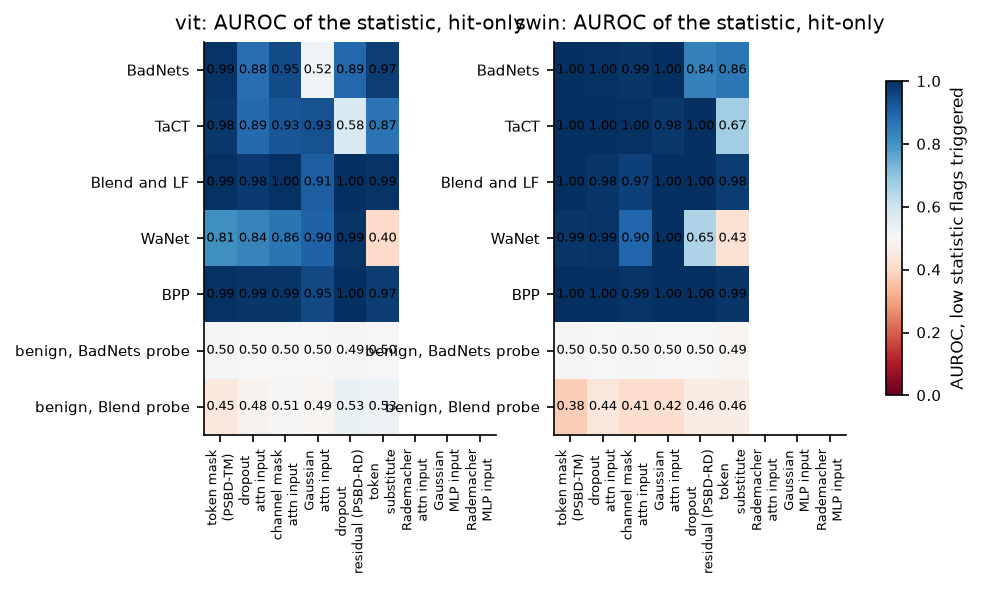

,token_mask,dropout,channel_mask,gaussian,residual_dropout
model,,,,,
swin_cifar100_badnet_a2o_0_05,1.000,1.000,0.997,1.000,0.896
swin_cifar100_benign:badnet_a2o,0.489,0.497,0.491,0.489,0.498
swin_cifar100_benign:blend,0.378,0.474,0.499,0.426,0.612
swin_cifar100_blend_0_05,1.000,1.000,1.000,1.000,1.000
swin_cifar100_bpp_0_05,0.999,0.998,0.986,0.997,0.996
swin_cifar100_lf_0_05,0.986,0.948,0.908,0.982,0.987
swin_cifar100_wanet_0_1,0.937,0.961,0.822,0.958,0.838
swin_cifar10_tact_0_01,0.995,0.999,0.993,0.961,1.000
swin_cifar10_tact_0_05,1.000,0.999,0.999,1.000,0.996


In [8]:
fig, axes = plt.subplots(1, len(ARCHITECTURES), figsize=(TEXT_WIDTH, 3.4),
                         squeeze=False, sharey=False)
for axis, architecture in zip(axes[0], ARCHITECTURES):
    groups = groups_of(architecture)
    grid = np.array([
        [group_mean(architecture, g)["operators"].get(op, {}).get("auroc_hit_only") or np.nan
         for op in OPERATORS]
        for g in groups
    ])
    image = axis.imshow(grid, cmap="RdBu", vmin=0.0, vmax=1.0, aspect="auto")
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            if np.isfinite(grid[i, j]):
                axis.text(j, i, f"{grid[i, j]:.2f}", ha="center", va="center", fontsize=6)
    axis.set_xticks(range(len(OPERATORS)))
    axis.set_xticklabels([OPERATOR_LABEL[o] for o in OPERATORS], rotation=90, fontsize=6)
    axis.set_yticks(range(len(groups)))
    axis.set_yticklabels([GROUP_LABEL.get(g, g) for g in groups], fontsize=7)
    axis.set_title(f"{architecture}: AUROC of the statistic, hit-only")
    axis.grid(False)
fig.colorbar(image, ax=axes[0].tolist(), shrink=0.8, label="AUROC, low statistic flags triggered")
plt.show()

pd.DataFrame(
    [
        {
            "model": r["name"],
            **{op: r["operators"][op]["auroc_paired"] for op in HEADLINE_OPERATORS},
        }
        for r in summary["per_model"]
    ]
).set_index("model").round(3)

An AUROC hides the shape of the 2 populations. The next figure shows, for 1 model per category (named under it), the per-image statistic of the clean twins and of the triggered hit images, under PSBD-TM (top row) and PSBD-RD (bottom row). The x axis is $\phi$, the fraction of the own-class probability lost on average over the passes, from 0 (nothing lost) to 1 (all of it lost). Values below 0 mean the passes raised it. Look at where the mass of each population sits and at how much the 2 overlap, since the overlap is what the threshold has to cut through.

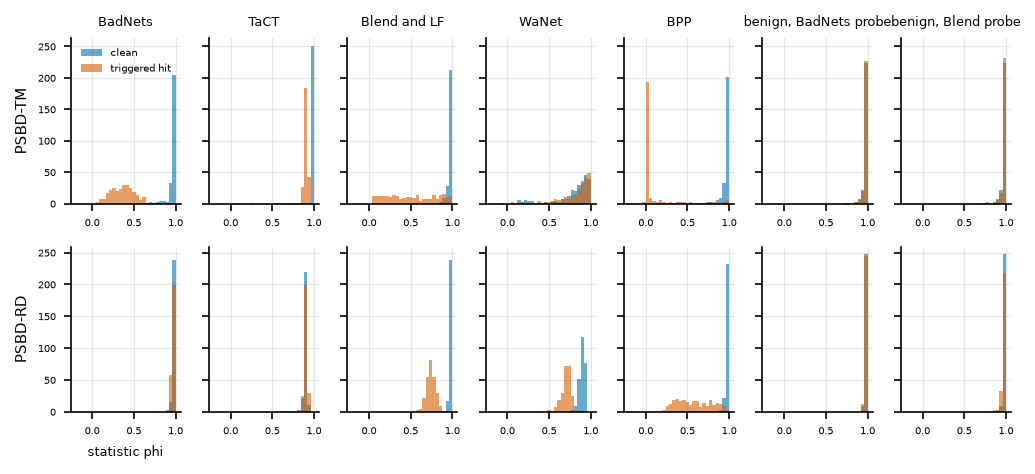

{'patch': 'vit_cifar100_badnet_a2o_0_05', 'patch_tact': 'vit_cifar10_tact_0_01', 'blend': 'vit_cifar100_blend_0_05', 'warp': 'vit_cifar10_wanet_0_1', 'quantization': 'vit_cifar100_bpp_0_05', 'benign_probe_badnet_a2o': 'vit_cifar100_benign:badnet_a2o', 'benign_probe_blend': 'vit_cifar100_benign:blend'}


In [9]:
# 1 model per group: the per-image statistic under PSBD-TM and PSBD-RD, clean
# twins against triggered hit images, read from the model's own record.
examples = {}
for r in summary["per_model"]:
    if r["architecture"] == "vit" and r["group"] not in examples and (r["successful_2pt"] or r["category"] == "benign"):
        examples[r["group"]] = r["name"]
ordered = [g for g in groups_of("vit") if g in examples]
fig, axes = plt.subplots(2, len(ordered), figsize=(TEXT_WIDTH, 3.2), squeeze=False, sharey="row")
bins = np.linspace(-0.2, 1.0, 31)
for column, g in enumerate(ordered):
    name = examples[g].replace(":", "__probe_")
    record = json.loads((RESULTS / f"{name}.json").read_text())
    hit = np.array(record["baseline"]["hit"], dtype=bool)
    for row, op in enumerate(("token_mask", "residual_dropout")):
        block = record["operators"][op]
        clean = np.array(block["clean"]["psu_ratio"], dtype=float)
        triggered = np.array(block["triggered"]["psu_ratio"], dtype=float)[hit]
        axis = axes[row][column]
        axis.hist(clean, bins=bins, alpha=0.6, label="clean", color=OKABE_ITO[0])
        axis.hist(triggered, bins=bins, alpha=0.6, label="triggered hit", color=OKABE_ITO[1])
        if row == 0:
            axis.set_title(GROUP_LABEL.get(g, g), fontsize=6)
        if column == 0:
            axis.set_ylabel(["PSBD-TM", "PSBD-RD"][row], fontsize=7)
        axis.tick_params(labelsize=5)
axes[1][0].set_xlabel("statistic phi", fontsize=6)
axes[0][0].legend(fontsize=5)
plt.tight_layout()
plt.show()
print({g: examples[g] for g in ordered})

In [10]:
lines = []
for architecture in ARCHITECTURES:
    attacks = attack_groups(architecture)
    benign = benign_groups(architecture)
    weakest = {g: min(HEADLINE_OPERATORS, key=lambda o: group_mean(architecture, g)["operators"][o]["auroc_hit_only"] or 1)
               for g in attacks}
    separating = by_status(architecture, "phenomenon")
    benign_spread = [abs((group_mean(architecture, g)["operators"][o]["auroc_hit_only"] or 0.5) - 0.5)
                     for g in benign for o in OPERATORS if o in group_mean(architecture, g)["operators"]]
    lines.append(
        f"On {architecture}, the statistic separates with at least {T['separating_operators']} of the "
        f"{len(HEADLINE_OPERATORS)} headline operators (AUROC {T['separating_auroc']} or more) for "
        f"{listed(group_name(g) for g in separating.get('supported', []))}"
        + (f", and with fewer for {listed(group_name(g) for g in separating.get('partial', []) + separating.get('refuted', []))}" if separating.get('partial') or separating.get('refuted') else "")
        + ". The weakest headline operator per category is "
        + listed(f"{OPERATOR_LABEL[weakest[g]].split(chr(10))[0]} for {group_name(g)} ({fmt(group_mean(architecture, g)['operators'][weakest[g]]['auroc_hit_only'])})" for g in attacks)
        + f". The benign probes stay within {fmt(max(benign_spread) if benign_spread else None)} of 0.5 over every operator."
    )
say("**What it shows.** " + " ".join(lines) + " The statistic is therefore not a property of 1 operator: whatever makes it work has to hold for masks, elementwise dropout and additive noise alike, which is the question of the next steps. A benign model reading the same triggered images at chance says the separation comes from the backdoor and not from the trigger's appearance.")
say("**What it does not show.** The AUROCs are on this experiment's pairs, triggered images that reach the target against their clean twins, at each placement's own rate. They are not the paper's panel numbers, which use the full splits and the pipeline's pass count. The figure says that the statistic works, not why.")

<!-- results:begin -->
**What it shows.** On vit, the statistic separates with at least 4 of the 5 headline operators (AUROC 0.7 or more) for BadNets, TaCT, Blend and LF, WaNet and BPP. The weakest headline operator per category is Gaussian for BadNets (0.521), dropout for TaCT (0.576), Gaussian for Blend and LF (0.910), token mask for WaNet (0.807) and Gaussian for BPP (0.951). The benign probes stay within 0.054 of 0.5 over every operator. On swin, the statistic separates with at least 4 of the 5 headline operators (AUROC 0.7 or more) for BadNets, TaCT, Blend and LF, WaNet and BPP. The weakest headline operator per category is dropout for BadNets (0.836), Gaussian for TaCT (0.981), channel mask for Blend and LF (0.967), dropout for WaNet (0.654) and channel mask for BPP (0.992). The benign probes stay within 0.123 of 0.5 over every operator. The statistic is therefore not a property of 1 operator: whatever makes it work has to hold for masks, elementwise dropout and additive noise alike, which is the question of the next steps. A benign model reading the same triggered images at chance says the separation comes from the backdoor and not from the trigger's appearance.
<!-- results:end -->

<!-- results:begin -->
**What it does not show.** The AUROCs are on this experiment's pairs, triggered images that reach the target against their clean twins, at each placement's own rate. They are not the paper's panel numbers, which use the full splits and the pipeline's pass count. The figure says that the statistic works, not why.
<!-- results:end -->

## Step 2. H-margin: does the triggered answer keep its margin?

**Question.** The most direct reading of the phenomenon is about margins. A perturbation moves every logit a little. An answer whose logit leads the runner-up by a lot survives and 1 that leads by a little does not. If triggered answers simply start with larger margins, PSBD is a margin detector and needs no perturbation at all. If they start with margins like clean ones and lose less of them, something in the triggered representation protects the margin, which is what the next steps look for.

**What is measured** (`measure.per_image_statistics`, `summarize.margin_matched_auroc`). The own-class margin, unperturbed and on every pass, and its retention:

$$m(x) = z_c(x) - \max_{i\neq c} z_i(x), \qquad m_j(x) = z_c(x;\xi_j) - \max_{i \neq c} z_i(x;\xi_j), \qquad r(x) = \frac{\tfrac{1}{k}\sum_j m_j(x)}{m(x)}$$

| symbol | meaning |
|---|---|
| $z_i(x)$, $z_i(x;\xi_j)$ | the logit of class $i$, unperturbed and on pass $j$ |
| $m$, $m_j$ | the own-class margin, negative once the answer has flipped |
| $r$ | margin retention, 1 when the perturbation leaves the margin whole |

- Panel a: the AUROC of the unperturbed margin and of the unperturbed confidence $P_c(x)$, with a larger value on the triggered image as the positive direction. If these match the statistic's AUROC, the perturbation adds nothing.
- Panel b: the median retention of triggered hit images (solid) and of clean images (dotted) under the 5 headline operators, 1 line per category.
- Panel c: the statistic's AUROC against its margin-matched AUROC, 1 point per model and operator. Each triggered image is paired with the clean image of the nearest unperturbed margin. A point on the diagonal means equal starting margins do not reduce the separation, a point far below it means the separation came from larger starting margins.

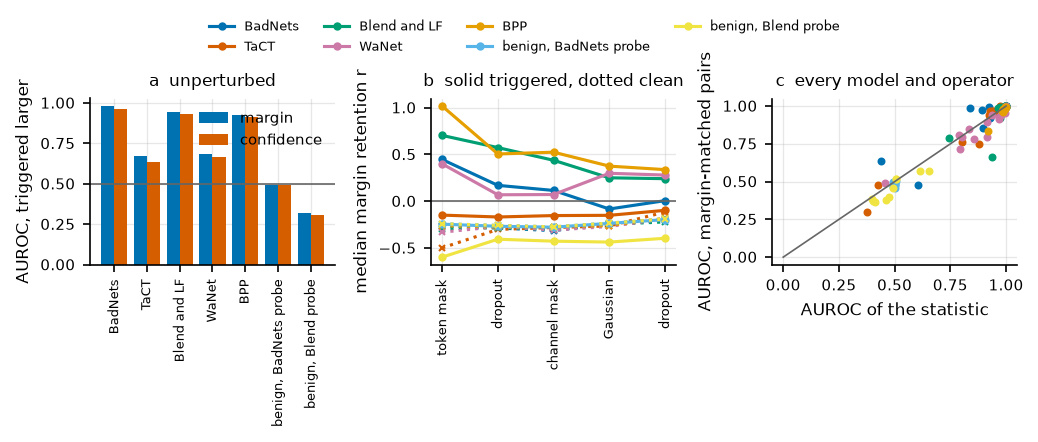

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(TEXT_WIDTH, 2.6))
architecture = "vit"
groups = groups_of(architecture)

# Panel a: does the unperturbed margin or confidence already separate?
x = np.arange(len(groups))
axes[0].bar(x - 0.2, [group_mean(architecture, g)["auroc_margin_unperturbed"] for g in groups],
            0.4, label="margin", color=OKABE_ITO[0])
axes[0].bar(x + 0.2, [group_mean(architecture, g)["auroc_confidence_unperturbed"] for g in groups],
            0.4, label="confidence", color=OKABE_ITO[1])
axes[0].axhline(0.5, color="0.4", linewidth=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels([GROUP_LABEL.get(g, g) for g in groups], rotation=90, fontsize=6)
axes[0].set_ylabel("AUROC, triggered larger")
axes[0].set_title("a  unperturbed", fontsize=8)
axes[0].legend()

# Panel b: margin retention under each headline operator, clean against triggered.
for index, g in enumerate(groups):
    operators = group_mean(architecture, g)["operators"]
    clean = [operators[o]["clean_margin_retention"] for o in HEADLINE_OPERATORS]
    triggered = [operators[o]["triggered_margin_retention"] for o in HEADLINE_OPERATORS]
    color = OKABE_ITO[index % len(OKABE_ITO)]
    axes[1].plot(range(5), triggered, "-o", color=color, markersize=3,
                 label=GROUP_LABEL.get(g, g))
    axes[1].plot(range(5), clean, ":", color=color, marker="x", markersize=3)
axes[1].axhline(0.0, color="0.4", linewidth=0.8)
axes[1].set_xticks(range(5))
axes[1].set_xticklabels([OPERATOR_LABEL[o].split("\n")[0] for o in HEADLINE_OPERATORS],
                        rotation=90, fontsize=6)
axes[1].set_ylabel("median margin retention r")
axes[1].set_title("b  solid triggered, dotted clean", fontsize=8)

# Panel c: the statistic's AUROC against its margin-matched AUROC, 1 point per
# model and operator.
for index, g in enumerate(groups):
    for r in models_of(architecture, g):
        raw = [r["operators"][o]["auroc_hit_only"] for o in HEADLINE_OPERATORS]
        matched = [r["operators"][o]["margin_matched_auroc"] for o in HEADLINE_OPERATORS]
        axes[2].scatter(raw, matched, s=8, color=OKABE_ITO[index % len(OKABE_ITO)])
axes[2].plot([0, 1], [0, 1], color="0.4", linewidth=0.8)
axes[2].set_xlabel("AUROC of the statistic")
axes[2].set_ylabel("AUROC, margin-matched pairs")
axes[2].set_title("c  every model and operator", fontsize=8)
fig.legend(*axes[1].get_legend_handles_labels(), loc="upper center",
           bbox_to_anchor=(0.5, 1.12), ncol=4, fontsize=6)
plt.tight_layout()
plt.show()

In [12]:
architecture = "vit"
attacks = attack_groups(architecture)
rows = []
for g in attacks:
    m = group_mean(architecture, g)
    v = verdict_of(architecture, g, "margin")
    rows.append((g, m["auroc_margin_unperturbed"], m["auroc_confidence_unperturbed"],
                 m["operators"]["token_mask"]["auroc_hit_only"], v["value"], v.get("auroc_lost_to_margin_matching")))
lowest_margin = min(rows, key=lambda r: r[1])
largest_loss = max(rows, key=lambda r: r[5] or 0)
larger_start = all((r[1] or 0) > 0.6 for r in rows)
say(f"""**What it shows.** Triggered images {'do' if larger_start else 'do not all'} start with larger margins: the unperturbed margin alone separates at {listed(f"{fmt(r[1])} for {group_name(r[0])}" for r in rows)}. That is below the statistic under PSBD-TM ({listed(f"{fmt(r[3])} for {group_name(r[0])}" for r in rows)}). The gap is widest for {group_name(lowest_margin[0])}. The perturbation does the rest. Under every separating operator the median clean margin turns negative (the answer flips), while the triggered margin keeps a positive share, a retention gap of {listed(f"{fmt(r[4])} for {group_name(r[0])}" for r in rows)} averaged over the separating operators. Matching each triggered image with a clean image of the same starting margin costs the statistic at most {fmt(largest_loss[5])} AUROC ({group_name(largest_loss[0])}), so the separation is not the starting margin in disguise: at equal margins, triggered answers lose less. The H-margin rule reads {status_sentence(architecture, 'margin')}.""")
say("""**What it does not show.** Margin retention is the statistic seen through the logits, so its separating is close to a restatement. What the step rules out is the cheap reading, that triggered answers survive because they start further from the boundary. It does not say what protects the triggered margin, which is the next question: the margin is a readout of 1 feature vector, so the protection must show in that vector.""")

<!-- results:begin -->
**What it shows.** Triggered images do start with larger margins: the unperturbed margin alone separates at 0.979 for BadNets, 0.671 for TaCT, 0.943 for Blend and LF, 0.686 for WaNet and 0.926 for BPP. That is below the statistic under PSBD-TM (0.990 for BadNets, 0.983 for TaCT, 0.993 for Blend and LF, 0.807 for WaNet and 0.994 for BPP). The gap is widest for TaCT. The perturbation does the rest. Under every separating operator the median clean margin turns negative (the answer flips), while the triggered margin keeps a positive share, a retention gap of 0.451 for BadNets, 0.181 for TaCT, 0.711 for Blend and LF, 0.497 for WaNet and 0.802 for BPP averaged over the separating operators. Matching each triggered image with a clean image of the same starting margin costs the statistic at most 0.026 AUROC (WaNet), so the separation is not the starting margin in disguise: at equal margins, triggered answers lose less. The H-margin rule reads supported for BadNets (0.451), Blend and LF (0.711), WaNet (0.497) and BPP (0.802), partial for TaCT (0.181).
<!-- results:end -->

<!-- results:begin -->
**What it does not show.** Margin retention is the statistic seen through the logits, so its separating is close to a restatement. What the step rules out is the cheap reading, that triggered answers survive because they start further from the boundary. It does not say what protects the triggered margin, which is the next question: the margin is a readout of 1 feature vector, so the protection must show in that vector.
<!-- results:end -->

## Step 3. H-direction: what protects the triggered margin?

**Question.** Step 2 establishes whether the triggered margin survives better, and whether that survives margin matching. The margin is a linear readout of 1 feature vector, the class token after the final LayerNorm on ViT and the pooled final feature map on Swin, so whatever protects it must be visible in that vector. The candidate from earlier work in this repository (`experiments/backdoor_neurons/`) is the backdoor direction: removing 1 direction from the residual stream removes the backdoor, while zeroing many coordinates does not. If the triggered feature is dominated by that direction, and the perturbation dents it less than it dents a clean image's class evidence, the margin is protected.

**What is measured** (`measure.feature_geometry`, `measure.feature_statistics`). With $f(x)$ the feature, $\mu$ the mean clean feature, $\tilde x$ the triggered twin of $x$, $H$ the hit pairs and $W$ the head's weights:

$$d = \frac{1}{|H|}\sum_{x \in H}\big(f(\tilde x) - f(x)\big), \qquad u = \frac{d}{\lVert d\rVert}, \qquad e_c = \frac{W_c - \bar W}{\lVert W_c - \bar W\rVert}$$

$$s_u(x) = \langle f(x) - \mu, u\rangle, \qquad \text{share}(x) = \frac{s_u(x)^2}{\lVert f(x) - \mu\rVert^2}, \qquad \text{SPR}_u(x) = \frac{s_u(x)}{\sqrt{\tfrac{1}{k}\sum_j \langle f_j(x) - f(x), u\rangle^2}}$$

| symbol | meaning |
|---|---|
| $d$, $u$ | the backdoor direction (`analysis.direction.backdoor_direction`) and its unit vector |
| $W_c$, $\bar W$ | the head's row for class $c$ and the mean row |
| $e_c$ | the class direction of $c$, along which the logit of $c$ rises against the average class |
| $f_j(x)$ | the feature on pass $j$ |
| $s_u$ | the backdoor component of an image's deviation from the clean mean |
| share | the fraction of that deviation the backdoor component makes up |
| $\text{SPR}_u$ | signal to perturbation ratio: the component over the perturbation's spread along the same direction |

The clean counterpart uses $e_c$ of the image's own class in place of $u$.

- Panel a: the median share on triggered hit images per category, next to the cosine between $u$ and the target's readout direction $e_t$.
- Panel b: the ratio of the triggered SPR along $u$ to the clean SPR along $e_c$, per operator. Above 1 means the triggered component stands further above the perturbation noise than the clean class evidence does.
- Panel c: the literature memo's L8 test, the per-image Spearman correlation between $\phi$ and the fraction of the backdoor projection a pass loses. Most triggered images never flip under PSBD-TM, so their $\phi$ sits at the bfloat16 floor, and the theory note asks for the correlation on triggered images above a small floor of $\phi$ and on clean and triggered images pooled. The dashed lines are the theory note's supported and refuted values.

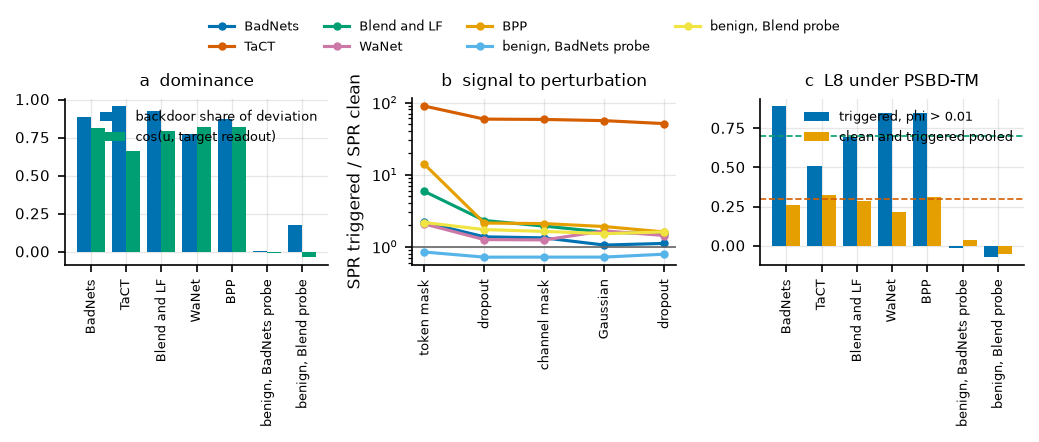

,token_mask L8 above floor,dropout L8 above floor,channel_mask L8 above floor,gaussian L8 above floor,residual_dropout L8 above floor,triggered share above floor (TM)
group,,,,,,
BadNets,0.892,0.916,0.909,0.965,0.851,0.992
TaCT,0.506,0.394,0.420,0.481,0.393,1.000
Blend and LF,0.693,0.864,0.937,0.986,0.878,0.454
WaNet,0.847,0.930,0.926,0.943,0.870,0.750
BPP,0.845,0.946,0.932,0.976,0.977,0.155
"benign, BadNets probe",-0.012,0.021,-0.002,0.216,-0.007,0.998
"benign, Blend probe",-0.073,-0.259,-0.238,0.058,-0.224,0.998


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(TEXT_WIDTH, 2.6))
architecture = "vit"
groups = groups_of(architecture)
x = np.arange(len(groups))

# Panel a: how much of a triggered image's deviation from the clean mean lies on
# the backdoor direction, and the cosine between that direction and the target's
# readout direction in the head.
share = [group_mean(architecture, g)["operators"]["token_mask"]["triggered_backdoor_share"] for g in groups]
cosine = [group_mean(architecture, g)["cosine_backdoor_target_readout"] for g in groups]
axes[0].bar(x - 0.2, share, 0.4, color=OKABE_ITO[0], label="backdoor share of deviation")
axes[0].bar(x + 0.2, cosine, 0.4, color=OKABE_ITO[2], label="cos(u, target readout)")
axes[0].set_xticks(x)
axes[0].set_xticklabels([GROUP_LABEL.get(g, g) for g in groups], rotation=90, fontsize=6)
axes[0].set_title("a  dominance", fontsize=8)
axes[0].legend(fontsize=6)

# Panel b: signal to perturbation ratio, triggered along u over clean along its
# own class direction, per operator. Above 1 means the triggered component stands
# further above the perturbation's noise than the clean class evidence does.
for index, g in enumerate(groups):
    operators = group_mean(architecture, g)["operators"]
    ratios = [
        (operators[o]["triggered_backdoor_spr"] or np.nan) / (operators[o]["clean_class_spr"] or np.nan)
        for o in HEADLINE_OPERATORS
    ]
    axes[1].plot(range(5), ratios, "-o", markersize=3, color=OKABE_ITO[index % 8],
                 label=GROUP_LABEL.get(g, g))
axes[1].axhline(1.0, color="0.4", linewidth=0.8)
axes[1].set_yscale("log")
axes[1].set_xticks(range(5))
axes[1].set_xticklabels([OPERATOR_LABEL[o].split("\n")[0] for o in HEADLINE_OPERATORS], rotation=90, fontsize=6)
axes[1].set_ylabel("SPR triggered / SPR clean")
axes[1].set_title("b  signal to perturbation", fontsize=8)

# Panel c: memo L8, the per-image Spearman correlation between the statistic and
# the fractional loss of the backdoor projection, on triggered images above the
# bfloat16 floor and on clean and triggered pooled.
width = 0.4
for offset, key, label in ((-0.2, "spearman_psu_backdoor_drop_above_floor", "triggered, phi > 0.01"),
                           (0.2, "spearman_psu_backdoor_drop_pooled", "clean and triggered pooled")):
    values = [group_mean(architecture, g)["operators"]["token_mask"].get(key) for g in groups]
    axes[2].bar(x + offset, [np.nan if v is None else v for v in values], width, label=label)
axes[2].axhline(0.7, color=OKABE_ITO[2], linewidth=0.8, linestyle="--")
axes[2].axhline(0.3, color=OKABE_ITO[1], linewidth=0.8, linestyle="--")
axes[2].set_xticks(x)
axes[2].set_xticklabels([GROUP_LABEL.get(g, g) for g in groups], rotation=90, fontsize=6)
axes[2].set_title("c  L8 under PSBD-TM", fontsize=8)
axes[2].legend(fontsize=6)
fig.legend(*axes[1].get_legend_handles_labels(), loc="upper center", bbox_to_anchor=(0.5, 1.12), ncol=4, fontsize=6)
plt.tight_layout()
plt.show()

pd.DataFrame(
    [
        {
            "group": GROUP_LABEL.get(g, g),
            **{
                f"{op} L8 above floor": group_mean("vit", g)["operators"][op].get("spearman_psu_backdoor_drop_above_floor")
                for op in HEADLINE_OPERATORS
            },
            "triggered share above floor (TM)": group_mean("vit", g)["operators"]["token_mask"].get("triggered_share_above_floor"),
        }
        for g in groups_of("vit")
    ]
).set_index("group").round(3)

In [14]:
architecture = "vit"
attacks = attack_groups(architecture)
m = {g: group_mean(architecture, g) for g in attacks}
ratio_tm = {g: (m[g]["operators"]["token_mask"]["triggered_backdoor_spr"] or np.nan) / (m[g]["operators"]["token_mask"]["clean_class_spr"] or np.nan) for g in attacks}
say(f"""**What it shows.** The triggered feature's deviation from the clean mean lies mostly on the backdoor direction: a median share of {listed(f"{fmt(m[g]['operators']['token_mask']['triggered_backdoor_share'])} for {group_name(g)}" for g in attacks)}. The direction points close to the target's readout (cosine {listed(f"{fmt(m[g]['cosine_backdoor_target_readout'])} for {group_name(g)}" for g in attacks)}). Under PSBD-TM the triggered backdoor component keeps a median {listed(f"{fmt(m[g]['operators']['token_mask']['triggered_backdoor_retention'])}" for g in attacks)} of itself, in the same order, while a clean image's component along its own class direction keeps {listed(f"{fmt(m[g]['operators']['token_mask']['clean_class_retention'])}" for g in attacks)}. The triggered signal stands {listed(f"{fmt(ratio_tm[g], 2)} times" for g in attacks)} further above the perturbation's noise than clean class evidence does. Per image, the statistic tracks how much of the backdoor projection a pass removes: the L8 Spearman correlation on triggered images above the floor is {listed(f"{fmt(m[g]['operators']['token_mask']['spearman_psu_backdoor_drop_above_floor'])} for {group_name(g)}" for g in attacks)}. The H-direction rule reads {status_sentence(architecture, 'direction')}.""")
say(f"""**What it does not show.** The pooled correlation, clean and triggered images together, is low ({listed(fmt(m[g]['operators']['token_mask']['spearman_psu_backdoor_drop_pooled']) for g in attacks)}): clean images have no backdoor component to lose, so their statistic is set by their own class evidence, and 1 projection cannot order both populations. The direction explains the triggered side. It does not explain why the backdoor component survives a perturbation that destroys the clean class component, since both are directions of the same feature. The next step looks for the reason in how the evidence is spread over tokens.""")

<!-- results:begin -->
**What it shows.** The triggered feature's deviation from the clean mean lies mostly on the backdoor direction: a median share of 0.883 for BadNets, 0.957 for TaCT, 0.923 for Blend and LF, 0.776 for WaNet and 0.874 for BPP. The direction points close to the target's readout (cosine 0.814 for BadNets, 0.663 for TaCT, 0.793 for Blend and LF, 0.817 for WaNet and 0.817 for BPP). Under PSBD-TM the triggered backdoor component keeps a median 0.589, 0.659, 0.715, 0.439 and 0.986 of itself, in the same order, while a clean image's component along its own class direction keeps 0.039, -21.294, 0.040, 0.061 and 0.065. The triggered signal stands 2.17 times, 89.31 times, 5.84 times, 2.06 times and 13.92 times further above the perturbation's noise than clean class evidence does. Per image, the statistic tracks how much of the backdoor projection a pass removes: the L8 Spearman correlation on triggered images above the floor is 0.892 for BadNets, 0.506 for TaCT, 0.693 for Blend and LF, 0.847 for WaNet and 0.845 for BPP. The H-direction rule reads supported for BadNets (0.892), WaNet (0.847) and BPP (0.845), partial for TaCT (0.506) and Blend and LF (0.693).
<!-- results:end -->

<!-- results:begin -->
**What it does not show.** The pooled correlation, clean and triggered images together, is low (0.262, 0.323, 0.287, 0.215 and 0.314): clean images have no backdoor component to lose, so their statistic is set by their own class evidence, and 1 projection cannot order both populations. The direction explains the triggered side. It does not explain why the backdoor component survives a perturbation that destroys the clean class component, since both are directions of the same feature. The next step looks for the reason in how the evidence is spread over tokens.
<!-- results:end -->

## Step 4. H-redundancy: where the dominant component comes from

**Question.** A dominant backdoor component explains why the margin survives, not why the component itself survives a perturbation that removes most of a clean image's evidence. The perturbations act on tokens, and a token-level reason is that the trigger's evidence is present in many tokens, so removing any subset leaves the rest to carry it. That is the redundancy account (memo L19 and L23). Section D of `experiments/why_token_masking_works/` measured it on ViT with a few patterns shared by every model, which the audit found too few and not independent. This step repeats it with many patterns seeded per model, adds a control for patch triggers and runs it on Swin.

**What is measured** (`measure.measure_redundancy`, `measure.SubsetTokenMask`). A fixed random pattern of the 14 by 14 patch grid stays visible, and every other patch token is zeroed at the input of every block's attention LayerNorm (on Swin the pattern is resized to each stage's grid). A zeroed token enters attention as the LayerNorm's bias, so the network sees the visible tokens' content only. Solid lines are the share of triggered hit images still sent to the target, dotted lines the share of clean images keeping their answer. A masked model can collapse onto 1 default class, sometimes the target, so the verdict reads the excess retention, the target share of triggered images minus that of clean images relative to its value with every token visible:

$$\text{excess}(f) = \frac{\text{ASR}(f) - \text{clean on target}(f)}{\text{ASR}(1) - \text{clean on target}(1)}$$

with $f$ the visible fraction. For patch triggers the dashed line repeats every pattern with the trigger's own tokens forced visible. If triggered survival holds only when the trigger stays visible, random patterns protect a patch trigger by rarely hiding its few tokens, which is geometry and not redundancy.

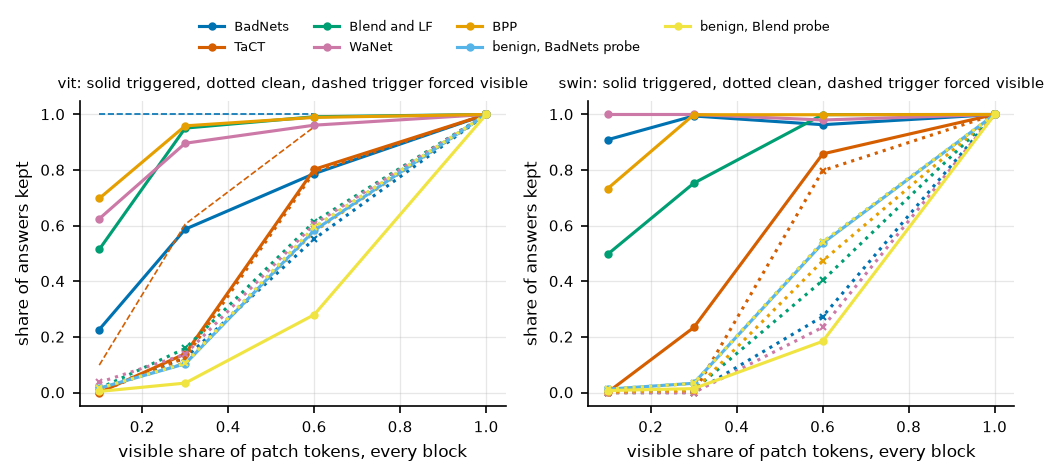

In [15]:
fig, axes = plt.subplots(1, len(ARCHITECTURES), figsize=(TEXT_WIDTH, 2.8), squeeze=False)
for axis, architecture in zip(axes[0], ARCHITECTURES):
    for index, g in enumerate(groups_of(architecture)):
        redundancy = group_mean(architecture, g)["redundancy"]
        fractions = sorted(redundancy, key=float)
        f = [float(v) for v in fractions]
        color = OKABE_ITO[index % 8]
        axis.plot(f, [redundancy[v]["triggered_kept"] for v in fractions], "-o", color=color,
                  markersize=3, label=GROUP_LABEL.get(g, g))
        axis.plot(f, [redundancy[v]["clean_kept"] for v in fractions], ":", color=color, marker="x", markersize=3)
        forced = [redundancy[v].get("trigger_forced_triggered_kept") for v in fractions]
        if any(v is not None for v in forced):
            axis.plot(f, [np.nan if v is None else v for v in forced], "--", color=color, linewidth=0.8)
    axis.set_xlabel("visible share of patch tokens, every block")
    axis.set_ylabel("share of answers kept")
    axis.set_title(f"{architecture}: solid triggered, dotted clean, dashed trigger forced visible", fontsize=7)
fig.legend(*axes[0][0].get_legend_handles_labels(), loc="upper center", bbox_to_anchor=(0.5, 1.12), ncol=4, fontsize=6)
plt.tight_layout()
plt.show()

In [16]:
lines = []
for architecture in ARCHITECTURES:
    attacks = attack_groups(architecture)
    red = {g: group_mean(architecture, g)["redundancy"].get(T["redundancy_fraction"], {}) for g in attacks}
    lines.append(
        f"On {architecture}, with {T['redundancy_fraction']} of the patch tokens visible in every block, the excess retention of triggered answers is "
        + listed(f"{fmt(red[g].get('excess_retention'))} for {group_name(g)} (clean answers kept {fmt(red[g].get('clean_kept'))})" for g in attacks)
        + f". The H-redundancy rule reads {status_sentence(architecture, 'redundancy')}."
    )
patch = [g for g in attack_groups("vit") if g.startswith("patch")]
forced = {g: group_mean("vit", g)["redundancy"].get(T["redundancy_fraction"], {}) for g in patch}
if patch:
    lines.append(
        "For the patch triggers on ViT, forcing the trigger's tokens visible keeps "
        + listed(f"{fmt(forced[g].get('trigger_forced_triggered_kept'))} of triggered answers for {group_name(g)} against {fmt(forced[g].get('triggered_kept'))} with random patterns" for g in patch)
        + ", the difference between a trigger that is spread and 1 that is merely rarely hidden."
    )
say("**What it shows.** " + " ".join(lines))
say("""**What it does not show.** A fixed pattern removes tokens in every block, which is harsher than any operator used for detection, and the pattern is on the 14 by 14 patch grid, so a trigger whose evidence is finer than a token is not resolved. The test reads survival of the answer, not of the backdoor component itself. What it establishes is whether any sizeable subset of tokens carries enough of the trigger to write the backdoor direction on its own, which is what protects that direction from a perturbation that removes a random part of the computation.""")

<!-- results:begin -->
**What it shows.** On vit, with 0.3 of the patch tokens visible in every block, the excess retention of triggered answers is 0.580 for BadNets (clean answers kept 0.124), 0.137 for TaCT (clean answers kept 0.126), 0.888 for Blend and LF (clean answers kept 0.159), 0.493 for WaNet (clean answers kept 0.138) and 0.946 for BPP (clean answers kept 0.108). The H-redundancy rule reads supported for Blend and LF (0.888) and BPP (0.946), partial for BadNets (0.580) and WaNet (0.493), refuted for TaCT (0.137). On swin, with 0.3 of the patch tokens visible in every block, the excess retention of triggered answers is 0.008 for BadNets (clean answers kept 0.000), 0.235 for TaCT (clean answers kept 0.000), 0.257 for Blend and LF (clean answers kept 0.009), 0.000 for WaNet (clean answers kept 0.000) and 0.530 for BPP (clean answers kept 0.007). The H-redundancy rule reads supported for BPP (0.530), partial for TaCT (0.235) and Blend and LF (0.257), refuted for BadNets (0.008) and WaNet (0.000). For the patch triggers on ViT, forcing the trigger's tokens visible keeps 1.000 of triggered answers for BadNets against 0.588 with random patterns and 0.606 of triggered answers for TaCT against 0.140 with random patterns, the difference between a trigger that is spread and 1 that is merely rarely hidden.
<!-- results:end -->

<!-- results:begin -->
**What it does not show.** A fixed pattern removes tokens in every block, which is harsher than any operator used for detection, and the pattern is on the 14 by 14 patch grid, so a trigger whose evidence is finer than a token is not resolved. The test reads survival of the answer, not of the backdoor component itself. What it establishes is whether any sizeable subset of tokens carries enough of the trigger to write the backdoor direction on its own, which is what protects that direction from a perturbation that removes a random part of the computation.
<!-- results:end -->

### Step 4b. WaNet's warp as a coherence check (L26)

**Question.** WaNet is the attack whose evidence survives token removal least among the global triggers in earlier work, and the literature memo offers a reason: WaNet trains with a noise mode, images warped by a random field that keep their true label, so the network must learn the exact warp and not "warped" as such. If the exact warp can only be told from a random warp over a wide area, no single token can read it, and the trigger is legible only where many tokens are combined, which is the class token late in the network.

**What is measured** (`wanet_probe.py`). For each WaNet model, clean analysis images, their exact-warp copies (the trigger) and their noise-warp copies (`attacks.wanet`'s own `apply_cover`). The residual stream entering several blocks is captured, and a logistic probe per block tells the exact warp from the random warp, fitted on half of the images and scored on the other half, once on single patch tokens pooled over positions and once on the class token. The theory note's prediction: single tokens near chance while the class token reaches a high accuracy. The table also gives how often the model sends each image set to the target, which checks that the noise mode worked (random warps should not fire).

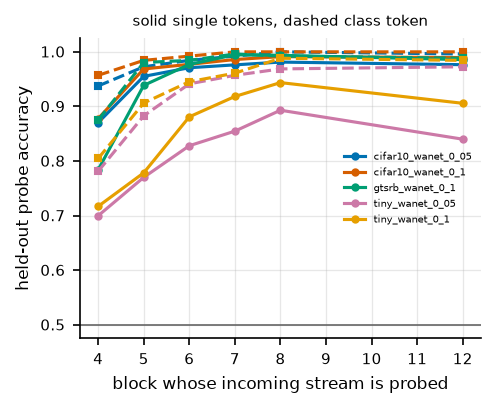

,clean on target,triggered on target,noise on target
model,,,
vit_cifar10_wanet_0_05,0.098,0.969,0.062
vit_cifar10_wanet_0_1,0.074,0.906,0.062
vit_gtsrb_wanet_0_1,0.035,0.949,0.016
vit_tiny_wanet_0_05,0.004,0.914,0.012
vit_tiny_wanet_0_1,0.004,0.969,0.008


<!-- results:begin -->
**What it shows.** Over blocks up to 8, single-token probes reach a mean held-out accuracy of 0.901 (at most 0.995) while the class-token probe reaches 0.951 (at most 1.000), and at the last probed block the class token reaches 0.988. The theory note's L26 prediction, single tokens near chance with the class token high, does not hold as stated on these models.
<!-- results:end -->

<!-- results:begin -->
**What it does not show.** A linear probe that fails does not prove that no nonlinear reading of 1 token exists, and the pooled token probe mixes positions whose warp displacement differs. The probe is fitted on half of the images of 1 dataset per model.
<!-- results:end -->

In [17]:
probe = pd.DataFrame(summary.get("wanet_probe") or [])
if not len(probe):
    say("The WaNet probe had not run when this notebook was executed.")
else:
    rows = []
    for _, r in probe.iterrows():
        for block, reading in r["blocks"].items():
            rows.append({"model": r["folder"], "successful at 2 points": r["successful_2pt"], "block": int(block),
                         "token probe": reading["token_probe_accuracy"], "class token probe": reading["cls_probe_accuracy"]})
    table = pd.DataFrame(rows)
    fig, axis = plt.subplots(figsize=(TEXT_WIDTH / 2, 2.6))
    for index, (model, part) in enumerate(table.groupby("model")):
        axis.plot(part["block"], part["token probe"], "-o", color=OKABE_ITO[index % 8], markersize=3, label=model.replace("vit_", ""))
        axis.plot(part["block"], part["class token probe"], "--s", color=OKABE_ITO[index % 8], markersize=3)
    axis.axhline(0.5, color="0.4", linewidth=0.8)
    axis.set_xlabel("block whose incoming stream is probed")
    axis.set_ylabel("held-out probe accuracy")
    axis.set_title("solid single tokens, dashed class token", fontsize=7)
    axis.legend(fontsize=5)
    plt.show()
    targets = pd.DataFrame([{"model": r["folder"], **{f"{k} on target": v for k, v in r["target_share"].items()}} for _, r in probe.iterrows()])
    display(targets.set_index("model").round(3))
    early = table[table["block"] <= 8]
    say(f"""**What it shows.** Over blocks up to 8, single-token probes reach a mean held-out accuracy of {fmt(early['token probe'].mean())} (at most {fmt(early['token probe'].max())}) while the class-token probe reaches {fmt(early['class token probe'].mean())} (at most {fmt(early['class token probe'].max())}), and at the last probed block the class token reaches {fmt(table[table['block'] == table['block'].max()]['class token probe'].mean())}. The theory note's L26 prediction, single tokens near chance with the class token high, {'holds' if early['token probe'].mean() < 0.6 and table['class token probe'].max() >= 0.9 else 'does not hold as stated'} on these models.""")
    say("""**What it does not show.** A linear probe that fails does not prove that no nonlinear reading of 1 token exists, and the pooled token probe mixes positions whose warp displacement differs. The probe is fitted on half of the images of 1 dataset per model.""")

## Step 5. H-low-dim: how concentrated the triggered decision is

**Question.** Redundancy is about how the trigger's evidence is spread over tokens. The complementary question is whether the decision that evidence produces is narrow: few feature directions, few tokens in the gradient, a small sufficient part of the input. This is the shortcut account (memo L4 and L6) in geometric form.

**What is measured.**

- Panel a (`measure.difference_spectrum`): the share of the largest eigenvalue in the uncentered second moment of the paired change $f(\tilde x) - f(x)$, against the same for the change between 2 unrelated clean images. A share near 1 means 1 direction carries the whole trigger effect.
- Panel b (`measure.measure_jacobian`): the effective number of tokens in the gradient of the margin with respect to the residual stream entering the last probed block, $\exp$ of the entropy of each token's share of the squared gradient norm, in float32.
- Panel c (`measure.measure_sufficiency`): the literature memo's L6 test, the smallest visible share of tokens that keeps each image's answer when tokens are removed in a nested order at the attention input of every block. The ranked order removes the tokens of smallest attribution first (gradient times activation at the stream entering block 1), which approximates Cognitive Distillation's optimized mask. The random order is the per-image form of step 4.

The table adds the AUROC of the sufficient share used as a detector, the Gini coefficient of expected-gradient input attributions (`analysis.attribution.expected_gradients`) and the effective rank of the Jacobian.

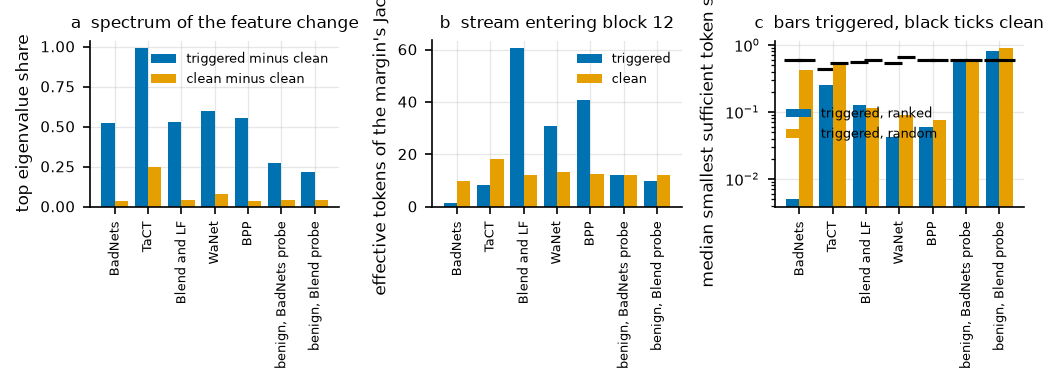

,sufficiency AUROC ranked,sufficiency AUROC random,attribution Gini triggered,attribution Gini clean,Jacobian rank triggered,Jacobian rank clean
group,,,,,,
BadNets,0.986,0.707,0.535,0.419,1.443,2.118
TaCT,0.722,0.539,0.598,0.533,2.098,1.841
Blend and LF,0.912,0.953,0.538,0.416,1.797,2.034
WaNet,0.942,0.921,0.525,0.429,2.164,2.170
BPP,0.972,0.964,0.569,0.421,2.050,2.236
"benign, BadNets probe",0.485,0.492,0.413,0.415,1.997,1.976
"benign, Blend probe",0.277,0.296,0.421,0.415,2.483,1.976


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(TEXT_WIDTH, 2.6))
architecture = "vit"
groups = groups_of(architecture)
x = np.arange(len(groups))

low = [group_mean(architecture, g)["low_dim"] for g in groups]
axes[0].bar(x - 0.2, [entry["trigger_top1_share"] for entry in low], 0.4, label="triggered minus clean")
axes[0].bar(x + 0.2, [entry["clean_pair_top1_share"] for entry in low], 0.4, label="clean minus clean")
axes[0].set_xticks(x)
axes[0].set_xticklabels([GROUP_LABEL.get(g, g) for g in groups], rotation=90, fontsize=6)
axes[0].set_ylabel("top eigenvalue share")
axes[0].set_title("a  spectrum of the feature change", fontsize=8)
axes[0].legend(fontsize=6)

last = str(max(int(b) for b in low[0]["jacobian"]))
axes[1].bar(x - 0.2, [entry["jacobian"][last]["triggered_effective_tokens"] for entry in low], 0.4, label="triggered")
axes[1].bar(x + 0.2, [entry["jacobian"][last]["clean_effective_tokens"] for entry in low], 0.4, label="clean")
axes[1].set_xticks(x)
axes[1].set_xticklabels([GROUP_LABEL.get(g, g) for g in groups], rotation=90, fontsize=6)
axes[1].set_ylabel("effective tokens of the margin's Jacobian")
axes[1].set_title(f"b  stream entering block {last}", fontsize=8)
axes[1].legend(fontsize=6)

suff = [group_mean(architecture, g)["sufficiency"] for g in groups]
for offset, order in ((-0.2, "ranked"), (0.2, "random")):
    axes[2].bar(x + offset, [s[order]["triggered_median"] for s in suff], 0.4, label=f"triggered, {order}")
    axes[2].scatter(x + offset, [s[order]["clean_median"] for s in suff], marker="_", s=80, color="k")
axes[2].set_yscale("log")
axes[2].set_xticks(x)
axes[2].set_xticklabels([GROUP_LABEL.get(g, g) for g in groups], rotation=90, fontsize=6)
axes[2].set_ylabel("median smallest sufficient token share")
axes[2].set_title("c  bars triggered, black ticks clean", fontsize=8)
axes[2].legend(fontsize=6)
plt.tight_layout()
plt.show()

pd.DataFrame(
    [
        {
            "group": GROUP_LABEL.get(g, g),
            "sufficiency AUROC ranked": group_mean("vit", g)["sufficiency"]["ranked"]["auroc"],
            "sufficiency AUROC random": group_mean("vit", g)["sufficiency"]["random"]["auroc"],
            "attribution Gini triggered": group_mean("vit", g)["low_dim"]["attribution"].get("triggered_gini"),
            "attribution Gini clean": group_mean("vit", g)["low_dim"]["attribution"].get("clean_gini"),
            "Jacobian rank triggered": group_mean("vit", g)["low_dim"]["jacobian"][last]["triggered_effective_rank"],
            "Jacobian rank clean": group_mean("vit", g)["low_dim"]["jacobian"][last]["clean_effective_rank"],
        }
        for g in groups_of("vit")
    ]
).set_index("group").round(3)

In [19]:
architecture = "vit"
attacks = attack_groups(architecture)
low = {g: group_mean(architecture, g)["low_dim"] for g in attacks}
last = str(max(int(b) for b in low[attacks[0]]["jacobian"]))
suff = {g: group_mean(architecture, g)["sufficiency"] for g in attacks}
spread_more = [g for g in attacks if (low[g]["jacobian"][last]["triggered_effective_tokens"] or 0) > (low[g]["jacobian"][last]["clean_effective_tokens"] or 0)]
say(f"""**What it shows.** In feature space the trigger effect is close to 1 direction: the top eigenvalue holds {listed(f"{fmt(low[g]['trigger_top1_share'])} for {group_name(g)}" for g in attacks)} of the paired change, against at most {fmt(max(low[g]['clean_pair_top1_share'] for g in attacks))} for the change between 2 clean images. In token space the triggered decision is not concentrated: the margin's Jacobian at block {last} spreads over more tokens for triggered than for clean images for {listed(group_name(g) for g in spread_more)} ({listed(f"{fmt(low[g]['jacobian'][last]['triggered_effective_tokens'], 1)} against {fmt(low[g]['jacobian'][last]['clean_effective_tokens'], 1)}" for g in spread_more)}). A small part of the input suffices: the ranked sufficient token share of triggered images has median {listed(f"{fmt(suff[g]['ranked']['triggered_median'])} for {group_name(g)}" for g in attacks)} against {listed(fmt(suff[g]['ranked']['clean_median']) for g in attacks)} for clean images, and as a detector it reads AUROC {listed(fmt(suff[g]['ranked']['auroc']) for g in attacks)}. The H-low-dim rule reads {status_sentence(architecture, 'low_dim')}.""")
say("""**What it does not show.** Low dimension and redundancy are 2 sides of 1 picture rather than rivals: the trigger writes 1 direction, and many different small token subsets can write it. The ranked order is 1 gradient, not Cognitive Distillation's optimization, so the sufficient share is an upper bound on the smallest set. The Jacobian is local and says nothing about the finite perturbations of the detector, which is what the flatness step asks about.""")

<!-- results:begin -->
**What it shows.** In feature space the trigger effect is close to 1 direction: the top eigenvalue holds 0.522 for BadNets, 0.989 for TaCT, 0.531 for Blend and LF, 0.601 for WaNet and 0.553 for BPP of the paired change, against at most 0.248 for the change between 2 clean images. In token space the triggered decision is not concentrated: the margin's Jacobian at block 12 spreads over more tokens for triggered than for clean images for Blend and LF, WaNet and BPP (60.5 against 12.1, 30.8 against 13.4 and 40.6 against 12.4). A small part of the input suffices: the ranked sufficient token share of triggered images has median 0.005 for BadNets, 0.250 for TaCT, 0.126 for Blend and LF, 0.042 for WaNet and 0.060 for BPP against 0.600, 0.433, 0.550, 0.533 and 0.600 for clean images, and as a detector it reads AUROC 0.986, 0.722, 0.912, 0.942 and 0.972. The H-low-dim rule reads supported for BadNets (0.522), Blend and LF (0.531), WaNet (0.601) and BPP (0.553), partial for TaCT (0.989).
<!-- results:end -->

<!-- results:begin -->
**What it does not show.** Low dimension and redundancy are 2 sides of 1 picture rather than rivals: the trigger writes 1 direction, and many different small token subsets can write it. The ranked order is 1 gradient, not Cognitive Distillation's optimization, so the sufficient share is an upper bound on the smallest set. The Jacobian is local and says nothing about the finite perturbations of the detector, which is what the flatness step asks about.
<!-- results:end -->

## Step 6. H-flatness: is the statistic a curvature?

**Question.** The project's theory note (`docs/theory-perturbation-consistency.md`) expands the statistic to second order: for a zero-mean perturbation with covariance $\Sigma$ at a site, $\phi \approx -\tfrac{1}{2}\operatorname{tr}(H\Sigma)/P_c$, with $H$ the Hessian of $P_c$ in that site's activation. If that is the mechanism, triggered inputs sit where the Hessian is small, a flatter region, and the statistic behaves like a curvature estimate as the noise shrinks.

**What is measured.**

- Panel a (`measure.measure_flatness`): symmetric finite differences of $\log P_c$ along random Gaussian directions scaled to each image's own activation, in pixel space and in the residual stream entering the probed blocks, float32. The colour is the AUROC with a small absolute curvature flagging the triggered image.
- Panel b (`measure.measure_small_noise`): the theory note's decisive test. Gaussian noise at the attention input at small rates, float32, more passes, next to the same operator at its adaptive rate (the last point of each line). The second-order account predicts that $\phi(2r)/\phi(r)$ is near 4 per image, that images keep their ranking across $r$ and that the AUROC at small $r$ stays at the operating AUROC.

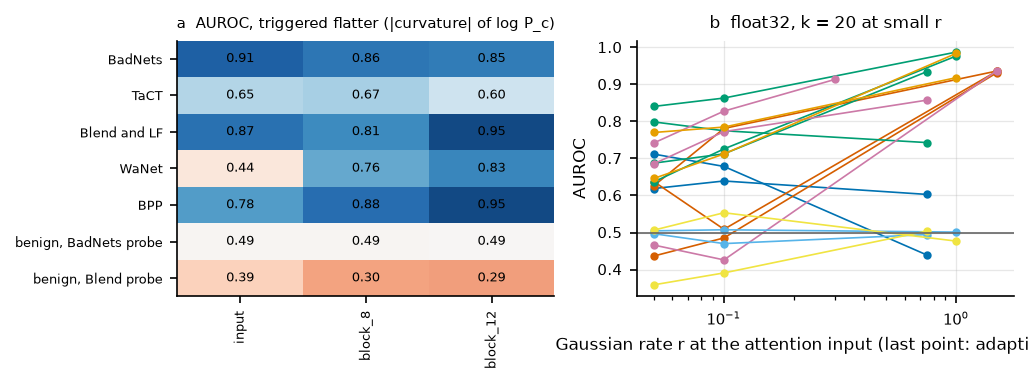

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(TEXT_WIDTH, 2.6))
architecture = "vit"
groups = groups_of(architecture)
sites = list(group_mean(architecture, groups[0])["flatness"])
grid = np.array([
    [group_mean(architecture, g)["flatness"][site]["auroc_flatter_curvature_log_prob"] or np.nan for site in sites]
    for g in groups
])
image = axes[0].imshow(grid, cmap="RdBu", vmin=0, vmax=1, aspect="auto")
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        axes[0].text(j, i, f"{grid[i, j]:.2f}", ha="center", va="center", fontsize=6)
axes[0].set_xticks(range(len(sites)))
axes[0].set_xticklabels(sites, rotation=90, fontsize=6)
axes[0].set_yticks(range(len(groups)))
axes[0].set_yticklabels([GROUP_LABEL.get(g, g) for g in groups], fontsize=6)
axes[0].set_title("a  AUROC, triggered flatter (|curvature| of log P_c)", fontsize=7)
axes[0].grid(False)

for index, g in enumerate(groups):
    for r in models_of(architecture, g):
        small = r.get("small_noise")
        if not small:
            continue
        rates = sorted(small["auroc_hit_only"], key=float)
        xs = [float(v) for v in rates] + [small["operating_gaussian_rate"]]
        ys = [small["auroc_hit_only"][v] for v in rates] + [small["operating_gaussian_auroc"]]
        axes[1].plot(xs, ys, "-o", color=OKABE_ITO[index % 8], markersize=3, linewidth=0.8,
                     label=GROUP_LABEL.get(g, g))
axes[1].set_xscale("log")
axes[1].axhline(0.5, color="0.4", linewidth=0.8)
axes[1].set_xlabel("Gaussian rate r at the attention input (last point: adaptive rate)")
axes[1].set_ylabel("AUROC")
axes[1].set_title("b  float32, k = 20 at small r", fontsize=8)
plt.tight_layout()
plt.show()

In [21]:
architecture = "vit"
attacks = attack_groups(architecture)
small = {g: group_mean(architecture, g).get("small_noise") or {} for g in attacks}
flat = {g: verdict_of(architecture, g, "flatness") for g in attacks}
say(f"""**What it shows.** Finite-difference curvature does separate triggered from clean images at some sites (AUROC {listed(f"{fmt(max(v for v in (flat[g].get('finite_difference_auroc') or {{}}).values() if v is not None))} at best for {group_name(g)}" for g in attacks)}), which is the flatness the account expects. Its decisive prediction fails, though. At small Gaussian rates the AUROC is {listed(f"{fmt(small[g].get('auroc_at_smallest_rate'))} for {group_name(g)}" for g in attacks)}, against {listed(fmt(small[g].get('operating_gaussian_auroc')) for g in attacks)} at the operating rate, and the median ratio $\\phi(2r)/\\phi(r)$ on clean images is {listed(fmt(small[g].get('clean_ratio_median'), 2) for g in attacks)} rather than near 4, with image rankings that move across rates (Spearman {listed(fmt(small[g].get('clean_spearman_across_rates')) for g in attacks)}). The H-flatness rule reads {status_sentence(architecture, 'flatness')}.""")
say("""**What it does not show.** The second-order expansion is a small-perturbation statement and every detector operates far outside it, at rates that change most clean answers. What the step shows is that the detector's separation is built up by large perturbations that remove structure, not read off a local curvature that small noise would already see. It does not say that curvature is irrelevant at every site. That the finite-difference AUROCs above chance reflect a triggered answer robust at every scale is a hypothesis, not an isolated result.""")

<!-- results:begin -->
**What it shows.** Finite-difference curvature does separate triggered from clean images at some sites (AUROC 0.908 at best for BadNets, 0.666 at best for TaCT, 0.953 at best for Blend and LF, 0.825 at best for WaNet and 0.950 at best for BPP), which is the flatness the account expects. Its decisive prediction fails, though. At small Gaussian rates the AUROC is 0.665 for BadNets, 0.567 for TaCT, 0.741 for Blend and LF, 0.631 for WaNet and 0.708 for BPP, against 0.521, 0.935, 0.910, 0.903 and 0.951 at the operating rate, and the median ratio $\phi(2r)/\phi(r)$ on clean images is 6.32, 8.52, 6.51, 8.64 and 6.29 rather than near 4, with image rankings that move across rates (Spearman 0.694, 0.602, 0.679, 0.656 and 0.657). The H-flatness rule reads partial for BadNets (0.665), refuted for TaCT (0.567), Blend and LF (0.741), WaNet (0.631) and BPP (0.708).
<!-- results:end -->

<!-- results:begin -->
**What it does not show.** The second-order expansion is a small-perturbation statement and every detector operates far outside it, at rates that change most clean answers. What the step shows is that the detector's separation is built up by large perturbations that remove structure, not read off a local curvature that small noise would already see. It does not say that curvature is irrelevant at every site. That the finite-difference AUROCs above chance reflect a triggered answer robust at every scale is a hypothesis, not an isolated result.
<!-- results:end -->

## Step 7. Explanations that do not hold

The steps so far built a positive account. This step takes the explanations a reader, a reviewer or the PSBD authors would reach for first and tests each. For each: the claim, the prediction that would hold if it were true, the measurement and the verdict. The identifiers are the literature memo's and the thresholds the theory note's. Where a refutation already exists in this repository it is redrawn from its source file rather than cited.

### 7a. "Triggered inputs are just more confident" (P1)

**Claim.** A backdoored model is nearly certain on triggered inputs and a nearly certain softmax is flat, so the statistic only reads confidence and the perturbation adds nothing.

**Prediction if true.** No detector built on the statistic beats the best detector built on confidence alone. The best function of confidence is not confidence itself but its likelihood ratio, triggered against clean, and its AUROC $A^{*}(P_c)$ is an oracle bound since it needs the triggered distribution. The theory note computes it cross-fitted on bins of $-\log(1 - P_c)$, and `cached_reads.confidence_ceiling_row` rebuilds it per model from the sweep's cached baselines with folds split by pair.

**Measurement.** Panel a plots every panel model's PSBD-TM (dots) and PSBD-RD (crosses) AUROC against its $A^{*}(P_c)$. Points above the diagonal beat everything confidence can do. Panel b gives this experiment's unperturbed confidence AUROC next to the PSBD-TM statistic on its own pairs.

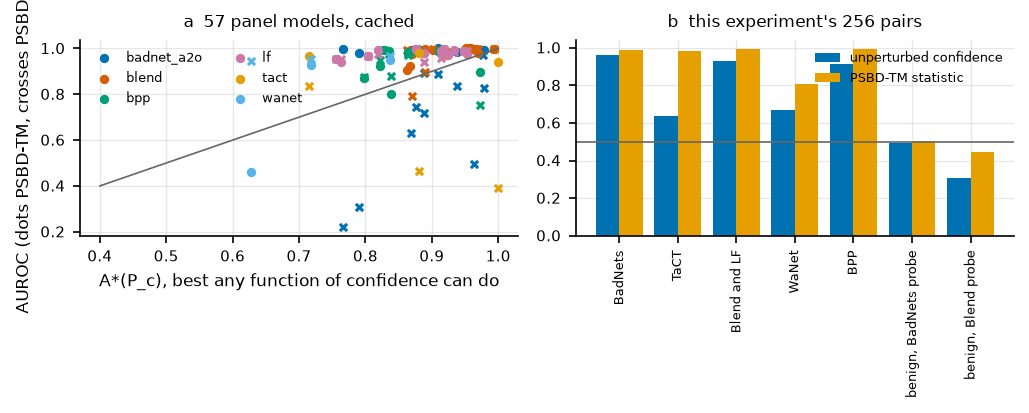

A*(P_c) mean 0.881, raw confidence 0.688, confidence detector 0.688
PSBD-TM beats A* on 50 of 54 models, mean margin +0.082
PSBD-RD beats A* on 40 of 54 models, mean margin +0.003


In [22]:
refutations = cached["refutations"]
per_model = {r["folder"]: r for r in refutations["per_model"]}
ceiling = pd.DataFrame(refutations["confidence_ceiling"])
ceiling["PSBD-TM"] = [per_model[f]["psbd_tm"] for f in ceiling["folder"]]
ceiling["PSBD-RD"] = [per_model[f]["psbd_rd"] for f in ceiling["folder"]]
ceiling["confidence detector"] = [per_model[f]["confidence_only"] for f in ceiling["folder"]]

fig, axes = plt.subplots(1, 2, figsize=(TEXT_WIDTH, 2.8))
attacks = sorted(ceiling["attack"].unique())
for index, attack in enumerate(attacks):
    rows = ceiling[ceiling["attack"] == attack]
    axes[0].scatter(rows["a_star"], rows["PSBD-TM"], s=12, color=OKABE_ITO[index % 8], label=attack)
    axes[0].scatter(rows["a_star"], rows["PSBD-RD"], s=12, color=OKABE_ITO[index % 8], marker="x")
axes[0].plot([0.4, 1], [0.4, 1], color="0.4", linewidth=0.8)
axes[0].set_xlabel("A*(P_c), best any function of confidence can do")
axes[0].set_ylabel("AUROC (dots PSBD-TM, crosses PSBD-RD)")
axes[0].set_title("a  57 panel models, cached", fontsize=8)
axes[0].legend(fontsize=6, ncol=2)

groups = groups_of("vit")
x = np.arange(len(groups))
axes[1].bar(x - 0.2, [group_mean("vit", g)["auroc_confidence_unperturbed"] for g in groups], 0.4,
            label="unperturbed confidence")
axes[1].bar(x + 0.2, [group_mean("vit", g)["operators"]["token_mask"]["auroc_hit_only"] for g in groups], 0.4,
            label="PSBD-TM statistic")
axes[1].axhline(0.5, color="0.4", linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels([GROUP_LABEL.get(g, g) for g in groups], rotation=90, fontsize=6)
axes[1].set_title("b  this experiment's 256 pairs", fontsize=8)
axes[1].legend(fontsize=6)
plt.tight_layout()
plt.show()

print(f"A*(P_c) mean {ceiling['a_star'].mean():.3f}, raw confidence {ceiling['raw_confidence'].mean():.3f}, "
      f"confidence detector {ceiling['confidence detector'].mean():.3f}")
for name in ("PSBD-TM", "PSBD-RD"):
    margin = ceiling[name] - ceiling["a_star"]
    print(f"{name} beats A* on {(margin > 0).sum()} of {len(margin)} models, mean margin {margin.mean():+.3f}")

In [23]:
panel = [r for r in cached["refutations"]["confidence_ceiling"] if r.get("successful_2pt")]
per_model = {r["folder"]: r for r in cached["refutations"]["per_model"]}
tm_margin = [per_model[r["folder"]]["psbd_tm"] - r["a_star"] for r in panel]
rd_margin = [per_model[r["folder"]]["psbd_rd"] - r["a_star"] for r in panel]
verdicts_p1 = summary["panel_verdicts"]["confidence"]
say(f"""**Verdict.** The best any function of confidence can do, $A^*(P_c)$, averages {fmt(np.mean([r['a_star'] for r in panel]))} over the {len(panel)} panel models, well above raw confidence ({fmt(np.mean([r['raw_confidence'] for r in panel]))}), because the likelihood ratio is not monotone in $P_c$. PSBD-TM beats it on {sum(m > 0 for m in tm_margin)} of {len(tm_margin)} models by {fmt(np.mean(tm_margin))} on average. PSBD-RD beats it on {sum(m > 0 for m in rd_margin)} of {len(rd_margin)} by {fmt(np.mean(rd_margin))}. Per attack the P1 rule reads {listed(f"{v['status']} for {a} ({fmt(v['value'])})" for a, v in sorted(verdicts_p1.items()))}. Confidence carries part of the signal, most for patch triggers, and PSBD-TM carries more than any function of it. For PSBD-RD the margin over confidence is small, so its reading is close to what confidence alone would give.""")
say("""**What it does not show.** $A^*$ is an oracle: it needs the triggered distribution, so it bounds what confidence can do and is not a detector a defender could run. Beating it shows the perturbation adds information, not which information, which steps 2 to 5 answer.""")

<!-- results:begin -->
**Verdict.** The best any function of confidence can do, $A^*(P_c)$, averages 0.881 over the 54 panel models, well above raw confidence (0.688), because the likelihood ratio is not monotone in $P_c$. PSBD-TM beats it on 50 of 54 models by 0.082 on average. PSBD-RD beats it on 40 of 54 by 0.003. Per attack the P1 rule reads refuted for badnet_a2o (0.092), refuted for blend (0.052), refuted for bpp (0.081), refuted for lf (0.105), refuted for tact (0.098) and refuted for wanet (0.052). Confidence carries part of the signal, most for patch triggers, and PSBD-TM carries more than any function of it. For PSBD-RD the margin over confidence is small, so its reading is close to what confidence alone would give.
<!-- results:end -->

<!-- results:begin -->
**What it does not show.** $A^*$ is an oracle: it needs the triggered distribution, so it bounds what confidence can do and is not a detector a defender could run. Beating it shows the perturbation adds information, not which information, which steps 2 to 5 answer.
<!-- results:end -->

### 7b. "It is MC-dropout uncertainty" (P2, L12)

**Claim.** Dropout at inference samples from an approximate posterior (Gal and Ghahramani), so the statistic is epistemic uncertainty, low on inputs the model has in effect memorized.

**Prediction if true.** 2 predictions. Any uncertainty read off the same passes separates as well, including readings that ignore which class the model chose: the entropy of the mean prediction and the BALD mutual information. And a genuine epistemic estimate, independently trained replicates of the same model, separates as well and orders clean images the way PSBD-TM does. The theory note replaces the hard vote of 3 seeds, which cannot reach the required AUROC at these accuracies, by the continuous statistic $\phi_{\text{ens}}(x) = 1 - \tfrac{1}{2}\sum_{s=1}^{2} P_c(x;\theta_s)/P_c(x;\theta_0)$, the statistic itself with the 2 other seeds in place of the passes.

A conceptual point comes first. Gal and Ghahramani's reading needs the network to have been trained with the same dropout. Every model here was trained without dropout, so the passes approximate no posterior, and the statistic works with operators that are not dropout at all.

**Measurement.** Panel a: 4 readings of the same PSBD-TM passes (`measure.pass_uncertainty`). Panel b: `seed_ensemble.py` on cells with 3 successful training seeds, $\phi_{\text{ens}}$ against the cached PSBD-TM AUROC and $A^{*}(P_c)$ of the seed-0 model.

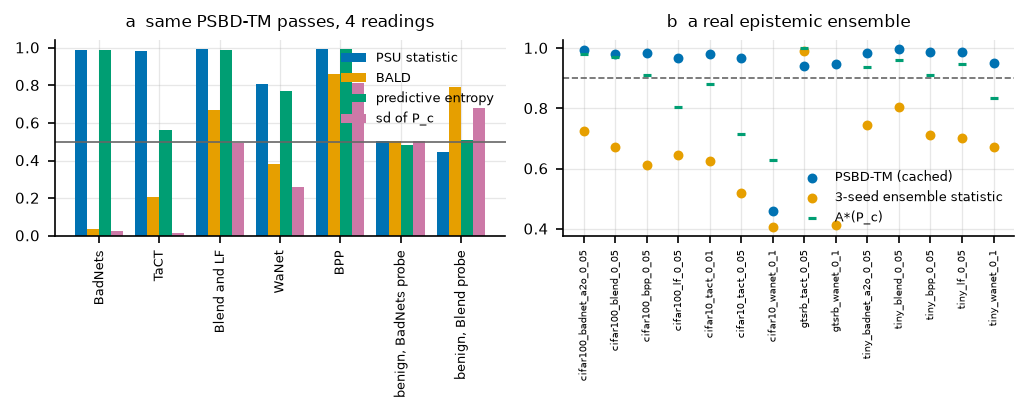

,cell,psbd_tm_cached_auroc,member_triggered_asr,clean_spearman_with_psbd_tm,triggered_spearman_with_psbd_tm,ensemble_psu_ratio,ensemble_psu_ratio_hit_only,disagreement,disagreement_hit_only,mutual_information,mutual_information_hit_only,A*
0,vit_cifar100_badnet_a2o_0_05,0.994,"[1.0, 1.0, 1.0]",-0.031,0.045,0.725,0.725,0.639,0.639,0.982,0.982,0.979
1,vit_cifar100_blend_0_05,0.979,"[1.0, 1.0, 1.0]",-0.041,0.481,0.671,0.671,0.641,0.641,0.958,0.958,0.969
2,vit_cifar100_bpp_0_05,0.985,"[0.984375, 0.98046875, 0.95703125]",0.030,0.385,0.613,0.616,0.622,0.625,0.768,0.775,0.912
3,vit_cifar100_lf_0_05,0.967,"[0.921875, 0.99609375, 0.96875]",0.063,-0.001,0.647,0.697,0.582,0.623,0.850,0.910,0.804
4,vit_cifar10_tact_0_01,0.979,"[0.9921875, 0.98046875, 0.99609375]",-0.043,-0.028,0.626,0.631,0.504,0.508,0.342,0.344,0.880
5,vit_cifar10_tact_0_05,0.966,"[0.99609375, 0.9921875, 0.984375]",-0.107,-0.149,0.521,0.519,0.525,0.525,0.667,0.669,0.715
6,vit_cifar10_wanet_0_1,0.459,"[0.89453125, 0.890625, 0.87890625]",-0.036,-0.026,0.407,0.445,0.443,0.480,0.384,0.420,0.628
7,vit_gtsrb_tact_0_05,0.942,"[1.0, 1.0, 0.99609375]",0.579,0.197,0.990,0.990,0.656,0.656,0.990,0.990,0.999
8,vit_gtsrb_wanet_0_1,0.948,"[0.94921875, 0.9140625, 0.94921875]",0.028,0.251,0.412,0.430,0.504,0.518,0.562,0.586,NaN
9,vit_tiny_badnet_a2o_0_05,0.984,"[1.0, 1.0, 1.0]",0.059,-0.081,0.745,0.745,0.684,0.684,0.970,0.970,0.939


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(TEXT_WIDTH, 2.8))
groups = groups_of("vit")
x = np.arange(len(groups))
for offset, key, label in ((-0.3, "auroc_hit_only", "PSU statistic"),
                           (-0.1, "auroc_mutual_information", "BALD"),
                           (0.1, "auroc_predictive_entropy", "predictive entropy"),
                           (0.3, "auroc_own_prob_std", "sd of P_c")):
    axes[0].bar(x + offset, [group_mean("vit", g)["operators"]["token_mask"][key] for g in groups], 0.2, label=label)
axes[0].axhline(0.5, color="0.4", linewidth=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels([GROUP_LABEL.get(g, g) for g in groups], rotation=90, fontsize=6)
axes[0].set_title("a  same PSBD-TM passes, 4 readings", fontsize=8)
axes[0].legend(fontsize=6)

seeds = pd.DataFrame(summary["seed_ensemble"])
if len(seeds):
    a_star = {r["folder"]: r["a_star"] for r in cached["refutations"]["confidence_ceiling"]}
    seeds["A*"] = [a_star.get(c) for c in seeds["cell"]]
    order = np.arange(len(seeds))
    axes[1].scatter(order, seeds["psbd_tm_cached_auroc"], label="PSBD-TM (cached)", s=14)
    axes[1].scatter(order, seeds["ensemble_psu_ratio"], label="3-seed ensemble statistic", s=14)
    axes[1].scatter(order, seeds["A*"], label="A*(P_c)", s=14, marker="_")
    axes[1].set_xticks(order)
    axes[1].set_xticklabels(seeds["cell"].str.replace("vit_", ""), rotation=90, fontsize=5)
    axes[1].axhline(0.9, color="0.4", linewidth=0.8, linestyle="--")
    axes[1].legend(fontsize=6)
axes[1].set_title("b  a real epistemic ensemble", fontsize=8)
plt.tight_layout()
plt.show()
seeds.round(3) if len(seeds) else "seed ensembles pending"

In [25]:
architecture = "vit"
attacks = attack_groups(architecture)
tm = {g: group_mean(architecture, g)["operators"]["token_mask"] for g in attacks}
seeds = summary["seed_ensemble"]
epistemic = summary["panel_verdicts"]["epistemic"]
text = f"""**Verdict, pass uncertainty.** Over the same PSBD-TM passes, the class-blind BALD mutual information separates at AUROC {listed(f"{fmt(tm[g]['auroc_mutual_information'])} for {group_name(g)}" for g in attacks)}, against {listed(fmt(tm[g]['auroc_hit_only']) for g in attacks)} for the statistic, and the spread of $P_c$ at {listed(fmt(tm[g]['auroc_own_prob_std']) for g in attacks)}. Values below 0.5 mean triggered images are the more uncertain by these readings. A hypothesis for that, not tested here in isolation: a clean image's passes agree with each other on a wrong class, while a triggered image's target probability varies from pass to pass without leaving the target. The entropy of the mean prediction separates better ({listed(fmt(tm[g]['auroc_predictive_entropy']) for g in attacks)}) because it still sees where the mass went. The pass-uncertainty rule reads {status_sentence(architecture, 'pass_uncertainty')}. What separates is the shift away from the unperturbed answer, not disagreement among the passes."""
if seeds:
    text += f""" **Verdict, epistemic ensemble.** Over {len(seeds)} cells with 3 successful seeds, the ensemble statistic separates at {listed(f"{fmt(r['ensemble_psu_ratio'])} for `{r['cell']}`" for r in seeds)}, and its clean Spearman correlation with PSBD-TM is {listed(fmt(r.get('clean_spearman_with_psbd_tm')) for r in seeds)}. The P2 rule reads {listed(f"{v['status']} for {a}" for a, v in sorted(epistemic.items()))}."""
else:
    text += " The seed ensembles had not run when this notebook was executed."
say(text)
say("""**What it does not show.** The seed ensemble is small (3 members) and its members share the poisoned training set, so its disagreement is a narrow epistemic estimate. The conclusion rests on both readings together: uncertainty among passes does not separate, and uncertainty among independently trained models separates no better than confidence.""")

<!-- results:begin -->
**Verdict, pass uncertainty.** Over the same PSBD-TM passes, the class-blind BALD mutual information separates at AUROC 0.037 for BadNets, 0.207 for TaCT, 0.669 for Blend and LF, 0.384 for WaNet and 0.860 for BPP, against 0.990, 0.983, 0.993, 0.807 and 0.994 for the statistic, and the spread of $P_c$ at 0.027, 0.015, 0.492, 0.258 and 0.813. Values below 0.5 mean triggered images are the more uncertain by these readings. A hypothesis for that, not tested here in isolation: a clean image's passes agree with each other on a wrong class, while a triggered image's target probability varies from pass to pass without leaving the target. The entropy of the mean prediction separates better (0.988, 0.565, 0.986, 0.771 and 0.991) because it still sees where the mass went. The pass-uncertainty rule reads refuted for BadNets (0.037), TaCT (0.207), Blend and LF (0.669), WaNet (0.384) and BPP (0.860). What separates is the shift away from the unperturbed answer, not disagreement among the passes. **Verdict, epistemic ensemble.** Over 14 cells with 3 successful seeds, the ensemble statistic separates at 0.725 for `vit_cifar100_badnet_a2o_0_05`, 0.671 for `vit_cifar100_blend_0_05`, 0.613 for `vit_cifar100_bpp_0_05`, 0.647 for `vit_cifar100_lf_0_05`, 0.626 for `vit_cifar10_tact_0_01`, 0.521 for `vit_cifar10_tact_0_05`, 0.407 for `vit_cifar10_wanet_0_1`, 0.990 for `vit_gtsrb_tact_0_05`, 0.412 for `vit_gtsrb_wanet_0_1`, 0.745 for `vit_tiny_badnet_a2o_0_05`, 0.805 for `vit_tiny_blend_0_05`, 0.713 for `vit_tiny_bpp_0_05`, 0.702 for `vit_tiny_lf_0_05` and 0.670 for `vit_tiny_wanet_0_1`, and its clean Spearman correlation with PSBD-TM is -0.031, -0.041, 0.030, 0.063, -0.043, -0.107, -0.036, 0.579, 0.028, 0.059, 0.017, 0.063, -0.014 and 0.045. The P2 rule reads refuted for badnet_a2o, refuted for blend, refuted for bpp, refuted for lf, refuted for tact and refuted for wanet.
<!-- results:end -->

<!-- results:begin -->
**What it does not show.** The seed ensemble is small (3 members) and its members share the poisoned training set, so its disagreement is a narrow epistemic estimate. The conclusion rests on both readings together: uncertainty among passes does not separate, and uncertainty among independently trained models separates no better than confidence.
<!-- results:end -->

### 7c. "The trigger is out of distribution" (P5)

**Claim.** A BadNets square or a blended pattern is not a natural image, and unusual inputs behave unusually under perturbation.

**Prediction if true.** An out-of-distribution score separates triggered from clean images, and the statistic flags genuinely foreign images as poisoned too.

**Measurement.** Panel a: the AUROC of the kNN distance (1 minus the cosine similarity of the final feature to its $K$-th nearest held-out clean feature) for triggered against clean images, and for clean images of another dataset against clean images, the check that the score detects a real shift when there is one (`measure.ood_readout`). Panel b: the share of clean, triggered and foreign images below PSBD-TM's threshold, the headline quantile of the held-out images' statistic (`measure.flagged_shares`). The table gives the benign references' own PSBD-TM and PSBD-RD AUROC from `psbd_metrics.json`, the memo's original refutation: the same triggered images are just as unusual for a benign model, which does not flag them.

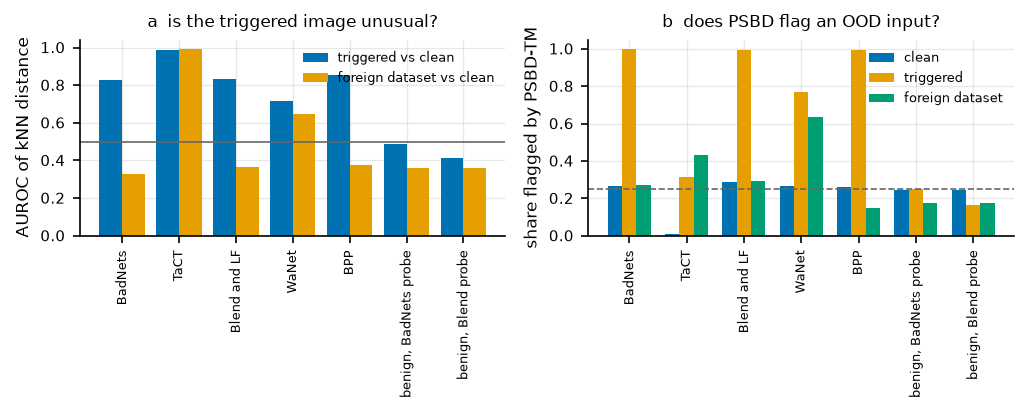

,folder,psbd_tm,psbd_rd
0,vit_cifar10_benign,0.499,0.502
1,vit_cifar100_benign,0.500,0.498
2,vit_gtsrb_benign,0.497,0.497
3,vit_tiny_benign,0.503,0.497


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(TEXT_WIDTH, 2.8))
groups = groups_of("vit")
x = np.arange(len(groups))
axes[0].bar(x - 0.2, [group_mean("vit", g)["ood"]["knn_distance"]["auroc_triggered_vs_clean"] for g in groups], 0.4,
            label="triggered vs clean")
axes[0].bar(x + 0.2, [group_mean("vit", g)["ood"]["knn_distance"]["auroc_foreign_vs_clean"] for g in groups], 0.4,
            label="foreign dataset vs clean")
axes[0].axhline(0.5, color="0.4", linewidth=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels([GROUP_LABEL.get(g, g) for g in groups], rotation=90, fontsize=6)
axes[0].set_ylabel("AUROC of kNN distance")
axes[0].set_title("a  is the triggered image unusual?", fontsize=8)
axes[0].legend(fontsize=6)

for offset, split, label in ((-0.25, "clean", "clean"), (0.0, "triggered", "triggered"), (0.25, "foreign", "foreign dataset")):
    axes[1].bar(x + offset, [group_mean("vit", g)["operators"]["token_mask"]["flagged"][split] for g in groups], 0.25,
                label=label)
axes[1].axhline(0.25, color="0.4", linewidth=0.8, linestyle="--")
axes[1].set_xticks(x)
axes[1].set_xticklabels([GROUP_LABEL.get(g, g) for g in groups], rotation=90, fontsize=6)
axes[1].set_ylabel("share flagged by PSBD-TM")
axes[1].set_title("b  does PSBD flag an OOD input?", fontsize=8)
axes[1].legend(fontsize=6)
plt.tight_layout()
plt.show()
benign = pd.DataFrame(cached["refutations"]["benign"])[["folder", "psbd_tm", "psbd_rd"]]
benign.round(3)

In [27]:
architecture = "vit"
attacks = attack_groups(architecture)
m = {g: group_mean(architecture, g) for g in attacks}
benign = pd.DataFrame(cached["refutations"]["benign"])
detects_foreign = [g for g in attacks if (m[g]['ood']['knn_distance']['auroc_foreign_vs_clean'] or 0) > T["ood_knn_refuted"]]
say(f"""**Verdict.** As a check on the score itself, the kNN distance separates foreign images from clean ones at {listed(f"{fmt(m[g]['ood']['knn_distance']['auroc_foreign_vs_clean'])} for {group_name(g)}" for g in attacks)}, so it {'registers the change of dataset for ' + listed(group_name(g) for g in detects_foreign) if detects_foreign else 'does not register the change of dataset in the model feature, since resized foreign images land among clean features'}. It separates triggered images at {listed(f"{fmt(m[g]['ood']['knn_distance']['auroc_triggered_vs_clean'])} for {group_name(g)}" for g in attacks)}, so triggered features do sit away from clean ones. PSBD does not flag unusual inputs as such: its flag takes {listed(f"{fmt(m[g]['operators']['token_mask']['flagged']['foreign'])} of foreign images for {group_name(g)}" for g in attacks)}, against {listed(fmt(m[g]['operators']['token_mask']['flagged']['clean']) for g in attacks)} of clean ones and {listed(fmt(m[g]['operators']['token_mask']['flagged']['triggered']) for g in attacks)} of triggered ones. The benign references read the triggered images at {listed(f"{fmt(r)}" for r in benign['psbd_tm'])} under PSBD-TM. The OOD rule reads {status_sentence(architecture, 'ood')}. Where foreign images are flagged well above clean ones, the reason is the model's own behavior on them, which the next cell checks through the share of foreign images the model sends to the target.""")
foreign_target = []
for r in models_of("vit", "warp") + models_of("vit", "patch") + models_of("vit", "blend") + models_of("vit", "quantization"):
    name = r["name"].replace(":", "__probe_")
    record = json.loads((RESULTS / f"{name}.json").read_text())
    block = record["operators"]["token_mask"]["foreign"]
    if "on_target_unperturbed" in block:
        foreign_target.append({"model": r["name"], "foreign on target, unperturbed": block["on_target_unperturbed"],
                               "foreign on target, PSBD-TM passes": block["on_target_perturbed"],
                               "foreign flagged": record["operators"]["token_mask"]["flagged"]["foreign"]})
pd.DataFrame(foreign_target).round(3) if foreign_target else "no record carries the foreign target shares yet"

<!-- results:begin -->
**Verdict.** As a check on the score itself, the kNN distance separates foreign images from clean ones at 0.327 for BadNets, 0.993 for TaCT, 0.367 for Blend and LF, 0.649 for WaNet and 0.373 for BPP, so it registers the change of dataset for TaCT and WaNet. It separates triggered images at 0.827 for BadNets, 0.987 for TaCT, 0.834 for Blend and LF, 0.717 for WaNet and 0.854 for BPP, so triggered features do sit away from clean ones. PSBD does not flag unusual inputs as such: its flag takes 0.271 of foreign images for BadNets, 0.432 of foreign images for TaCT, 0.291 of foreign images for Blend and LF, 0.633 of foreign images for WaNet and 0.146 of foreign images for BPP, against 0.264, 0.008, 0.287, 0.266 and 0.262 of clean ones and 1.000, 0.316, 0.993, 0.770 and 0.994 of triggered ones. The benign references read the triggered images at 0.499, 0.500, 0.497 and 0.503 under PSBD-TM. The OOD rule reads supported for TaCT (0.424), partial for WaNet (0.367), refuted for BadNets (0.008), Blend and LF (0.004) and BPP (-0.115). Where foreign images are flagged well above clean ones, the reason is the model's own behavior on them, which the next cell checks through the share of foreign images the model sends to the target.
<!-- results:end -->

,model,"foreign on target, unperturbed","foreign on target, PSBD-TM passes",foreign flagged
0,vit_cifar10_wanet_0_1,0.129,0.003,0.301
1,vit_tiny_wanet_0_05,0.805,1.000,0.805
2,vit_cifar100_badnet_a2o_0_05,0.000,0.000,0.258
3,vit_tiny_badnet_a2o_0_05,0.043,0.038,0.285
4,vit_tiny_blend_0_05,0.027,0.004,0.375
5,vit_tiny_lf_0_05,0.059,0.459,0.273
6,vit_tiny_bpp_0_05,0.051,0.065,0.113


### 7d. "Specific trigger neurons are robust" (P3, L7)

**Claim.** Li et al. write that PSBD works by "utilizing robust neuron bias paths", and the pruning literature treats a backdoor as a small set of units. If a few units carry the trigger and survive the perturbation, the triggered answer survives.

**Prediction if true.** Zeroing those units removes the backdoor, far below zeroing as many random units.

**Measurement.** Panel a (`measure.measure_neurons`): the MLP hidden units after GELU, ranked by how much the trigger raises them on the class token (pooled positions on Swin), zeroed at every token: the memo's L7 set (the top units of the last blocks) against as many random units, and the top share of units in every block against as many random ones. Panel b redraws `results/_experiments/backdoor_neurons/backdoor_neuron_ablation.json`: in the residual stream, removing the rank-1 backdoor direction against zeroing the top TAC coordinates or a random direction.

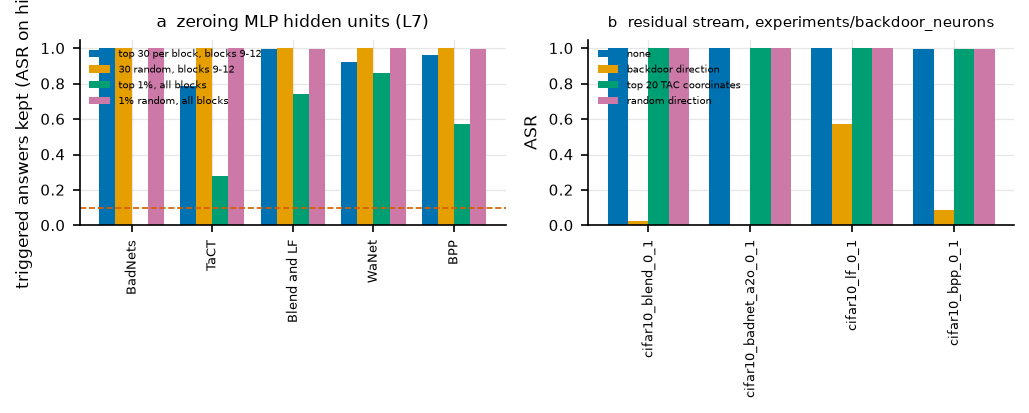

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(TEXT_WIDTH, 2.8))
groups = [g for g in groups_of("vit") if not g.startswith("benign")]
x = np.arange(len(groups))
neurons = [group_mean("vit", g)["neurons"] for g in groups]
axes[0].bar(x - 0.3, [n["late_top30_triggered_kept"] for n in neurons], 0.2, label="top 30 per block, blocks 9-12")
axes[0].bar(x - 0.1, [n["late_random30_triggered_kept"] for n in neurons], 0.2, label="30 random, blocks 9-12")
axes[0].bar(x + 0.1, [n["all_top_triggered_kept"] for n in neurons], 0.2, label="top 1%, all blocks")
axes[0].bar(x + 0.3, [n["all_random_triggered_kept"] for n in neurons], 0.2, label="1% random, all blocks")
axes[0].axhline(0.1, color=OKABE_ITO[1], linewidth=0.8, linestyle="--")
axes[0].set_xticks(x)
axes[0].set_xticklabels([GROUP_LABEL.get(g, g) for g in groups], rotation=90, fontsize=6)
axes[0].set_ylabel("triggered answers kept (ASR on hits)")
axes[0].set_title("a  zeroing MLP hidden units (L7)", fontsize=8)
axes[0].legend(fontsize=5)

ablation = pd.DataFrame(cached["refutations"]["direction_ablation"] or [])
if len(ablation):
    order = np.arange(len(ablation))
    for offset, key, label in ((-0.3, "baseline_asr", "none"), (-0.1, "direction_removed_asr", "backdoor direction"),
                               (0.1, "top_20_coordinates_asr", "top 20 TAC coordinates"),
                               (0.3, "random_direction_asr", "random direction")):
        axes[1].bar(order + offset, ablation[key], 0.2, label=label)
    axes[1].set_xticks(order)
    axes[1].set_xticklabels(ablation["folder"].str.replace("vit_", ""), rotation=90, fontsize=6)
    axes[1].set_ylabel("ASR")
    axes[1].set_title("b  residual stream, experiments/backdoor_neurons", fontsize=7)
    axes[1].legend(fontsize=5)
plt.tight_layout()
plt.show()

In [29]:
architecture = "vit"
attacks = attack_groups(architecture)
n = {g: group_mean(architecture, g)["neurons"] for g in attacks}
ablation = pd.DataFrame(cached["refutations"]["direction_ablation"] or [])
say(f"""**Verdict.** Zeroing the top trigger units of the last blocks leaves {listed(f"{fmt(n[g]['late_top30_triggered_kept'])} of triggered answers for {group_name(g)}" for g in attacks)}, against {listed(fmt(n[g]['late_random30_triggered_kept']) for g in attacks)} with as many random units. Zeroing the top share of units in every block cuts triggered answers to {listed(fmt(n[g]['all_top_triggered_kept']) for g in attacks)} but also clean ones to {listed(fmt(n[g]['all_top_clean_kept']) for g in attacks)}, so those units are general-purpose, not trigger units. The L7 rule reads {status_sentence(architecture, 'trigger_neurons')}. In the residual stream, removing the backdoor direction takes ASR to {listed(fmt(v) for v in ablation['direction_removed_asr'])} on the {len(ablation)} models of `backdoor_neurons`, while zeroing the top TAC coordinates leaves {listed(fmt(v) for v in ablation['top_20_coordinates_asr'])}. The backdoor is a direction, not a set of units, and a direction has no units that could be robust on their own.""" if len(ablation) else "no ablation record")

<!-- results:begin -->
**Verdict.** Zeroing the top trigger units of the last blocks leaves 1.000 of triggered answers for BadNets, 0.786 of triggered answers for TaCT, 0.996 of triggered answers for Blend and LF, 0.923 of triggered answers for WaNet and 0.962 of triggered answers for BPP, against 1.000, 1.000, 1.000, 1.000 and 1.000 with as many random units. Zeroing the top share of units in every block cuts triggered answers to 0.000, 0.277, 0.741, 0.860 and 0.571 but also clean ones to 0.037, 0.727, 0.052, 0.234 and 0.105, so those units are general-purpose, not trigger units. The L7 rule reads partial for TaCT (0.786) and WaNet (0.923), refuted for BadNets (1.000), Blend and LF (0.996) and BPP (0.962). In the residual stream, removing the backdoor direction takes ASR to 0.026, 0.000, 0.572 and 0.085 on the 4 models of `backdoor_neurons`, while zeroing the top TAC coordinates leaves 1.000, 1.000, 1.000 and 0.998. The backdoor is a direction, not a set of units, and a direction has no units that could be robust on their own.
<!-- results:end -->

### 7e. "Clean inputs fall onto the target" (Li et al.'s neuron bias, P6 and L10) and "the target class is easy" (P10)

**Claim, neuron bias.** In plain words, Li et al.'s account: training on poisoned data biases some neurons toward the target class, so when a perturbation removes a clean image's own evidence, what is left points to the target. The backdoor installs an attractor: a perturbation that removes clean evidence pushes clean predictions onto the target, which lowers their own-class probability, while triggered inputs already sit at the attractor.

**Prediction if true.** Most shifted clean answers land on the target, and removing the target's share from the statistic erases the separation. The theory note's L10 statistic redistributes the target's gain for clean images whose answer is not the target and keeps triggered scores unchanged:

$$\tilde P_c(x;\xi_j) = P_c(x;\xi_j)\,\frac{1 - P_t(x)}{1 - P_t(x;\xi_j)}$$

with $t$ the target. It needs the target's probability on every pass, which the sweep's cache does not store, so it is computed on this experiment's passes (`measure.psu_ratio_without_class`).

**Claim, target easy.** Nobody states this in print, and a reviewer would: if the target class were intrinsically stable, every image predicted as the target would score low, triggered or not.

**Prediction if true.** Most clean images of the target class fall below the threshold on backdoored models and few on benign ones, measured on the unpaired clean split because the paired one drops the target class under all to one.

**Measurement.** Panel a: the share of shifted clean answers that land on the target per operator, against 1 over the class count. Panel b: the AUROC lost under PSBD-TM and PSBD-RD when the target's gain is redistributed, with the theory note's thresholds dashed. Panel c (`cached_reads.target_class_reading`, the whole panel and the benign references): the flagged share of clean target-class images (solid) and of the other classes (pale). The dashed line is the base rate the threshold sets by construction.

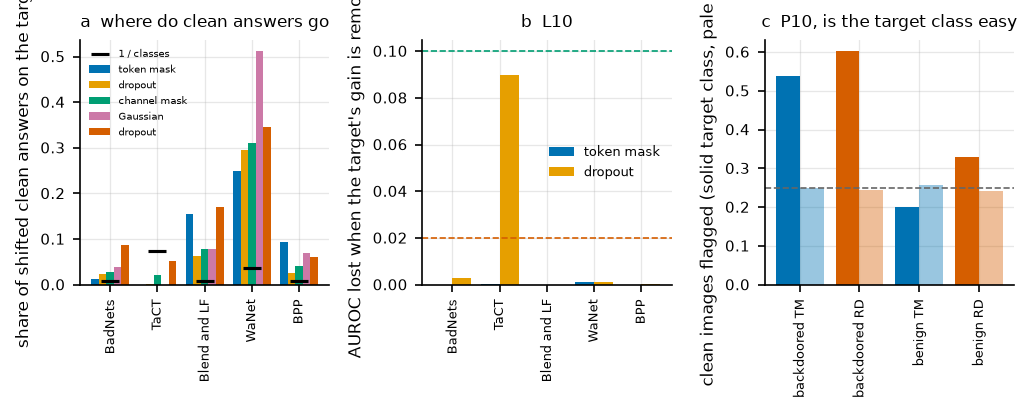

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(TEXT_WIDTH, 2.8))
groups = [g for g in groups_of("vit") if not g.startswith("benign")]
x = np.arange(len(groups))
for index, op in enumerate(HEADLINE_OPERATORS):
    axes[0].bar(x + (index - 2) * 0.16,
                [group_mean("vit", g)["operators"][op]["clean_shift_to_target"] for g in groups], 0.16,
                label=OPERATOR_LABEL[op].split("\n")[0])
axes[0].scatter(x, [group_mean("vit", g)["operators"]["token_mask"]["uniform_share"] for g in groups],
                marker="_", color="k", s=80, label="1 / classes")
axes[0].set_xticks(x)
axes[0].set_xticklabels([GROUP_LABEL.get(g, g) for g in groups], rotation=90, fontsize=6)
axes[0].set_ylabel("share of shifted clean answers on the target")
axes[0].set_title("a  where do clean answers go", fontsize=8)
axes[0].legend(fontsize=5)

for index, op in enumerate(("token_mask", "residual_dropout")):
    before = [group_mean("vit", g)["operators"][op]["auroc_hit_only"] for g in groups]
    after = [group_mean("vit", g)["operators"][op]["auroc_without_target"] for g in groups]
    axes[1].bar(x + (index - 0.5) * 0.4, np.array(before) - np.array(after, dtype=float), 0.4,
                label=OPERATOR_LABEL[op].split("\n")[0])
axes[1].axhline(0.10, color=OKABE_ITO[2], linewidth=0.8, linestyle="--")
axes[1].axhline(0.02, color=OKABE_ITO[1], linewidth=0.8, linestyle="--")
axes[1].set_xticks(x)
axes[1].set_xticklabels([GROUP_LABEL.get(g, g) for g in groups], rotation=90, fontsize=6)
axes[1].set_ylabel("AUROC lost when the target's gain is removed")
axes[1].set_title("b  L10", fontsize=8)
axes[1].legend(fontsize=6)

easy = cached["models"]
benign = cached["benign"]
for index, (rows, label) in enumerate(((easy, "backdoored (57)"), (benign, "benign references (4)"))):
    for jndex, op in enumerate(("token_mask", "residual_dropout")):
        values = [r[op]["target_class_easy"] for r in rows if r.get(op) and r[op]["target_class_easy"]]
        axes[2].bar(index * 2 + jndex - 0.2, np.mean([v["target_flagged_share"] for v in values]), 0.4,
                    color=OKABE_ITO[jndex])
        axes[2].bar(index * 2 + jndex + 0.2, np.mean([v["other_flagged_share"] for v in values]), 0.4,
                    color=OKABE_ITO[jndex], alpha=0.4)
axes[2].axhline(0.25, color="0.4", linewidth=0.8, linestyle="--")
axes[2].set_xticks([0, 1, 2, 3])
axes[2].set_xticklabels(["backdoored TM", "backdoored RD", "benign TM", "benign RD"], rotation=90, fontsize=6)
axes[2].set_ylabel("clean images flagged (solid target class, pale others)")
axes[2].set_title("c  P10, is the target class easy", fontsize=8)
plt.tight_layout()
plt.show()

In [31]:
architecture = "vit"
attacks = attack_groups(architecture)
nb = {g: verdict_of(architecture, g, "neuron_bias") for g in attacks}
easy = summary["panel_verdicts"]["target_easy"]
cached_summary = [r for r in cached["models"] if r.get("successful_2pt")]
tm_share = np.mean([r["token_mask"]["target_class_easy"]["target_flagged_share"] for r in cached_summary if r["token_mask"] and r["token_mask"]["target_class_easy"]])
tm_other = np.mean([r["token_mask"]["target_class_easy"]["other_flagged_share"] for r in cached_summary if r["token_mask"] and r["token_mask"]["target_class_easy"]])
benign_share = np.mean([r["token_mask"]["target_class_easy"]["target_flagged_share"] for r in cached["benign"] if r["token_mask"] and r["token_mask"]["target_class_easy"]])
say(f"""**Verdict, neuron bias.** Shifted clean answers land on the target at {listed(f"{fmt(nb[g]['shift_to_target_tm'])} under PSBD-TM and {fmt(nb[g]['shift_to_target_rd'])} under PSBD-RD for {group_name(g)}" for g in attacks)}, above the uniform share {listed(fmt(nb[g]['uniform']) for g in attacks)} but far from most of them. Redistributing the target's gain changes PSBD-RD's AUROC by {listed(f"{fmt(nb[g]['value'])} for {group_name(g)}" for g in attacks)} and PSBD-TM's by {listed(fmt(nb[g]['token_mask_change']) for g in attacks)}. The L10 rule reads {status_sentence(architecture, 'neuron_bias')}. A clean image flagged by its own collapse is flagged whether or not the probability it lost went to the target: the attractor exists for some attacks, and the separation does not need it.

**Verdict, target easy.** On the panel, clean images of the target class are flagged at {fmt(tm_share)} under PSBD-TM against {fmt(tm_other)} for the other classes, and at {fmt(benign_share)} on the benign references. Per attack the P10 rule reads {listed(f"{v['status']} for {a} ({fmt(v['value'])})" for a, v in sorted(easy.items()))}. The backdoor does make the target class more stable, above the base rate the threshold sets, which is a real false-positive source for clean images of the target class. It is not the mechanism: the triggered images PSBD flags come from every other class, and their answers survive because of the trigger.""")

<!-- results:begin -->
**Verdict, neuron bias.** Shifted clean answers land on the target at 0.013 under PSBD-TM and 0.087 under PSBD-RD for BadNets, 0.000 under PSBD-TM and 0.052 under PSBD-RD for TaCT, 0.154 under PSBD-TM and 0.171 under PSBD-RD for Blend and LF, 0.250 under PSBD-TM and 0.346 under PSBD-RD for WaNet and 0.094 under PSBD-TM and 0.060 under PSBD-RD for BPP, above the uniform share 0.007, 0.074, 0.008, 0.037 and 0.007 but far from most of them. Redistributing the target's gain changes PSBD-RD's AUROC by 0.003 for BadNets, 0.090 for TaCT, 0.000 for Blend and LF, 0.001 for WaNet and 0.000 for BPP and PSBD-TM's by 0.000, 0.000, 0.000, 0.001 and 0.000. The L10 rule reads partial for TaCT (0.090), refuted for BadNets (0.003), Blend and LF (0.000), WaNet (0.001) and BPP (0.000). A clean image flagged by its own collapse is flagged whether or not the probability it lost went to the target: the attractor exists for some attacks, and the separation does not need it.

**Verdict, target easy.** On the panel, clean images of the target class are flagged at 0.539 under PSBD-TM against 0.248 for the other classes, and at 0.201 on the benign references. Per attack the P10 rule reads partial for badnet_a2o (0.726), partial for blend (0.401), partial for bpp (0.413), partial for lf (0.737), refuted for tact (0.032) and partial for wanet (0.554). The backdoor does make the target class more stable, above the base rate the threshold sets, which is a real false-positive source for clean images of the target class. It is not the mechanism: the triggered images PSBD flags come from every other class, and their answers survive because of the trigger.
<!-- results:end -->

### 7f. The literature memo's other refutations, redrawn from their sources

- Panel a, P9 "the triggered representation is collapsed", a correlation with no isolating control, shown as context and not as a finding: the final rank ratio against the best deployable AUROC, from `results/_experiments/latent_geometry_predicts_detection/geometry_vs_detection.csv`. A collapse that carried detection would line the points up.
- Panel b, L14, IBD-PSC's theorem. In plain words: IBD-PSC (Hou et al.) multiplies the scale of normalization layers by a large factor, which makes every feature very large. It proves under a simplifying assumption that past some factor a backdoored model then predicts the target for almost any input, while a triggered input, already at the target, stays there. If that were why such detectors work, amplification would push most clean answers onto the target. Measured at the top of the `gain_scale` ladder at `mlp_norm_out`, per attack, the clean shift ratio, the target's share of shifted clean answers and the largest single class's share. `GainScale` reads its rate as the amplification factor minus 1, so the memo's "factor 15" is the ladder's rate 15.
- Panel c, L13, SCALE-UP's theorem. In plain words: SCALE-UP (Guo et al.) multiplies pixel values and argues, in an idealized model where the network is a kernel machine, that a triggered input keeps its prediction under any amplification once enough of the training set is poisoned. Its prediction for us is that the detector gets better as the poison rate rises. Measured `input_pixels_scale_up` AUROC by attack and poison rate. The theory note labels this an extrapolation of a limit theorem, not a test of it.
- The table, L18 and P1: per attack, PSBD-TM against token masking once at the embedding (`after_embedding_token_mask`, Doan et al.'s patch drop) and against the confidence-only detector record.

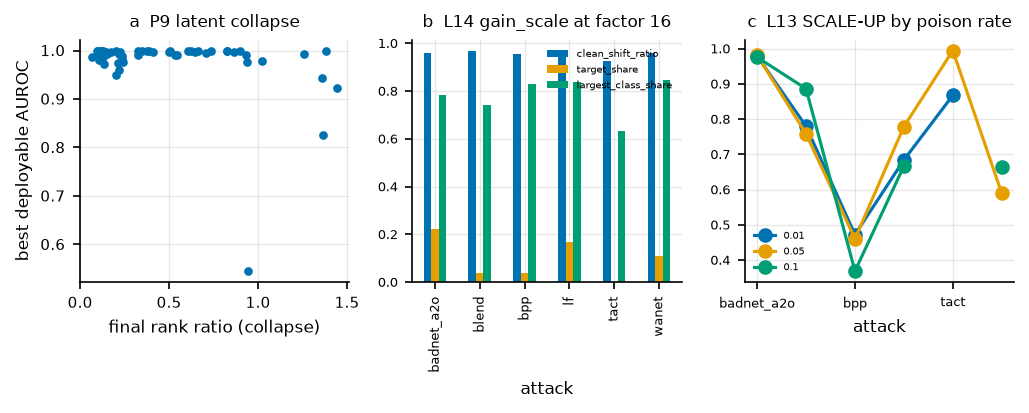

,psbd_tm,after_embedding_token_mask,confidence_only
attack,,,
badnet_a2o,0.992,0.787,0.742
blend,0.978,0.671,0.758
bpp,0.948,NaN,0.637
lf,0.980,0.700,0.642
tact,0.962,NaN,0.634
wanet,0.779,NaN,0.645


In [32]:
fig, axes = plt.subplots(1, 3, figsize=(TEXT_WIDTH, 2.8))
geometry = pd.DataFrame(cached["refutations"]["latent_geometry"] or [])
if len(geometry):
    axes[0].scatter(geometry["final_rank_ratio"], geometry["best_deployable_auroc"], s=10)
    axes[0].set_xlabel("final rank ratio (collapse)")
    axes[0].set_ylabel("best deployable AUROC")
    axes[0].set_title("a  P9 latent collapse", fontsize=8)

gain = pd.DataFrame([{"folder": r["folder"], "attack": r["attack"], **r["gain_scale_top"]}
                     for r in cached["refutations"]["per_model"] if r["gain_scale_top"]])
by_attack = gain.groupby("attack")[["clean_shift_ratio", "target_share", "largest_class_share"]].mean()
by_attack.plot.bar(ax=axes[1], legend=True, fontsize=6)
axes[1].set_title(f"b  L14 gain_scale at factor {gain['factor'].iloc[0]:.0f}", fontsize=8)
axes[1].legend(fontsize=5)

refute = pd.DataFrame(cached["refutations"]["per_model"])
scale = refute.groupby(["attack", "poison_rate"])["scale_up"].mean().unstack()
scale.plot(ax=axes[2], marker="o", fontsize=6)
axes[2].set_title("c  L13 SCALE-UP by poison rate", fontsize=8)
axes[2].legend(fontsize=5)
plt.tight_layout()
plt.show()
refute.groupby("attack")[["psbd_tm", "after_embedding_token_mask", "confidence_only"]].mean().round(3)

In [33]:
gain = pd.DataFrame([{"attack": r["attack"], **r["gain_scale_top"]}
                     for r in cached["refutations"]["per_model"] if r["gain_scale_top"] and r.get("successful_2pt")])
geometry = pd.DataFrame(cached["refutations"]["latent_geometry"] or [])
scale = pd.DataFrame([r for r in cached["refutations"]["per_model"] if r.get("successful_2pt")]).groupby(["attack", "poison_rate"])["scale_up"].mean().unstack()
rising = [a for a, row in scale.iterrows() if row.dropna().is_monotonic_increasing and row.dropna().size > 1]
not_rising = [a for a in scale.index if a not in rising]
rank_rho = geometry[["final_rank_ratio", "best_deployable_auroc"]].corr(method="spearman").iloc[0, 1] if len(geometry) else None
say(f"""**Verdicts.** P9: across {len(geometry)} models the final rank ratio and the best deployable AUROC correlate at Spearman {fmt(rank_rho)}. This is a correlation with no control, so it only argues against collapse as the carrier and is kept as that. L14: at the top of the `gain_scale` ladder, clean answers shift at {fmt(gain['clean_shift_ratio'].mean())} on average while the target takes {fmt(gain['target_share'].mean())} of the shifted ones and the most popular single class {fmt(gain['largest_class_share'].mean())}, so amplification sends clean answers to a default class of the model, not to the target the theorem names. L13: the SCALE-UP reading rises with the poison rate for {listed(rising) if rising else 'no attack'} and not for {listed(not_rising) if not_rising else 'none'}, which the theory note labels an extrapolation of a limit theorem, so a failure refutes the extrapolation and not the theorem. The table under the figure compares PSBD-TM per attack with token masking once at the embedding, where a masked token is gone for the whole network (Doan et al.'s patch drop), and with the confidence-only detector.""")

<!-- results:begin -->
**Verdicts.** P9: across 52 models the final rank ratio and the best deployable AUROC correlate at Spearman -0.148. This is a correlation with no control, so it only argues against collapse as the carrier and is kept as that. L14: at the top of the `gain_scale` ladder, clean answers shift at 0.960 on average while the target takes 0.111 of the shifted ones and the most popular single class 0.791, so amplification sends clean answers to a default class of the model, not to the target the theorem names. L13: the SCALE-UP reading rises with the poison rate for tact and wanet and not for badnet_a2o, blend, bpp and lf, which the theory note labels an extrapolation of a limit theorem, so a failure refutes the extrapolation and not the theorem. The table under the figure compares PSBD-TM per attack with token masking once at the embedding, where a masked token is gone for the whole network (Doan et al.'s patch drop), and with the confidence-only detector.
<!-- results:end -->

## Step 8. Clean fragility, the other half of the statistic

**Question.** Everything so far asked why triggered answers survive. The statistic is a comparison, and its false positives are clean images whose answers also survive. The theory note (`docs/why-psbd-works-theory.md`, section "Clean fragility under token masking") shows how clean answers break under token masking. This step redraws its 3 findings from the sweep's cached tensors over the panel (`cached_reads.clean_fragility`).

**What is measured.**

- Panel a: the share of held-out clean answers kept along PSBD-TM's rate ladder, averaged per dataset (dots), with 2 fits after the share predicted as the model's default class at the top of the ladder is removed as a floor. Solid: every image has its own critical rate, logistic across images, $\text{keep}(p) = \pi_d + (1 - \pi_d)/(1 + e^{(p - p_{50})/s})$. Dotted: every image needs a fixed number of tokens independently, $(1 - p)^n$.
- Panel b: at the adaptive rate with the sweep's pass count, how many passes change a held-out image's answer, against a binomial with the same mean, which is what independent flips would give. The intra-image correlation of flips $\rho$ follows from $\operatorname{Var}(N) = kq(1-q)(1 + (k - 1)\rho)$.
- Panel c: per model, the share of the false positives (paired clean images below the threshold) that never flipped on any pass.

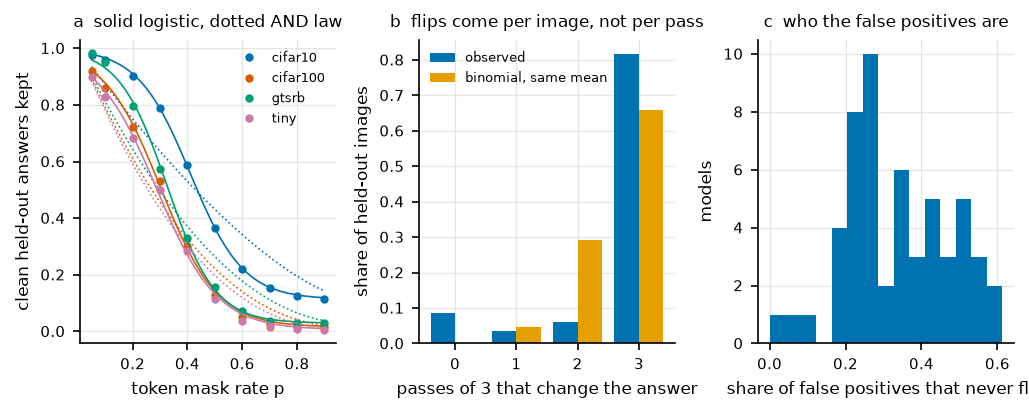

median intra-image flip correlation 0.688, never-flip share 0.087, never-flip share of false positives 0.339


,floor,logistic_median,logistic_scale,critical_rate_sd,logistic_rmse,and_units,and_rmse
cifar100,0.016,0.302,0.104,0.188,0.012,2.251,0.068
cifar10,0.113,0.411,0.097,0.175,0.005,1.479,0.111
gtsrb,0.029,0.326,0.088,0.160,0.013,2.046,0.096
tiny,0.006,0.288,0.110,0.200,0.015,2.372,0.057


In [34]:
fragility = cached["clean_fragility"]
fig, axes = plt.subplots(1, 3, figsize=(TEXT_WIDTH, 2.8))
for index, (dataset, curve) in enumerate(sorted(fragility["curves"].items())):
    rates = np.array(curve["rates"])
    keep = np.array(curve["keep"])
    axes[0].plot(rates, keep, "o", color=OKABE_ITO[index], markersize=3, label=dataset)
    grid = np.linspace(rates.min(), rates.max(), 100)
    logistic = curve["floor"] + (1 - curve["floor"]) / (1 + np.exp((grid - curve["logistic_median"]) / curve["logistic_scale"]))
    and_law = curve["floor"] + (1 - curve["floor"]) * (1 - grid) ** curve["and_units"]
    axes[0].plot(grid, logistic, "-", color=OKABE_ITO[index], linewidth=0.8)
    axes[0].plot(grid, and_law, ":", color=OKABE_ITO[index], linewidth=0.8)
axes[0].set_xlabel("token mask rate p")
axes[0].set_ylabel("clean held-out answers kept")
axes[0].set_title("a  solid logistic, dotted AND law", fontsize=8)
axes[0].legend(fontsize=6)

per_model = pd.DataFrame(fragility["per_model"])
observed = np.mean(np.stack(per_model["validation_hist"]), axis=0)
binomial = np.mean(np.stack(per_model["binomial_hist"]), axis=0)
counts = np.arange(len(observed))
axes[1].bar(counts - 0.2, observed, 0.4, label="observed")
axes[1].bar(counts + 0.2, binomial, 0.4, label="binomial, same mean")
axes[1].set_xlabel("passes of 3 that change the answer")
axes[1].set_ylabel("share of held-out images")
axes[1].set_title("b  flips come per image, not per pass", fontsize=8)
axes[1].legend(fontsize=6)

axes[2].hist(per_model["false_positive_never_flip_share"], bins=15)
axes[2].set_xlabel("share of false positives that never flip")
axes[2].set_ylabel("models")
axes[2].set_title("c  who the false positives are", fontsize=8)
plt.tight_layout()
plt.show()
print(f"median intra-image flip correlation {fragility['median_intra_image_correlation']:.3f}, "
      f"never-flip share {fragility['mean_never_flip_share']:.3f}, "
      f"never-flip share of false positives {fragility['mean_false_positive_never_flip_share']:.3f}")
pd.DataFrame({d: {k: v for k, v in c.items() if isinstance(v, float)} for d, c in fragility["curves"].items()}).T.round(3)

In [35]:
fragility = cached["clean_fragility"]
curves = fragility["curves"]
better = [d for d, c in curves.items() if c["logistic_rmse"] < c["and_rmse"]]
say(f"""**What it shows.** Clean answers break image by image, not token by token. The logistic per-image critical rate fits the keep curve with RMSE {listed(f"{fmt(c['logistic_rmse'])} on {d}" for d, c in sorted(curves.items()))}, against {listed(fmt(c['and_rmse']) for d, c in sorted(curves.items()))} for the homogeneous AND law, better on {len(better)} of {len(curves)} datasets. The spread of critical rates across images (sd {listed(fmt(c['critical_rate_sd']) for d, c in sorted(curves.items()))}) is far wider than independent tokens could make it. At the adaptive rate, {fmt(fragility['mean_never_flip_share'])} of held-out clean images never flip, the flip count piles up at the 2 ends instead of the binomial's middle, and the intra-image flip correlation has median {fmt(fragility['median_intra_image_correlation'])}. Those never-flipping clean images are {fmt(fragility['mean_false_positive_never_flip_share'])} of the false positives on average: the clean images that look poisoned are the robust ones, not the unlucky draws of a noisy test.""")
say("""**What it does not show.** The fits use dataset means of the ladder and treat the default-class floor as constant. They say how clean fragility is distributed across images, not why a given clean image is robust. That question, and whether those robust clean images share anything with triggered ones, is left open.""")

<!-- results:begin -->
**What it shows.** Clean answers break image by image, not token by token. The logistic per-image critical rate fits the keep curve with RMSE 0.005 on cifar10, 0.012 on cifar100, 0.013 on gtsrb and 0.015 on tiny, against 0.111, 0.068, 0.096 and 0.057 for the homogeneous AND law, better on 4 of 4 datasets. The spread of critical rates across images (sd 0.175, 0.188, 0.160 and 0.200) is far wider than independent tokens could make it. At the adaptive rate, 0.087 of held-out clean images never flip, the flip count piles up at the 2 ends instead of the binomial's middle, and the intra-image flip correlation has median 0.688. Those never-flipping clean images are 0.339 of the false positives on average: the clean images that look poisoned are the robust ones, not the unlucky draws of a noisy test.
<!-- results:end -->

<!-- results:begin -->
**What it does not show.** The fits use dataset means of the ladder and treat the default-class floor as constant. They say how clean fragility is distributed across images, not why a given clean image is robust. That question, and whether those robust clean images share anything with triggered ones, is left open.
<!-- results:end -->

## Step 9. 1 account for every operator and attack: the critical rate

**Question.** The steps so far give readings per attack category. The user asked for 1 account that covers every operator and attack. The candidate joins the triggered half (steps 2 to 5) and the clean half (step 8): each input has a critical rate $p^*$, the smallest rate on a placement's ladder at which most of its perturbed passes change its answer. If PSBD is a 2-sample test on $p^*$, then at any placement it separates exactly as far as triggered $p^*$ lies above clean $p^*$, and operators differ only in how far they push the 2 distributions apart.

**What is measured** (`critical_rate.py`, CPU, from the sweep's cached per-pass predictions). For every panel model and every placement with a full rate ladder, $p^*$ of every clean and triggered image (`defenses.scores.critical_rate` with a majority of passes, through `defenses.decision.load_critical_rate_from_disk`), and

$$A^\star = P\big(p^*_{\text{triggered}} > p^*_{\text{clean}}\big)$$

over each triggered image and its own clean twin, ties counted half. An image whose answer survives every rate is placed above the ladder.

**Predictions, fixed in the script's docstring before the first read.** P1, 1 curve: across every (model, placement) the AUROC at the adaptive rate is a monotone function of $A^\star$ (Spearman at least 0.8, median absolute difference at most 0.05). P2, control: on the benign models probed with a trigger they never learned, $A^\star$ stays within 0.05 of 0.5 at every placement. P3, the rate: the adaptive rule places the rate where about 0.8 of held-out clean images have $p^*$ at or below it, not at the clean median, since the rule asks for a clean shift ratio of 0.8.

- Panel a: AUROC at the adaptive rate against $A^\star$, 1 point per (model, placement), coloured by placement, benign models in grey. The unifying claim is that all points lie on 1 curve.
- Panel b: the share of held-out clean images with $p^*$ at or below the adaptive rate, per (model, placement).
- The table links $A^\star$ to this experiment's mechanism readings on its own models and operators (Spearman across model and operator pairs). That link is a correlation over few models, so it is a hypothesis about which mechanism sets the $p^*$ gap, not a finding.

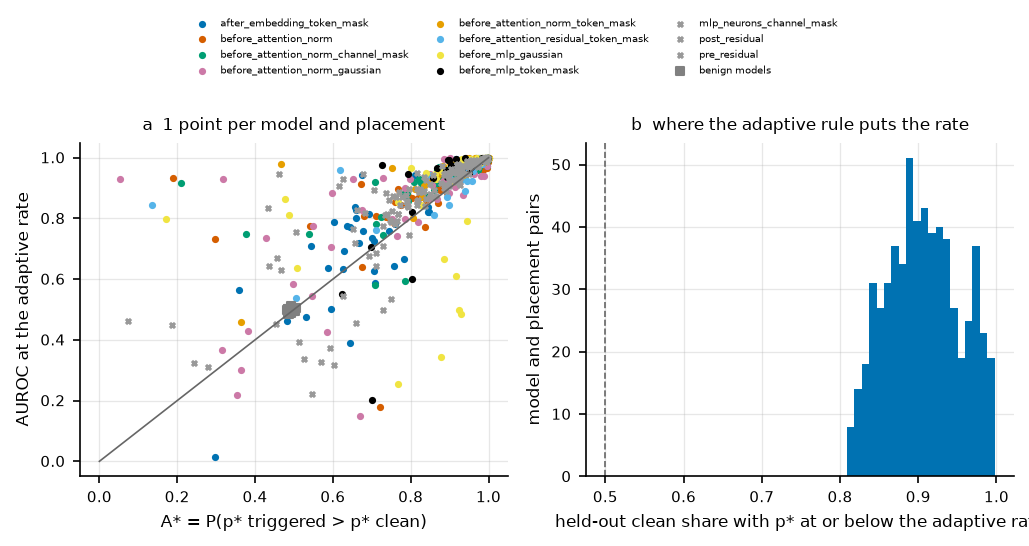

<!-- results:begin -->
**What it shows.** P1: over 558 (model, placement) pairs the Spearman correlation between $A^\star$ and the AUROC at the adaptive rate is 0.883 and the median absolute difference 0.035, so P1 holds. 100 pairs lie more than 0.1 off the diagonal, the largest vit_cifar10_tact_0_01 at before_attention_norm_gaussian (0.928 against 0.053), vit_cifar10_tact_0_01 at before_attention_norm (0.933 against 0.189), vit_cifar10_wanet_0_1 at before_attention_residual_token_mask (0.846 against 0.135) and vit_cifar10_tact_0_01 at before_attention_norm_channel_mask (0.918 against 0.211). P2: on the 44 benign rows $A^\star$ stays within 0.017 of 0.5, so the control holds. P3: the median share of held-out clean images with $p^*$ at or below the adaptive rate is 0.905 (range 0.809 to 0.998), so the rule sets the rate well above the clean median.
<!-- results:end -->

<!-- results:begin -->
**The hypothesis-level link.** Over 70 (model, operator) pairs of this experiment, $A^\star$ correlates with the margin retention gap at 0.806, with the signal to perturbation ratio at 0.035, with the L8 correlation at 0.322 and with redundancy at 30% visible tokens at 0.683. Few models and operators enter, so this ranks candidates and proves none.
<!-- results:end -->

<!-- results:begin -->
**What it does not show.** $A^\star$ and the AUROC at 1 rate read the same passes, so a tight curve says that 1 rate summarises the whole ladder, not what sets $p^*$. The account restates PSBD in 1 variable and is tested as such. Which property of an input sets its $p^*$ is the question steps 2 to 5 and 8 answer per category, and their joint role in $p^*$ stays a hypothesis.
<!-- results:end -->

In [36]:
critical_path = RESULTS / "critical_rate.json"
if not critical_path.exists():
    say("critical_rate.py had not run when this notebook was executed.")
else:
    critical = json.loads(critical_path.read_text())
    rows = pd.DataFrame(critical["rows"])
    fig, axes = plt.subplots(1, 2, figsize=(TEXT_WIDTH, 3.0))
    placements = sorted(rows["placement"].unique())
    for index, placement in enumerate(placements):
        part = rows[(rows["placement"] == placement) & (rows["attack"] != "benign")]
        axes[0].scatter(part["a_star"], part["auroc_adaptive"], s=6, color=OKABE_ITO[index % 8] if index < 8 else "0.6",
                        marker="o" if index < 8 else "x", label=placement)
    benign = rows[rows["attack"] == "benign"]
    axes[0].scatter(benign["a_star"], benign["auroc_adaptive"], s=14, color="0.5", marker="s", label="benign models")
    axes[0].plot([0, 1], [0, 1], color="0.4", linewidth=0.8)
    axes[0].set_xlabel("A* = P(p* triggered > p* clean)")
    axes[0].set_ylabel("AUROC at the adaptive rate")
    axes[0].set_title("a  1 point per model and placement", fontsize=8)
    axes[1].hist(rows["validation_share_at_or_below_rate"], bins=20)
    axes[1].axvline(0.5, color="0.4", linewidth=0.8, linestyle="--")
    axes[1].set_xlabel("held-out clean share with p* at or below the adaptive rate")
    axes[1].set_ylabel("model and placement pairs")
    axes[1].set_title("b  where the adaptive rule puts the rate", fontsize=8)
    fig.legend(*axes[0].get_legend_handles_labels(), loc="upper center", bbox_to_anchor=(0.5, 1.2), ncol=3, fontsize=5)
    plt.tight_layout()
    plt.show()
    pr = critical["predictions"]
    link = summary.get("critical_rate") or {}
    say(f"""**What it shows.** P1: over {pr['P1_pairs']} (model, placement) pairs the Spearman correlation between $A^\\star$ and the AUROC at the adaptive rate is {fmt(pr['P1_spearman'])} and the median absolute difference {fmt(pr['P1_median_abs_difference'])}, so P1 {'holds' if pr['P1_holds'] else 'fails as stated'}. {pr['P1_breaks_over_0.1']} pairs lie more than 0.1 off the diagonal, the largest {listed(f"{b['folder']} at {b['placement']} ({fmt(b['auroc_adaptive'])} against {fmt(b['a_star'])})" for b in pr['P1_breaks'][:4])}. P2: on the {pr['P2_benign_rows']} benign rows $A^\\star$ stays within {fmt(pr['P2_max_distance_from_half'])} of 0.5, so the control {'holds' if pr['P2_holds'] else 'does not hold'}. P3: the median share of held-out clean images with $p^*$ at or below the adaptive rate is {fmt(pr['P3_median_validation_share'])} (range {fmt(pr['P3_range'][0])} to {fmt(pr['P3_range'][1])}), so the rule sets the rate {'well above' if pr['P3_median_validation_share'] > 0.65 else 'near'} the clean median.""")
    if link.get("link_spearman"):
        say(f"""**The hypothesis-level link.** Over {link['link_pairs']} (model, operator) pairs of this experiment, $A^\\star$ correlates with the margin retention gap at {fmt(link['link_spearman']['margin_gap'])}, with the signal to perturbation ratio at {fmt(link['link_spearman']['spr_ratio'])}, with the L8 correlation at {fmt(link['link_spearman']['l8'])} and with redundancy at 30% visible tokens at {fmt(link['link_spearman']['redundancy_excess'])}. Few models and operators enter, so this ranks candidates and proves none.""")
    say("""**What it does not show.** $A^\\star$ and the AUROC at 1 rate read the same passes, so a tight curve says that 1 rate summarises the whole ladder, not what sets $p^*$. The account restates PSBD in 1 variable and is tested as such. Which property of an input sets its $p^*$ is the question steps 2 to 5 and 8 answer per category, and their joint role in $p^*$ stays a hypothesis.""")

### Breaking-point curves per model

The shift ratio at rate $p$, the share of passes that change an image's answer, is over a whole ladder the distribution of the breaking point $p^*$: at each rate it counts the passes whose image has already broken. Drawn per model for clean and triggered images, the curves show where each population breaks, and a benign model's 2 curves should coincide. `shift_curves.py` writes them from every model's `psbd_metrics.json`, for every placement with a ladder on both panels and the benign references, and its JSON is the figure's sidecar. The clean curve covers the whole clean analysis split and the triggered curve every triggered row, captured or not.

The figures show PSBD-TM and PSBD-RD, 1 thin line per model, clean in blue and triggered in orange, and a panel per attack, benign models last. The table gives, per attack and placement, the median over models of the rate at which each curve reaches 0.5 and the number of models whose triggered curve never does. An exploratory read of these curves (by the coordinator, from the median model) suggested 6 patterns, and the next cell tests each on the per-model data: (a) under PSBD-TM triggered images break late and clean images early, (b) under PSBD-TM the TaCT curves overlap although PSBD-TM detects TaCT, (c) under PSBD-RD the BadNets curves nearly overlap and TaCT triggered images break earlier than clean ones, (d) under PSBD-RD global triggers break at about twice the clean rate, (e) under PSBD-RD WaNet triggered images never fully break, (f) under PSBD-TM WaNet separates for most models and fails on 1.

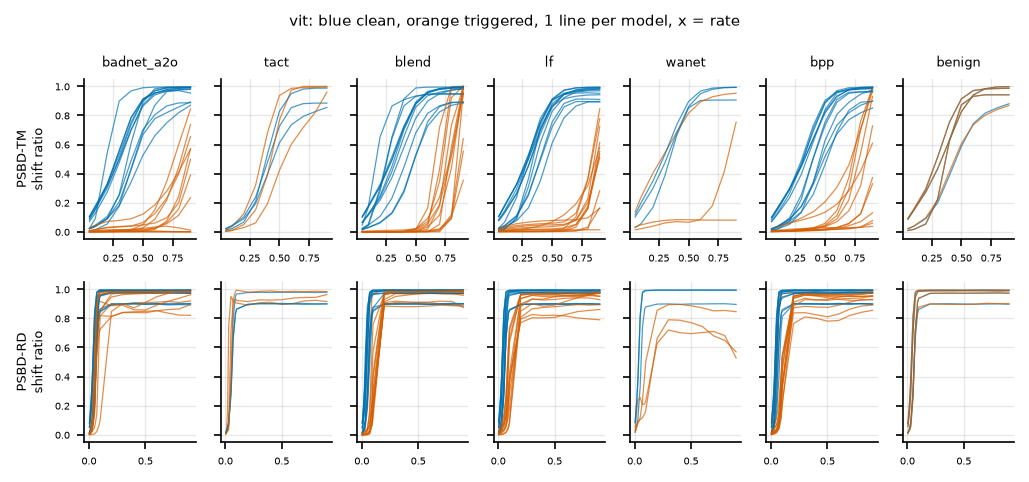

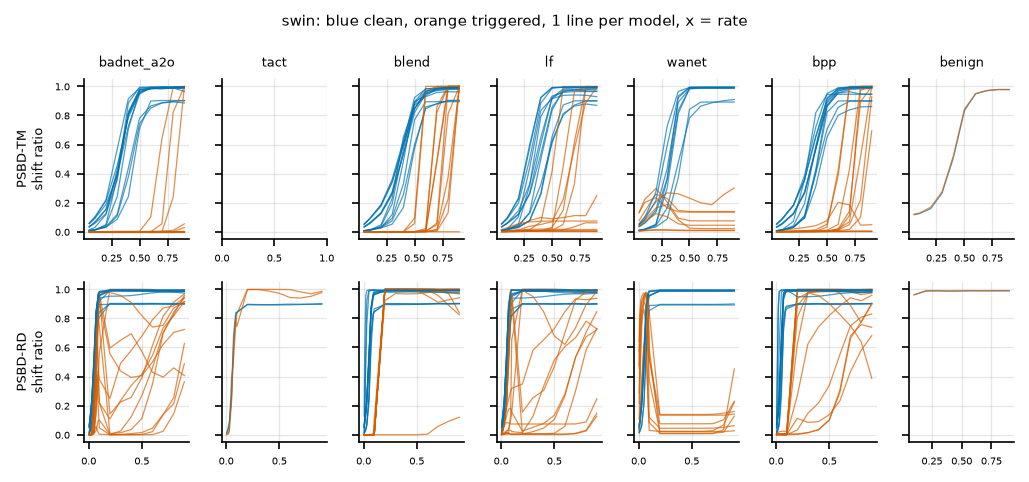

models  \
architecture attack         placement           
swin         adaptive_blend PSBD-TM         7   
                            PSBD-RD         7   
             badnet_a2o     PSBD-TM        12   
                            PSBD-RD        12   
             benign         PSBD-TM         1   
                            PSBD-RD         1   
             blend          PSBD-TM        12   
                            PSBD-RD        12   
             bpp            PSBD-TM        12   
                            PSBD-RD        12   
             lf             PSBD-TM        12   
                            PSBD-RD        12   
             tact           PSBD-RD         2   
             wanet          PSBD-TM         8   
                            PSBD-RD         8   
vit          badnet_a2o     PSBD-TM        12   
                            PSBD-RD        12   
             benign         PSBD-TM         4   
                            PSBD-RD         4   
             blend          PSBD-TM        12   
                            PSBD-RD        12   
             bpp            PSBD-TM        12   
                            PSBD-RD        12   
             lf             PSBD-TM        12   
                            PSBD-RD        12   
             tact           PSBD-TM         3   
                            PSBD-RD         3   
             wanet          PSBD-TM         3   
                            PSBD-RD         3   

                                       clean crosses 0.5 (median rate)  \
architecture attack         placement                                    
swin         adaptive_blend PSBD-TM                              0.355   
                            PSBD-RD                              0.048   
             badnet_a2o     PSBD-TM                              0.329   
                            PSBD-RD                              0.053   
             benign         PSBD-TM                              0.398   
                            PSBD-RD                              0.100   
             blend          PSBD-TM                              0.384   
                            PSBD-RD                              0.049   
             bpp            PSBD-TM                              0.377   
                            PSBD-RD                              0.043   
             lf             PSBD-TM                              0.361   
                            PSBD-RD                              0.051   
             tact           PSBD-RD                              0.063   
             wanet          PSBD-TM                              0.327   
                            PSBD-RD                              0.052   
vit          badnet_a2o     PSBD-TM                              0.307   
                            PSBD-RD                              0.051   
             benign         PSBD-TM                              0.351   
                            PSBD-RD                              0.050   
             blend          PSBD-TM                              0.311   
                            PSBD-RD                              0.045   
             bpp            PSBD-TM                              0.373   
                            PSBD-RD                              0.048   
             lf             PSBD-TM                              0.320   
                            PSBD-RD                              0.051   
             tact           PSBD-TM                              0.409   
                            PSBD-RD                              0.061   
             wanet          PSBD-TM                              0.313   
                            PSBD-RD                              0.036   

                                       triggered crosses 0.5 (median rate)  \
architecture attack         placement                                        
swin         adaptive_blend PSBD-TM                                 

In [37]:
curves = pd.DataFrame(json.loads((RESULTS / "shift_curves.json").read_text())["curves"])
SHOWN = {"before_attention_norm_token_mask": "PSBD-TM", "post_residual": "PSBD-RD"}
ATTACK_ORDER = ["badnet_a2o", "tact", "blend", "lf", "wanet", "bpp", "sig", "benign"]
for architecture in ("vit", "swin"):
    part = curves[(curves["architecture"] == architecture) & curves["placement"].isin(SHOWN)]
    attacks = [a for a in ATTACK_ORDER if a in set(part["attack"])]
    if not attacks:
        continue
    fig, axes = plt.subplots(2, len(attacks), figsize=(TEXT_WIDTH, 3.2), sharey=True, squeeze=False)
    for row, placement in enumerate(SHOWN):
        for column, attack in enumerate(attacks):
            axis = axes[row][column]
            for _, c in part[(part["placement"] == placement) & (part["attack"] == attack)].iterrows():
                axis.plot(c["rates"], c["clean"], color=OKABE_ITO[0], linewidth=0.6, alpha=0.7)
                axis.plot(c["rates"], c["triggered"], color=OKABE_ITO[1], linewidth=0.6, alpha=0.7)
            if row == 0:
                axis.set_title(attack, fontsize=6)
            if column == 0:
                axis.set_ylabel(f"{SHOWN[placement]}\nshift ratio", fontsize=6)
            axis.tick_params(labelsize=5)
    fig.suptitle(f"{architecture}: blue clean, orange triggered, 1 line per model, x = rate", fontsize=7)
    plt.tight_layout()
    plt.show()

crossing_rows = []
for (architecture, attack, placement), part in curves[curves["placement"].isin(SHOWN)].groupby(["architecture", "attack", "placement"]):
    crossing_rows.append({
        "architecture": architecture, "attack": attack, "placement": SHOWN[placement], "models": len(part),
        "clean crosses 0.5 (median rate)": part["clean_crossing"].median(),
        "triggered crosses 0.5 (median rate)": part["triggered_crossing"].median(),
        "triggered never reaches 0.5": int(part["triggered_crossing"].isna().sum()),
        "triggered peak (median)": part["triggered_peak"].median(),
    })
crossing = pd.DataFrame(crossing_rows).set_index(["architecture", "attack", "placement"])
display(crossing.round(3))

In [38]:
def cell(attack, placement, architecture="vit"):
    key = (architecture, attack, placement)
    return crossing.loc[key] if key in crossing.index else None


def ratio_text(c):
    if c is None or pd.isna(c["clean crosses 0.5 (median rate)"]):
        return "n/a"
    if pd.isna(c["triggered crosses 0.5 (median rate)"]):
        return "triggered never reaches 0.5"
    return fmt(c["triggered crosses 0.5 (median rate)"] / c["clean crosses 0.5 (median rate)"], 2) + " times the clean rate"


lines = []
tm_rows = {a: cell(a, "PSBD-TM") for a in ("badnet_a2o", "blend", "lf", "bpp")}
lines.append("(a) Under PSBD-TM on ViT the triggered curve reaches 0.5 at " + listed(
    f"{ratio_text(c)} for {a}" for a, c in tm_rows.items() if c is not None) + ".")
tact_tm = cell("tact", "PSBD-TM")
theory = pd.DataFrame(json.loads(Path("results/_experiments/theory_checks/cache_read.json").read_text()))
tact_theory = theory[(theory["attack"] == "tact") & (theory["placement"] == "before_attention_norm_token_mask")]
lines.append(f"(b) TaCT under PSBD-TM: {ratio_text(tact_tm)}. On the same cached passes the shift count separates TaCT at AUROC "
             + listed(f"{fmt(r['auc_cnt'])} for {r['folder']}" for _, r in tact_theory.iterrows())
             + " and the fractional statistic at " + listed(fmt(r["auc_frac"]) for _, r in tact_theory.iterrows())
             + ". Only the statistic changes between those 2 readings, so where the curves overlap and the statistic still separates, the separation lives in how much probability the own answer keeps, not in whether it flips. Why TaCT's triggered answers flip yet keep more relative probability than clean ones is a hypothesis here (its triggered images sit near a 2-class boundary between source and target).")
lines.append(f"(c) Under PSBD-RD: BadNets {ratio_text(cell('badnet_a2o', 'PSBD-RD'))}, TaCT {ratio_text(cell('tact', 'PSBD-RD'))}.")
lines.append("(d) Under PSBD-RD, global triggers: " + listed(f"{a} {ratio_text(cell(a, 'PSBD-RD'))}" for a in ("blend", "lf", "bpp")) + ".")
wanet_rd = cell("wanet", "PSBD-RD")
if wanet_rd is not None:
    lines.append(f"(e) WaNet under PSBD-RD: {int(wanet_rd['triggered never reaches 0.5'])} of {int(wanet_rd['models'])} models never reach 0.5 on the triggered curve, whose median peak is {fmt(wanet_rd['triggered peak (median)'])}.")
wanet_tm = curves[(curves["architecture"] == "vit") & (curves["attack"] == "wanet") & (curves["placement"] == "before_attention_norm_token_mask")]
lines.append("(f) WaNet under PSBD-TM per model: " + listed(
    f"{r['folder']} triggered crosses at {fmt(r['triggered_crossing']) if pd.notna(r['triggered_crossing']) else 'never'} against clean {fmt(r['clean_crossing'])}"
    for _, r in wanet_tm.iterrows()) + ".")
benign = curves[(curves["attack"] == "benign") & curves["placement"].isin(SHOWN)]
gap = (benign["triggered_crossing"] - benign["clean_crossing"]).abs()
lines.append(f"Control: on the benign models the 2 curves reach 0.5 within {fmt(gap.max())} of each other in rate at both placements and both architectures.")
say("**What it shows.** " + " ".join(lines))

critical = json.loads((RESULTS / "critical_rate.json").read_text())
breaks = pd.DataFrame(critical["predictions"]["P1_breaks"])
if len(breaks):
    breaks["attack"] = breaks["folder"].str.split("_").str[2]
    display(breaks.groupby(["attack", "placement"]).size().rename("pairs more than 0.1 off the curve").to_frame())
say("""**What it does not show.** The curves count flips of the answer, while the detector reads the lost probability. Where the 2 disagree (TaCT above, and the pairs listed in the table that sit far off the step 9 curve) the breaking point of the argmax is not the quantity PSBD tests, so the critical-rate account holds for the flip and needs the probability version to cover those cells. Each curve mixes captured and uncaptured triggered rows as the cache stores them.""")

<!-- results:begin -->
**What it shows.** (a) Under PSBD-TM on ViT the triggered curve reaches 0.5 at 2.74 times the clean rate for badnet_a2o, 2.53 times the clean rate for blend, 2.72 times the clean rate for lf and 2.06 times the clean rate for bpp. (b) TaCT under PSBD-TM: 1.05 times the clean rate. On the same cached passes the shift count separates TaCT at AUROC 0.497 for vit_cifar10_tact_0_01, 0.531 for vit_cifar10_tact_0_05 and 0.946 for vit_gtsrb_tact_0_05 and the fractional statistic at 0.979, 0.966 and 0.942. Only the statistic changes between those 2 readings, so where the curves overlap and the statistic still separates, the separation lives in how much probability the own answer keeps, not in whether it flips. Why TaCT's triggered answers flip yet keep more relative probability than clean ones is a hypothesis here (its triggered images sit near a 2-class boundary between source and target). (c) Under PSBD-RD: BadNets 1.19 times the clean rate, TaCT 0.71 times the clean rate. (d) Under PSBD-RD, global triggers: blend 2.96 times the clean rate, lf 2.51 times the clean rate and bpp 2.45 times the clean rate. (e) WaNet under PSBD-RD: 0 of 3 models never reach 0.5 on the triggered curve, whose median peak is 0.790. (f) WaNet under PSBD-TM per model: vit_cifar10_wanet_0_1 triggered crosses at 0.270 against clean 0.342, vit_tiny_wanet_0_05 triggered crosses at never against clean 0.283 and vit_tiny_wanet_0_1 triggered crosses at 0.826 against clean 0.313. Control: on the benign models the 2 curves reach 0.5 within 0.012 of each other in rate at both placements and both architectures.
<!-- results:end -->

pairs more than 0.1 off the curve
attack placement                                                              
badnet after_embedding_token_mask                                            7
       before_attention_norm_channel_mask                                    3
       before_attention_norm_gaussian                                        5
       before_mlp_gaussian                                                   3
       before_mlp_token_mask                                                 2
       mlp_neurons_channel_mask                                              3
       post_residual                                                         3
       pre_residual                                                          3
blend  after_embedding_token_mask                                            4
       before_attention_norm                                                 1
       before_attention_norm_gaussian                                        1
       before_mlp_gaussian                                                   2
       before_mlp_token_mask                                                 1
bpp    before_attention_norm                                                 2
       before_attention_norm_channel_mask                                    2
       before_attention_norm_gaussian                                        3
       before_mlp_gaussian                                                   1
       mlp_neurons_channel_mask                                              5
       post_residual                                                         1
       pre_residual                                                          2
lf     after_embedding_token_mask                                            5
       before_attention_norm_gaussian                                        2
       before_mlp_gaussian                                                   1
       before_mlp_token_mask                                                 1
       mlp_neurons_channel_mask                                              3
tact   before_attention_norm                                                 2
       before_attention_norm_channel_mask                                    2
       before_attention_norm_gaussian                                        3
       before_attention_norm_token_mask                                      2
       before_attention_residual_token_mask                                  1
       before_mlp_gaussian                                                   3
       mlp_neurons_channel_mask                                              2
       post_residual                                                         3
       pre_residual                                                          2
wanet  before_attention_norm                                                 2
       before_attention_norm_channel_mask                                    2
       before_attention_norm_gaussian                                        1
       before_attention_residual_token_mask                                  1
       before_mlp_gaussian                                                   3
       mlp_neurons_channel_mask                                              1
       post_residual                                                         1
       pre_residual                                                          3

<!-- results:begin -->
**What it does not show.** The curves count flips of the answer, while the detector reads the lost probability. Where the 2 disagree (TaCT above, and the pairs listed in the table that sit far off the step 9 curve) the breaking point of the argmax is not the quantity PSBD tests, so the critical-rate account holds for the flip and needs the probability version to cover those cells. Each curve mixes captured and uncaptured triggered rows as the cache stores them.
<!-- results:end -->

## Step 10. Swin-S

**Question.** Swin-S has no class token, reads the mean of its last stage and attends within windows, so a mechanism that rests on ViT's late class-token read might not transfer. This step asks whether the statistic works on Swin for the same reasons.

**What is measured.** Every measurement of steps 1 to 6 on the Swin models of the same attacks. `measure.py` handles both layouts: the operators flatten Swin's (batch, height, width, channels) maps, the redundancy pattern is resized per stage and the stream sites are blocks of stages 3 and 4. The figure compares the redundancy reading of the 2 architectures, since the theory note's L20 and L23 predict that windowed attention and mean pooling make Swin's evidence more redundant. The table lists the key number of every hypothesis side by side.

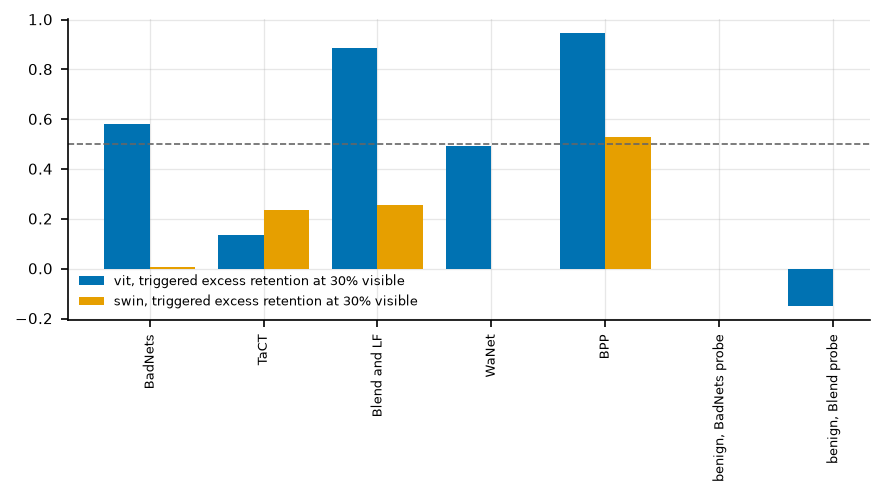

PSBD-TM AUROC  PSBD-RD AUROC  margin gap  \
group                 architecture                                             
BPP                   swin                  0.999          0.998       0.980   
                      vit                   0.994          0.996       0.802   
BadNets               swin                  1.000          0.836       0.687   
                      vit                   0.990          0.894       0.451   
Blend and LF          swin                  0.999          0.997       0.723   
                      vit                   0.993          0.999       0.711   
TaCT                  swin                  0.998          0.998       0.201   
                      vit                   0.983          0.576       0.181   
WaNet                 swin                  0.987          0.654       0.883   
                      vit                   0.807          0.990       0.497   
benign, BadNets probe swin                  0.496          0.498         NaN   
                      vit                   0.505          0.495         NaN   
benign, Blend probe   swin                  0.377          0.463         NaN   
                      vit                   0.446          0.534         NaN   

                                    L8 Spearman  excess at 30% visible  \
group                 architecture                                       
BPP                   swin                0.968                  0.530   
                      vit                 0.845                  0.946   
BadNets               swin                0.559                  0.008   
                      vit                 0.892                  0.580   
Blend and LF          swin                0.926                  0.257   
                      vit                 0.693                  0.888   
TaCT                  swin                0.453                  0.235   
                      vit                 0.506                  0.137   
WaNet                 swin                0.482                  0.000   
                      vit                 0.847                  0.493   
benign, BadNets probe swin                0.038                    NaN   
                      vit                -0.012                    NaN   
benign, Blend probe   swin                0.059                  0.000   
                      vit                -0.073                 -0.150   

                                    ranked sufficient share  AUROC at r 0.05  
group                 architecture                                            
BPP                   swin                            0.461            0.540  
                      vit                             0.553            0.708  
BadNets               swin                            0.478            0.568  
                      vit                             0.522            0.665  
Blend and LF          swin                            0.496            0.575  
                      vit                             0.531            0.741  
TaCT                  swin                            0.992            0.563  
                      vit                             0.989            0.567  
WaNet                 swin                            0.462            0.382  
                      vit                             0.601            0.631  
benign, BadNets probe swin                            0.223            0.488  
                      vit                             0.273            0.501  
benign, Blend probe   swin                            0.181            0.436  
                      vit                             0.218            0.433

In [39]:
if "swin" not in summary["groups"]:
    print("no Swin record yet")
else:
    rows = []
    for architecture in ARCHITECTURES:
        for g in groups_of(architecture):
            m = group_mean(architecture, g)
            v = summary["verdicts"][architecture][g]
            rows.append({
                "architecture": architecture,
                "group": GROUP_LABEL.get(g, g),
                "PSBD-TM AUROC": m["operators"]["token_mask"]["auroc_hit_only"],
                "PSBD-RD AUROC": m["operators"]["residual_dropout"]["auroc_hit_only"],
                "margin gap": v["margin"]["value"],
                "L8 Spearman": v["direction"]["value"],
                "excess at 30% visible": v["redundancy"]["value"],
                "ranked sufficient share": v["low_dim"]["value"],
                "AUROC at r 0.05": v["flatness"]["value"],
            })
    swin_table = pd.DataFrame(rows).set_index(["group", "architecture"]).sort_index()
    fig, axis = plt.subplots(figsize=(TEXT_WIDTH, 2.6))
    common = [g for g in groups_of("vit") if g in summary["groups"]["swin"]]
    x = np.arange(len(common))
    for offset, architecture in ((-0.2, "vit"), (0.2, "swin")):
        axis.bar(x + offset, [summary["verdicts"][architecture][g]["redundancy"]["value"] or np.nan for g in common],
                 0.4, label=f"{architecture}, triggered excess retention at 30% visible")
    axis.set_xticks(x)
    axis.set_xticklabels([GROUP_LABEL.get(g, g) for g in common], rotation=90, fontsize=6)
    axis.axhline(0.5, color="0.4", linewidth=0.8, linestyle="--")
    axis.legend(fontsize=6)
    plt.show()
    display(swin_table.round(3))

In [40]:
if "swin" not in summary["groups"]:
    say("No Swin record was available when this notebook ran.")
else:
    common = [g for g in attack_groups("vit") if g in summary["groups"]["swin"]]
    parts = []
    for g in common:
        readings = []
        for key in ("margin", "direction", "redundancy", "low_dim", "flatness"):
            vit, swin = verdict_of("vit", g, key), verdict_of("swin", g, key)
            readings.append(f"{key} {vit['status']} ({fmt(vit['value'])}) on ViT and {swin['status']} ({fmt(swin['value'])}) on Swin")
        parts.append(f"{group_name(g)}: {listed(readings)}.")
    say("**What it shows.** " + " ".join(parts))
    say("**What it does not show.** Swin reads its feature by pooling every position, so the backdoor share and the direction statistics measure a pooled vector rather than 1 class token, and the stream sites are later in relative depth. Agreement of the verdicts says the same principle holds, not that the 2 architectures route the trigger alike.")

<!-- results:begin -->
**What it shows.** BadNets: margin supported (0.451) on ViT and supported (0.687) on Swin, direction supported (0.892) on ViT and partial (0.559) on Swin, redundancy partial (0.580) on ViT and refuted (0.008) on Swin, low_dim supported (0.522) on ViT and partial (0.478) on Swin and flatness partial (0.665) on ViT and refuted (0.568) on Swin. TaCT: margin partial (0.181) on ViT and partial (0.201) on Swin, direction partial (0.506) on ViT and partial (0.453) on Swin, redundancy refuted (0.137) on ViT and partial (0.235) on Swin, low_dim partial (0.989) on ViT and partial (0.992) on Swin and flatness refuted (0.567) on ViT and refuted (0.563) on Swin. Blend and LF: margin supported (0.711) on ViT and supported (0.723) on Swin, direction partial (0.693) on ViT and supported (0.926) on Swin, redundancy supported (0.888) on ViT and partial (0.257) on Swin, low_dim supported (0.531) on ViT and partial (0.496) on Swin and flatness refuted (0.741) on ViT and refuted (0.575) on Swin. WaNet: margin supported (0.497) on ViT and supported (0.883) on Swin, direction supported (0.847) on ViT and partial (0.482) on Swin, redundancy partial (0.493) on ViT and refuted (0.000) on Swin, low_dim supported (0.601) on ViT and partial (0.462) on Swin and flatness refuted (0.631) on ViT and refuted (0.382) on Swin. BPP: margin supported (0.802) on ViT and supported (0.980) on Swin, direction supported (0.845) on ViT and supported (0.968) on Swin, redundancy supported (0.946) on ViT and supported (0.530) on Swin, low_dim supported (0.553) on ViT and partial (0.461) on Swin and flatness refuted (0.708) on ViT and refuted (0.540) on Swin.
<!-- results:end -->

<!-- results:begin -->
**What it does not show.** Swin reads its feature by pooling every position, so the backdoor share and the direction statistics measure a pooled vector rather than 1 class token, and the stream sites are later in relative depth. Agreement of the verdicts says the same principle holds, not that the 2 architectures route the trigger alike.
<!-- results:end -->

## Step 11. The unifying hypothesis: PSBD detects over-determined decisions

**Question.** Steps 2 to 10 give readings per attack, and the critical rate (step 9) restates PSBD in 1 variable. The user asked for 1 explanation of why PSBD works and where it fails. The candidate, stated and its predictions registered in `sufficiency.py` before any reading: a backdoor that is a true shortcut, a trigger sufficient on its own and independent of the image, gives the triggered decision far more evidence than it needs, so random removal leaves enough of it. A clean decision has just enough evidence and breaks. PSBD should fail where the backdoor is a conjunction with content (TaCT flips only its source class) or relational along the axis the probe removes (WaNet's warp under token removal).

**What is measured** (`sufficiency.py`, 1 isolating change per condition). The models are the evidence-surplus set the user chose (`experiments/evidence_surplus/`): 10 ViT models covering BadNets, Blend, BPP, LF, WaNet and TaCT, the 2 ResNet-18 reproductions of the original paper (read with PSBD-RD, its own site) and 2 benign ViT models probed with a BadNets and a Blend trigger.

- Blank: the trigger stamped on content-free carriers (the dataset's mean image, mid gray and uniform noise images) against the same carriers unstamped. The excess share sent to the target is the sufficiency score: how much of the attack label the trigger carries with no image at all.
- Content hidden: the triggered image with every non-trigger token hidden at the attention input of every block (patch triggers) or a random 70% hidden (global triggers), against its clean twin under the same mask. Where the masked clean twin already goes to the target, the model's default class under heavy masking is the target and the reading has no room, which the record flags.
- Classes: the trigger stamped on test images of every non-target class, the attack's source restriction ignored. A shortcut sends every class to the target, a conjunction only its source classes.

**Predictions** (from the script's docstring). S1: the sufficiency score predicts PSBD-TM's AUROC and its TPR at the 0.01 quantile at the adaptive rate across the set's backdoored models with 1 monotone relation, Spearman at least 0.6 each. S2: TaCT sits low on sufficiency and on class independence. S3: the benign models sit near 0 on every excess.

- Panel a: the detector's AUROC against the sufficiency score, 1 point per model, ViT dots and ResNet-18 crosses, coloured by attack.
- Panel b: the same for TPR at the 0.01 quantile.
- Panel c: the share of non-source images sent to the target when stamped, per attack and architecture, the content-dependence control.

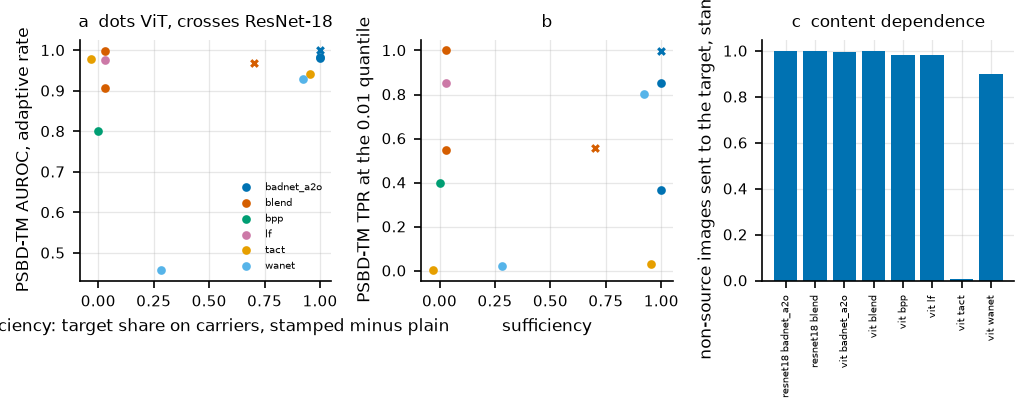

,models,blank_excess,content_excess,any_class,auroc,tpr_q01
cell,,,,,,
resnet18|badnet_a2o,1,1.000,NaN,1.000,1.000,1.000
resnet18|blend,1,0.703,NaN,1.000,0.968,0.555
vit|badnet_a2o,2,1.000,1.000,0.997,0.983,0.609
vit|blend,2,0.031,0.903,1.000,0.952,0.775
vit|bpp,1,0.000,0.896,0.984,0.801,0.400
vit|lf,1,0.031,0.866,0.984,0.976,0.854
vit|tact,2,0.461,0.000,0.005,0.960,0.017
vit|wanet,2,0.602,0.354,0.901,0.694,0.412


<!-- results:begin -->
**What it shows.** S1: over 12 backdoored models of the set the sufficiency score correlates with PSBD-TM's AUROC at Spearman 0.343 and with its TPR at the 0.01 quantile at 0.161, so S1 fails as registered. The content-hidden excess, read where the masked clean twin did not collapse onto the target, correlates with the AUROC at 0.533. S2: TaCT's sufficiency is 0.461 (vit) against 0.000 to 1.000 for the other attacks, and stamped non-source images go to the target at 0.005 against 0.901 to 1.000. S3: the benign models' largest excess is 0.031 on the carriers and 0.022 with content hidden.
<!-- results:end -->

<!-- results:begin -->
**Diagnosis of the failed S1, the failure protocol's 1 extra measurement.** The registered verdict stands as scored. The carrier score reads 0.031 for vit blend, 0.000 for vit bpp and 0.031 for vit lf while the same triggers carry the label with 70% of the image hidden (content excess 0.903, 0.896 and 0.866). A quantization trigger changes nothing on a flat carrier, and a blended or low-frequency pattern on a mean-colored carrier is a different input from the one the model learned it on, so the carrier form measures whether a trigger is defined without content, not whether it is sufficient with little content. The content-hidden form is the measurement that matches the hypothesis, and it correlates with PSBD-TM's AUROC at Spearman 0.533 over the models where it is defined, still short of the registered 0.6. S2 and S3 hold as the table shows: TaCT carries nothing with its content hidden and nothing on non-source images, which is the conjunction the hypothesis predicts, although its trigger reaches 0.461 on content-free carriers, which this test does not explain, and PSBD-TM's TPR at the 0.01 quantile on TaCT is low while its AUROC is high. So the over-determination account explains TaCT's weak low-FPR detection and the benign null, and does not rank the shortcut attacks: among triggers that are all sufficient with content hidden, detection strength varies for other reasons (steps 3 and 4). Whether sufficiency accounts for what A* leaves over reads Spearman -0.091 on 10 ViT models, a correlation and so a hypothesis, and here a null one.
<!-- results:end -->

In [41]:
suff = summary.get("sufficiency")
if not suff:
    say("sufficiency.py had not run when this notebook was executed.")
else:
    table = pd.DataFrame(suff["rows"])
    scored = table[table["auroc"].notna()]
    attacks = sorted(scored["attack"].unique())
    fig, axes = plt.subplots(1, 3, figsize=(TEXT_WIDTH, 2.8))
    for index, attack in enumerate(attacks):
        for architecture, marker in (("vit", "o"), ("resnet18", "x")):
            part = scored[(scored["attack"] == attack) & (scored["architecture"] == architecture)]
            label = attack if architecture == "vit" else None
            axes[0].scatter(part["blank_excess"], part["auroc"], s=10, marker=marker, color=OKABE_ITO[index % 8], label=label)
            axes[1].scatter(part["blank_excess"], part["tpr_q01"], s=10, marker=marker, color=OKABE_ITO[index % 8])
    axes[0].set_xlabel("sufficiency: target share on carriers, stamped minus plain")
    axes[0].set_ylabel("PSBD-TM AUROC, adaptive rate")
    axes[0].set_title("a  dots ViT, crosses ResNet-18", fontsize=8)
    axes[0].legend(fontsize=5)
    axes[1].set_xlabel("sufficiency")
    axes[1].set_ylabel("PSBD-TM TPR at the 0.01 quantile")
    axes[1].set_title("b", fontsize=8)
    groups = pd.DataFrame([{"cell": k, **v} for k, v in suff["by_attack"].items()])
    axes[2].bar(range(len(groups)), groups["any_class"])
    axes[2].set_xticks(range(len(groups)))
    axes[2].set_xticklabels(groups["cell"].str.replace("|", " "), rotation=90, fontsize=5)
    axes[2].set_ylabel("non-source images sent to the target, stamped")
    axes[2].set_title("c  content dependence", fontsize=8)
    plt.tight_layout()
    plt.show()
    display(groups.set_index("cell").round(3))
    tact = groups[groups["cell"].str.endswith("|tact")]
    others = groups[~groups["cell"].str.endswith("|tact")]
    s1 = suff["S1_spearman_auroc"] >= 0.6 and suff["S1_spearman_tpr"] >= 0.6
    say(f"""**What it shows.** S1: over {suff['S1_models']} backdoored models of the set the sufficiency score correlates with PSBD-TM's AUROC at Spearman {fmt(suff['S1_spearman_auroc'])} and with its TPR at the 0.01 quantile at {fmt(suff['S1_spearman_tpr'])}, so S1 {'holds' if s1 else 'fails as registered'}. The content-hidden excess, read where the masked clean twin did not collapse onto the target, correlates with the AUROC at {fmt(suff['S1_content_spearman_auroc'])}. S2: TaCT's sufficiency is {listed(f"{fmt(r['blank_excess'])} ({r['cell'].split('|')[0]})" for _, r in tact.iterrows())} against {fmt(others['blank_excess'].min())} to {fmt(others['blank_excess'].max())} for the other attacks, and stamped non-source images go to the target at {listed(fmt(v) for v in tact['any_class'])} against {fmt(others['any_class'].min())} to {fmt(others['any_class'].max())}. S3: the benign models' largest excess is {fmt(suff['S3_benign_max_blank_excess'])} on the carriers and {fmt(suff['S3_benign_max_content_excess'])} with content hidden.""")
    carrier_blind = groups[(groups["blank_excess"] < 0.1) & (groups["content_excess"] > 0.5)]
    say(f"""**Diagnosis of the failed S1, the failure protocol's 1 extra measurement.** The registered verdict stands as scored. The carrier score reads {listed(f"{fmt(r['blank_excess'])} for {r['cell'].replace('|', ' ')}" for _, r in carrier_blind.iterrows())} while the same triggers carry the label with 70% of the image hidden (content excess {listed(fmt(v) for v in carrier_blind['content_excess'])}). A quantization trigger changes nothing on a flat carrier, and a blended or low-frequency pattern on a mean-colored carrier is a different input from the one the model learned it on, so the carrier form measures whether a trigger is defined without content, not whether it is sufficient with little content. The content-hidden form is the measurement that matches the hypothesis, and it correlates with PSBD-TM's AUROC at Spearman {fmt(suff['S1_content_spearman_auroc'])} over the models where it is defined, still short of the registered 0.6. S2 and S3 hold as the table shows: TaCT carries nothing with its content hidden and nothing on non-source images, which is the conjunction the hypothesis predicts, although its trigger reaches {listed(fmt(v) for v in groups[groups['cell'].str.endswith('|tact')]['blank_excess'])} on content-free carriers, which this test does not explain, and PSBD-TM's TPR at the 0.01 quantile on TaCT is low while its AUROC is high. So the over-determination account explains TaCT's weak low-FPR detection and the benign null, and does not rank the shortcut attacks: among triggers that are all sufficient with content hidden, detection strength varies for other reasons (steps 3 and 4). Whether sufficiency accounts for what A* leaves over reads Spearman {fmt(suff['a_star_residual_spearman'])} on {suff['a_star_models']} ViT models, a correlation and so a hypothesis, and here a null one.""")

## Step 12. The verdicts

Each cell is 1 hypothesis on 1 attack category: green supported, yellow partial, red refuted, blank no data, with the key number the rule reads. The rules and their thresholds are printed under the grid from `summary.json`, where `summarize.py` stored them beside each verdict, with thresholds from `docs/why-psbd-works-theory.md` where it gives one. The last table gives the 3 accounts read on the whole panel or on the seed-replicated cells rather than on this experiment's models: confidence (P1), the target class being easy (P10) and the epistemic ensemble (P2).

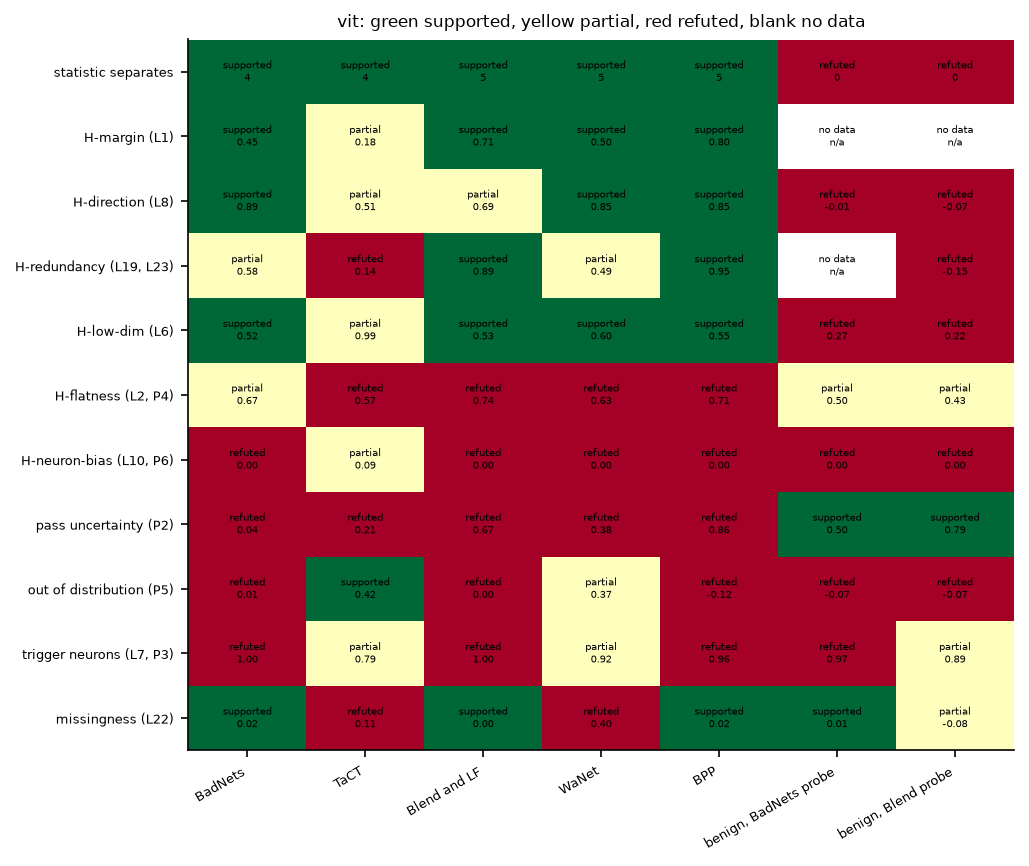

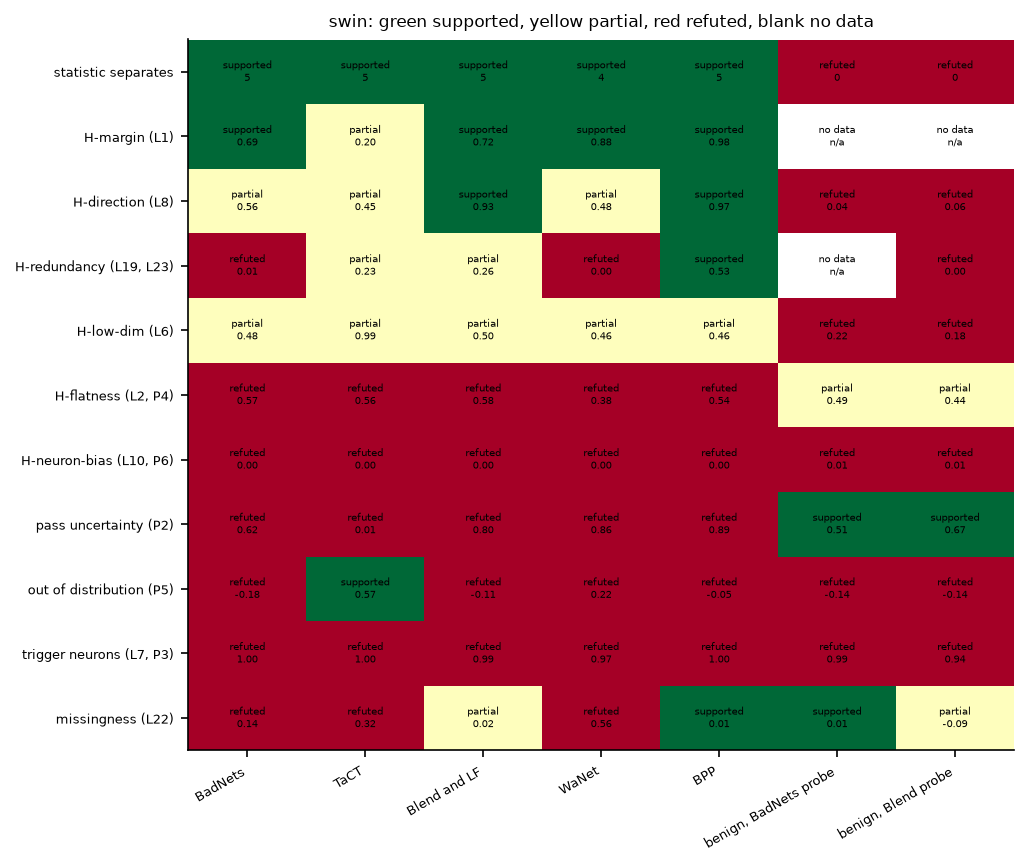

,account,attack,status,key,value
0,confidence carries it (P1),badnet_a2o,refuted,PSBD-TM minus A*(P_c),0.092
1,confidence carries it (P1),blend,refuted,PSBD-TM minus A*(P_c),0.052
2,confidence carries it (P1),bpp,refuted,PSBD-TM minus A*(P_c),0.081
3,confidence carries it (P1),lf,refuted,PSBD-TM minus A*(P_c),0.105
4,confidence carries it (P1),tact,refuted,PSBD-TM minus A*(P_c),0.098
5,confidence carries it (P1),wanet,refuted,PSBD-TM minus A*(P_c),0.052
6,target class is easy (P10),badnet_a2o,partial,"clean target-class images flagged, PSBD-TM",0.726
7,target class is easy (P10),blend,partial,"clean target-class images flagged, PSBD-TM",0.401
8,target class is easy (P10),bpp,partial,"clean target-class images flagged, PSBD-TM",0.413
9,target class is easy (P10),lf,partial,"clean target-class images flagged, PSBD-TM",0.737


In [42]:
STATUS_VALUE = {"supported": 1.0, "partial": 0.5, "refuted": 0.0}
HYPOTHESES = [
    ("phenomenon", "statistic separates"),
    ("margin", "H-margin (L1)"),
    ("direction", "H-direction (L8)"),
    ("redundancy", "H-redundancy (L19, L23)"),
    ("low_dim", "H-low-dim (L6)"),
    ("flatness", "H-flatness (L2, P4)"),
    ("neuron_bias", "H-neuron-bias (L10, P6)"),
    ("pass_uncertainty", "pass uncertainty (P2)"),
    ("ood", "out of distribution (P5)"),
    ("trigger_neurons", "trigger neurons (L7, P3)"),
    ("missingness", "missingness (L22)"),
]


def value_text(v):
    if v["value"] is None:
        return "n/a"
    if isinstance(v["value"], int):
        return str(v["value"])
    return f"{v['value']:.2f}"


for architecture in ARCHITECTURES:
    groups = groups_of(architecture)
    grid = np.full((len(HYPOTHESES), len(groups)), np.nan)
    labels = [["" for _ in groups] for _ in HYPOTHESES]
    for i, (key, _) in enumerate(HYPOTHESES):
        for j, g in enumerate(groups):
            v = summary["verdicts"][architecture][g][key]
            grid[i, j] = STATUS_VALUE.get(v["status"], np.nan)
            labels[i][j] = f"{v['status']}\n{value_text(v)}"
    fig, axis = plt.subplots(figsize=(TEXT_WIDTH, 0.42 * len(HYPOTHESES) + 1.2))
    axis.imshow(grid, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            axis.text(j, i, labels[i][j], ha="center", va="center", fontsize=5)
    axis.set_xticks(range(len(groups)))
    axis.set_xticklabels([GROUP_LABEL.get(g, g) for g in groups], rotation=30, ha="right", fontsize=6)
    axis.set_yticks(range(len(HYPOTHESES)))
    axis.set_yticklabels([label for _, label in HYPOTHESES], fontsize=6)
    axis.set_title(f"{architecture}: green supported, yellow partial, red refuted, blank no data", fontsize=8)
    axis.grid(False)
    plt.tight_layout()
    plt.show()

panel = summary["panel_verdicts"]
rows = []
for name, label in (("confidence", "confidence carries it (P1)"), ("target_easy", "target class is easy (P10)"),
                    ("epistemic", "epistemic ensemble (P2)")):
    for attack, v in (panel.get(name) or {}).items():
        rows.append({"account": label, "attack": attack, "status": v["status"], "key": v["key"],
                     "value": v["value"]})
pd.DataFrame(rows).round(3)

In [43]:
counts = {}
for architecture in ARCHITECTURES:
    for g in attack_groups(architecture):
        for key, name in HYPOTHESES:
            status = verdict_of(architecture, g, key)["status"]
            counts.setdefault(name, {}).setdefault(status, 0)
            counts[name][status] += 1
rows = [{"hypothesis": name, **values} for name, values in counts.items()]
display(pd.DataFrame(rows).set_index("hypothesis").fillna(0).astype(int))
held = [name for name, v in counts.items() if v.get("supported", 0) >= sum(v.values()) / 2]
failed = [name for name, v in counts.items() if v.get("refuted", 0) >= sum(v.values()) / 2]
say(f"""## Summary

Over every architecture and attack category measured, the accounts that hold in at least half of the cells are {listed(held)}, and the ones refuted in at least half are {listed(failed)}. Each supported reading above rests on 1 experiment that changes 1 thing against a control: margin matching against the unmatched AUROC, the backdoor direction against the clean class direction, forced-visible trigger tokens against random patterns and the ranked token order against the random order. Every reading is also checked against the benign probes. Read together they suggest 1 principle, which is a hypothesis that ties them together and was not tested as a whole: the trigger writes 1 target-aligned direction into the feature the classifier reads, and its margin survives the probe, while a clean answer breaks at a lower critical rate (step 9). How the trigger's evidence is spread over tokens differs by architecture and attack (step 4), so redundancy is not part of the general principle. The explanations that sound right and do not carry the signal, each refuted by its own experiment in step 7, are confidence (beaten by the statistic), MC-dropout uncertainty (the passes of a clean image agree on a wrong answer), unusual inputs (foreign images are not flagged as such), robust trigger neurons (there are none, there is a direction), and an attractor on the target (the separation survives removing it).""")

,supported,partial,refuted
hypothesis,,,
statistic separates,10,0,0
H-margin (L1),8,2,0
H-direction (L8),5,5,0
"H-redundancy (L19, L23)",3,4,3
H-low-dim (L6),4,6,0
"H-flatness (L2, P4)",0,1,9
"H-neuron-bias (L10, P6)",0,1,9
pass uncertainty (P2),0,0,10
out of distribution (P5),2,1,7


<!-- results:begin -->
## Summary

Over every architecture and attack category measured, the accounts that hold in at least half of the cells are statistic separates, H-margin (L1) and H-direction (L8), and the ones refuted in at least half are H-flatness (L2, P4), H-neuron-bias (L10, P6), pass uncertainty (P2), out of distribution (P5), trigger neurons (L7, P3) and missingness (L22). Each supported reading above rests on 1 experiment that changes 1 thing against a control: margin matching against the unmatched AUROC, the backdoor direction against the clean class direction, forced-visible trigger tokens against random patterns and the ranked token order against the random order. Every reading is also checked against the benign probes. Read together they suggest 1 principle, which is a hypothesis that ties them together and was not tested as a whole: the trigger writes 1 target-aligned direction into the feature the classifier reads, and its margin survives the probe, while a clean answer breaks at a lower critical rate (step 9). How the trigger's evidence is spread over tokens differs by architecture and attack (step 4), so redundancy is not part of the general principle. The explanations that sound right and do not carry the signal, each refuted by its own experiment in step 7, are confidence (beaten by the statistic), MC-dropout uncertainty (the passes of a clean image agree on a wrong answer), unusual inputs (foreign images are not flagged as such), robust trigger neurons (there are none, there is a direction), and an attractor on the target (the separation survives removing it).
<!-- results:end -->